In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import RegularGridInterpolator
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from itertools import product
import matplotlib.colors as mcolors
from wrf_io import postproc

In [3]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [4]:
casenames = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/sweep_names.npy')
U_loc   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/U_loc.npy')
dir_loc = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/dir_loc.npy')
Uhub    = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/Uhub.npy')
wrf_rel = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_rel.npy')
wrf_vax = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_vax.npy')
wrf_vtn = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_vtn.npy')
wrf_cax = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_cax.npy')
wrf_cot = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_cot.npy')
wrf_ind = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_ind.npy')
wrf_thr = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_thr.npy')
wrf_pow = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_pow.npy')
shapiro = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/shapiro.npy')
wrf_tsr = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_tsr.npy')
wrf_omg = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_omg.npy')
Nelm    = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['Nelm']
Nsct    = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['Nsct']
rOverR  = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['rOverR']
R       = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['R']

In [5]:
x_temp = [0,1,2,3,4,5,6]
y_temp = [16,15,14,13,12,11,10,9,8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp, y_temp)]

In [6]:
# Define the specific equation (e.g., linear: y = a * x + b)
def madsen_func(CT, a, b, c):

    return a * CT**3 + b * CT**2 + c * CT

In [7]:
veer  = np.array([-80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30,40,50,60,70,80])
shear = np.array([-6,-4,-2,0,2,4,6])

training = [pair for pair in product(shear, veer)]

indices_80 = [i for i, (s, v) in enumerate(training) if abs(v) == 80 ]
indices_70 = [i for i, (s, v) in enumerate(training) if abs(v) == 70 ]
indices_60 = [i for i, (s, v) in enumerate(training) if abs(v) == 60 ]
indices_50 = [i for i, (s, v) in enumerate(training) if abs(v) == 50 ]
indices_40 = [i for i, (s, v) in enumerate(training) if abs(v) == 40 ]
indices_30 = [i for i, (s, v) in enumerate(training) if abs(v) == 30 ]
indices_20 = [i for i, (s, v) in enumerate(training) if abs(v) == 20 ]
indices_10 = [i for i, (s, v) in enumerate(training) if abs(v) == 10 ]
indices_00 = [i for i, (s, v) in enumerate(training) if abs(v) == 0 ]

In [8]:
# V80

a_mom = np.linspace(0,0.05,2)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_80])
ct_mom = np.append(ct_mom, wrf_cot[indices_80])

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v80, b_fit_v80, c_fit_v80 = params
# print(f"Fitted parameters: {a_fit_v80:.3f}, {b_fit_v80:.3f}, {c_fit_v80:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/absv80_allS_10MW_rotor_coefficients.npy", [a_fit_v80,b_fit_v80,c_fit_v80])

# Generate fitted values
x_fit_v80 = np.linspace(0, 2, 100)
y_fit_v80 = madsen_func(x_fit_v80, a_fit_v80, b_fit_v80, c_fit_v80)

In [9]:
# V70

a_mom = np.linspace(0,0.05,2)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_70])
ct_mom = np.append(ct_mom, wrf_cot[indices_70])

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v70, b_fit_v70, c_fit_v70 = params
# print(f"Fitted parameters: {a_fit_v70:.3f}, {b_fit_v70:.3f}, {c_fit_v70:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/absv70_allS_10MW_rotor_coefficients.npy", [a_fit_v70,b_fit_v70,c_fit_v70])

# Generate fitted values
x_fit_v70 = np.linspace(0, 2, 100)
y_fit_v70 = madsen_func(x_fit_v70, a_fit_v70, b_fit_v70, c_fit_v70)

In [10]:
# V60

a_mom = np.linspace(0,0.05,2)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_60])
ct_mom = np.append(ct_mom, wrf_cot[indices_60])

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v60, b_fit_v60, c_fit_v60 = params
# print(f"Fitted parameters: {a_fit_v70:.3f}, {b_fit_v70:.3f}, {c_fit_v70:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/absv60_allS_10MW_rotor_coefficients.npy", [a_fit_v60,b_fit_v60,c_fit_v60])

# Generate fitted values
x_fit_v60 = np.linspace(0, 2, 100)
y_fit_v60 = madsen_func(x_fit_v60, a_fit_v60, b_fit_v60, c_fit_v60)

In [11]:
# V50

a_mom = np.linspace(0,0.05,10)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_50])
ct_mom = np.append(ct_mom, wrf_cot[indices_50])

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v50, b_fit_v50, c_fit_v50 = params
# print(f"Fitted parameters: {a_fit_v70:.3f}, {b_fit_v70:.3f}, {c_fit_v70:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/absv50_allS_10MW_rotor_coefficients.npy", [a_fit_v50,b_fit_v50,c_fit_v50])

# Generate fitted values
x_fit_v50 = np.linspace(0, 2, 100)
y_fit_v50 = madsen_func(x_fit_v50, a_fit_v50, b_fit_v50, c_fit_v50)

In [12]:
# V40

a_mom = np.linspace(0,0.05,2)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_40])
ct_mom = np.append(ct_mom, wrf_cot[indices_40])

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v40, b_fit_v40, c_fit_v40 = params
# print(f"Fitted parameters: {a_fit_v40:.3f}, {b_fit_v40:.3f}, {c_fit_v40:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/absv40_allS_10MW_rotor_coefficients.npy", [a_fit_v40,b_fit_v40,c_fit_v40])

# Generate fitted values
x_fit_v40 = np.linspace(0, 2, 100)
y_fit_v40 = madsen_func(x_fit_v40, a_fit_v40, b_fit_v40, c_fit_v40)

In [13]:
# V30

a_mom = np.linspace(0,0.05,2)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_30])
ct_mom = np.append(ct_mom, wrf_cot[indices_30])

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v30, b_fit_v30, c_fit_v30 = params
# print(f"Fitted parameters: {a_fit_v40:.3f}, {b_fit_v40:.3f}, {c_fit_v40:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/absv30_allS_10MW_rotor_coefficients.npy", [a_fit_v30,b_fit_v30,c_fit_v30])

# Generate fitted values
x_fit_v30 = np.linspace(0, 2, 100)
y_fit_v30 = madsen_func(x_fit_v30, a_fit_v30, b_fit_v30, c_fit_v30)

In [14]:
# V20

# a_mom = np.linspace(0,0.075,50)
a_mom = np.linspace(0,0.1,2)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_20])
ct_mom = np.append(ct_mom, wrf_cot[indices_20])

a_mom_l = 0.6
ct_mom_l = 4 * a_mom_l * (1 - a_mom_l)

a_mom = np.append(a_mom, a_mom_l)
ct_mom = np.append(ct_mom, ct_mom_l)

# a_mom = ind_rotor[indices_20]
# ct_mom = ct_rotor[indices_20]

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v20, b_fit_v20, c_fit_v20 = params
# print(f"Fitted parameters: {a_fit_v20:.3f}, {b_fit_v20:.3f}, {c_fit_v20:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/absv20_allS_10MW_rotor_coefficients.npy", [a_fit_v20,b_fit_v20,c_fit_v20])

# Generate fitted values
x_fit_v20 = np.linspace(0, 2, 100)
y_fit_v20 = madsen_func(x_fit_v20, a_fit_v20, b_fit_v20, c_fit_v20)

In [15]:
# V10

a_mom = np.linspace(0,0.1,4)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_10])
ct_mom = np.append(ct_mom, wrf_cot[indices_10])

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v10, b_fit_v10, c_fit_v10 = params
# print(f"Fitted parameters: {a_fit_v10:.3f}, {b_fit_v10:.3f}, {c_fit_v10:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/absv10_allS_10MW_rotor_coefficients.npy", [a_fit_v10,b_fit_v10,c_fit_v10])

# Generate fitted values
x_fit_v10 = np.linspace(0, 2, 100)
y_fit_v10 = madsen_func(x_fit_v10, a_fit_v10, b_fit_v10, c_fit_v10)

In [16]:
# V00

a_mom = np.linspace(0,0.075,4)
ct_mom = 4 * a_mom * (1 - a_mom)

a_mom = np.append(a_mom, wrf_ind[indices_00])
ct_mom = np.append(ct_mom, wrf_cot[indices_00])

# a_mom_l = 0.8
# ct_mom_l = 4 * a_mom_l * (1 - a_mom_l)

# a_mom = np.append(a_mom, a_mom_l)
# ct_mom = np.append(ct_mom, ct_mom_l)

# Perform curve fitting
params, covariance = curve_fit(madsen_func, ct_mom, a_mom)

# Extract fitted parameters
a_fit_v00, b_fit_v00, c_fit_v00 = params
# print(f"Fitted parameters: {a_fit_v00:.3f}, {b_fit_v00:.3f}, {c_fit_v00:.3f}")

np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotor_coefficients/shapiro/absv00_allS_10MW_rotor_coefficients.npy", [a_fit_v00,b_fit_v00,c_fit_v00])

# Generate fitted values
x_fit_v00 = np.linspace(0, 2, 100)
y_fit_v00 = madsen_func(x_fit_v00, a_fit_v00, b_fit_v00, c_fit_v00)

In [17]:
print("if abs(int(self.veer)) == 8:")
print(f"    a,b,c = {a_fit_v80:.3f}, {b_fit_v80:.3f}, {c_fit_v80:.3f}")
print("elif abs(int(self.veer)) == 7:")
print(f"    a,b,c = {a_fit_v70:.3f}, {b_fit_v70:.3f}, {c_fit_v70:.3f}")
print("elif abs(int(self.veer)) == 6:")
print(f"    a,b,c = {a_fit_v60:.3f}, {b_fit_v60:.3f}, {c_fit_v60:.3f}")
print("elif abs(int(self.veer)) == 5:")
print(f"    a,b,c = {a_fit_v50:.3f}, {b_fit_v50:.3f}, {c_fit_v50:.3f}")
print("elif abs(int(self.veer)) == 4:")
print(f"    a,b,c = {a_fit_v40:.3f}, {b_fit_v40:.3f}, {c_fit_v40:.3f}")
print("elif abs(int(self.veer)) == 3:")
print(f"    a,b,c = {a_fit_v30:.3f}, {b_fit_v30:.3f}, {c_fit_v30:.3f}")
print("elif abs(int(self.veer)) == 2:")
print(f"    a,b,c = {a_fit_v20:.3f}, {b_fit_v20:.3f}, {c_fit_v20:.3f}")
print("elif abs(int(self.veer)) == 1:")
print(f"    a,b,c = {a_fit_v10:.3f}, {b_fit_v10:.3f}, {c_fit_v10:.3f}")
print("elif abs(int(self.veer)) == 0:")
print(f"    a,b,c = {a_fit_v00:.3f}, {b_fit_v00:.3f}, {c_fit_v00:.3f}")

if abs(int(self.veer)) == 8:
    a,b,c = 1.366, -1.094, 0.422
elif abs(int(self.veer)) == 7:
    a,b,c = 1.395, -1.134, 0.428
elif abs(int(self.veer)) == 6:
    a,b,c = 1.368, -1.125, 0.427
elif abs(int(self.veer)) == 5:
    a,b,c = 0.968, -0.721, 0.343
elif abs(int(self.veer)) == 4:
    a,b,c = 1.014, -0.822, 0.383
elif abs(int(self.veer)) == 3:
    a,b,c = 0.428, -0.273, 0.300
elif abs(int(self.veer)) == 2:
    a,b,c = 2.334, -2.507, 0.880
elif abs(int(self.veer)) == 1:
    a,b,c = -0.185, 0.323, 0.196
elif abs(int(self.veer)) == 0:
    a,b,c = -0.314, 0.434, 0.185


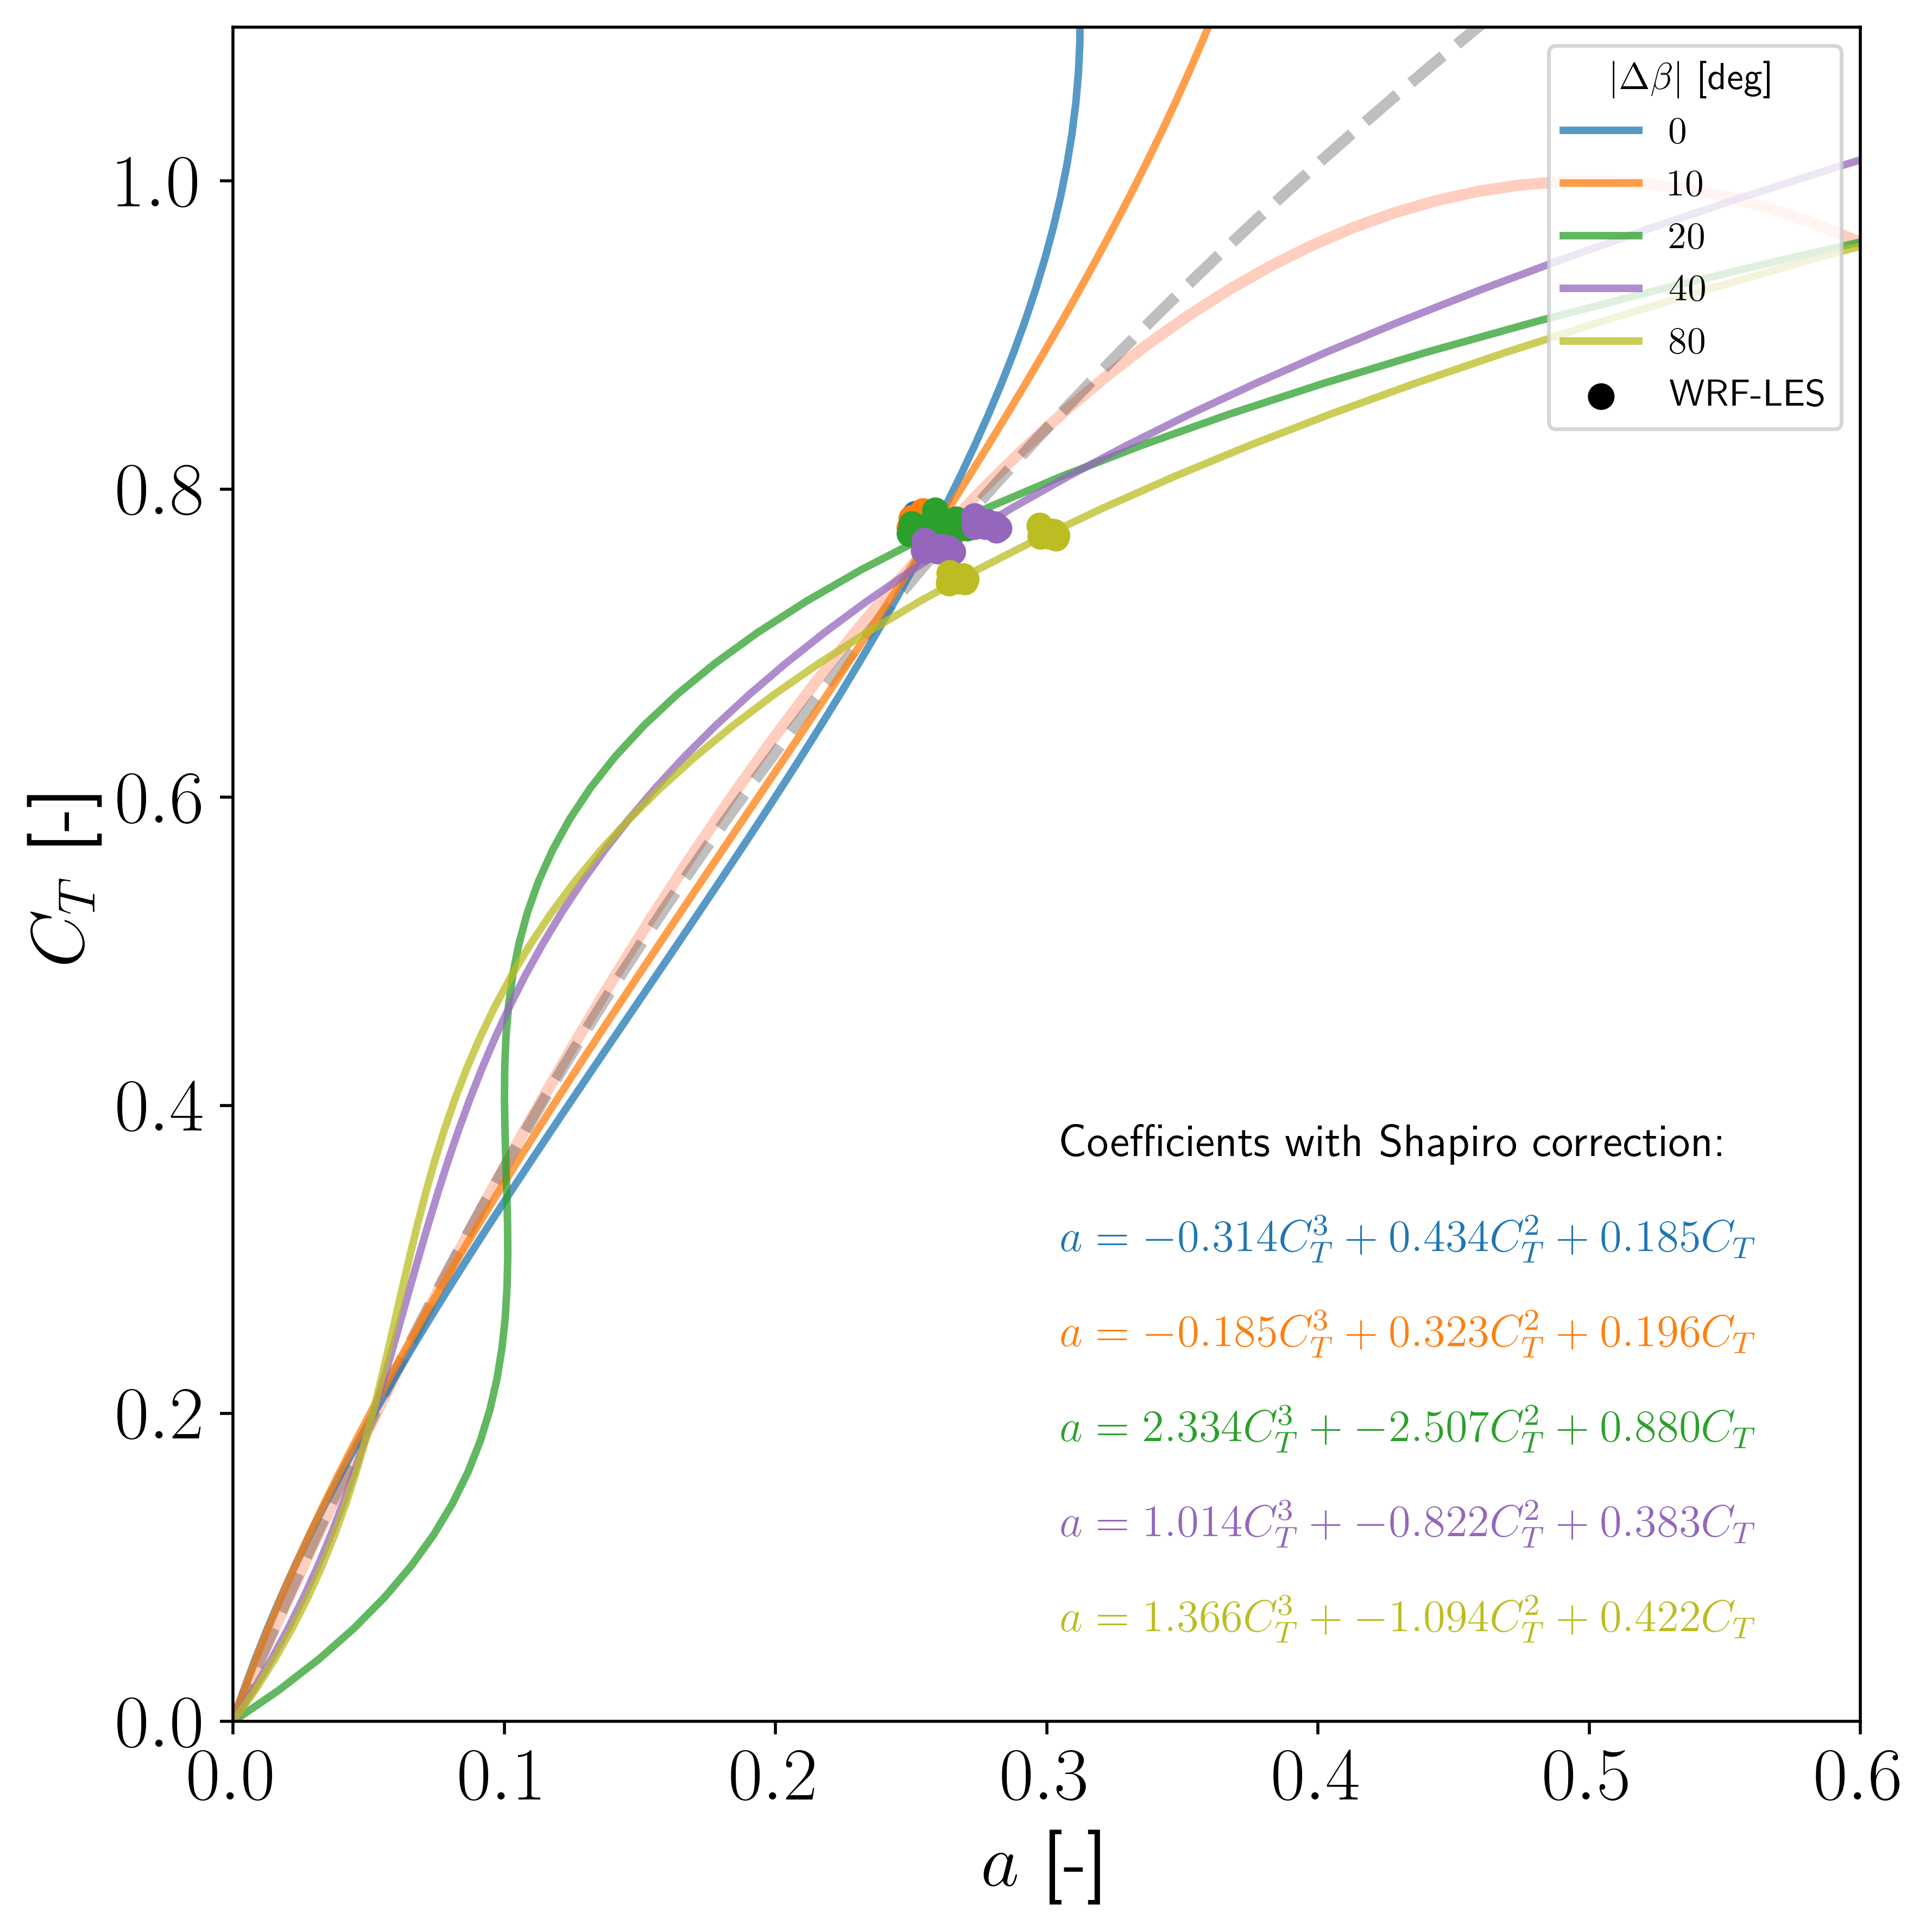

In [18]:
colors = sns.color_palette("tab10", 9)
# colors = colors[::-1]

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)
# fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True,sharex=True, sharey=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$0$')
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$10$')
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$20$')
# ax.plot(y_fit_v30, x_fit_v30, color=colors[3],linewidth=2,zorder=2,alpha=0.75,label='$30$')
ax.plot(y_fit_v40, x_fit_v40, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$40$')
# ax.plot(y_fit_v50, x_fit_v50, color=colors[5],linewidth=2,zorder=2,alpha=0.75,label='$50$')
# ax.plot(y_fit_v60, x_fit_v60, color=colors[6],linewidth=2,zorder=2,alpha=0.75,label='$80$')
# ax.plot(y_fit_v70, x_fit_v70, color=colors[7],linewidth=2,zorder=2,alpha=0.75,label='$70$')
ax.plot(y_fit_v80, x_fit_v80, color=colors[8],linewidth=2,zorder=2,alpha=0.75,label='$80$')

# ax.set_xlim([0.2,0.4])
# ax.set_ylim([0.5,1.0])

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.1])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

for i in range(len(indices_00)):
    mesh = ax.scatter(wrf_ind[indices_00[i]], wrf_cot[indices_00[i]], s=50, edgecolor='none',color=colors[0],zorder=3)

for i in range(len(indices_10)):
    mesh = ax.scatter(wrf_ind[indices_10[i]], wrf_cot[indices_10[i]], s=50, edgecolor='none',color=colors[1],zorder=3)

for i in range(len(indices_20)):
    mesh = ax.scatter(wrf_ind[indices_20[i]], wrf_cot[indices_20[i]], s=50, edgecolor='none',color=colors[2],zorder=3)

for i in range(len(indices_40)):
    mesh = ax.scatter(wrf_ind[indices_40[i]], wrf_cot[indices_40[i]], s=50, edgecolor='none',color=colors[4],zorder=3)

for i in range(len(indices_80)):
    mesh = ax.scatter(wrf_ind[indices_80[i]], wrf_cot[indices_80[i]], s=50, edgecolor='none',color=colors[8],zorder=3)

mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',label='WRF-LES')

ax.legend(title='$|\Delta \\beta|$ [deg]', loc='upper right')

fig.text(0.55,0.40, f'Coefficients with Shapiro correction:', ha='left', fontsize=12,rotation=0,color='k')
fig.text(0.55,0.35, f'$a = {a_fit_v00:0.3f}C_T^3 + {b_fit_v00:0.3f}C_T^2 + {c_fit_v00:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[0])
fig.text(0.55,0.30, f'$a = {a_fit_v10:0.3f}C_T^3 + {b_fit_v10:0.3f}C_T^2 + {c_fit_v10:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[1])
fig.text(0.55,0.25, f'$a = {a_fit_v20:0.3f}C_T^3 + {b_fit_v20:0.3f}C_T^2 + {c_fit_v20:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[2])
fig.text(0.55,0.20, f'$a = {a_fit_v40:0.3f}C_T^3 + {b_fit_v40:0.3f}C_T^2 + {c_fit_v40:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[4])
fig.text(0.55,0.15, f'$a = {a_fit_v80:0.3f}C_T^3 + {b_fit_v80:0.3f}C_T^2 + {c_fit_v80:0.3f}C_T$', ha='left', fontsize=12,rotation=0,color=colors[8])

# plt.savefig(f"./figs/wrf_10MW_rotor.png", bbox_inches="tight", dpi=600)

plt.show()

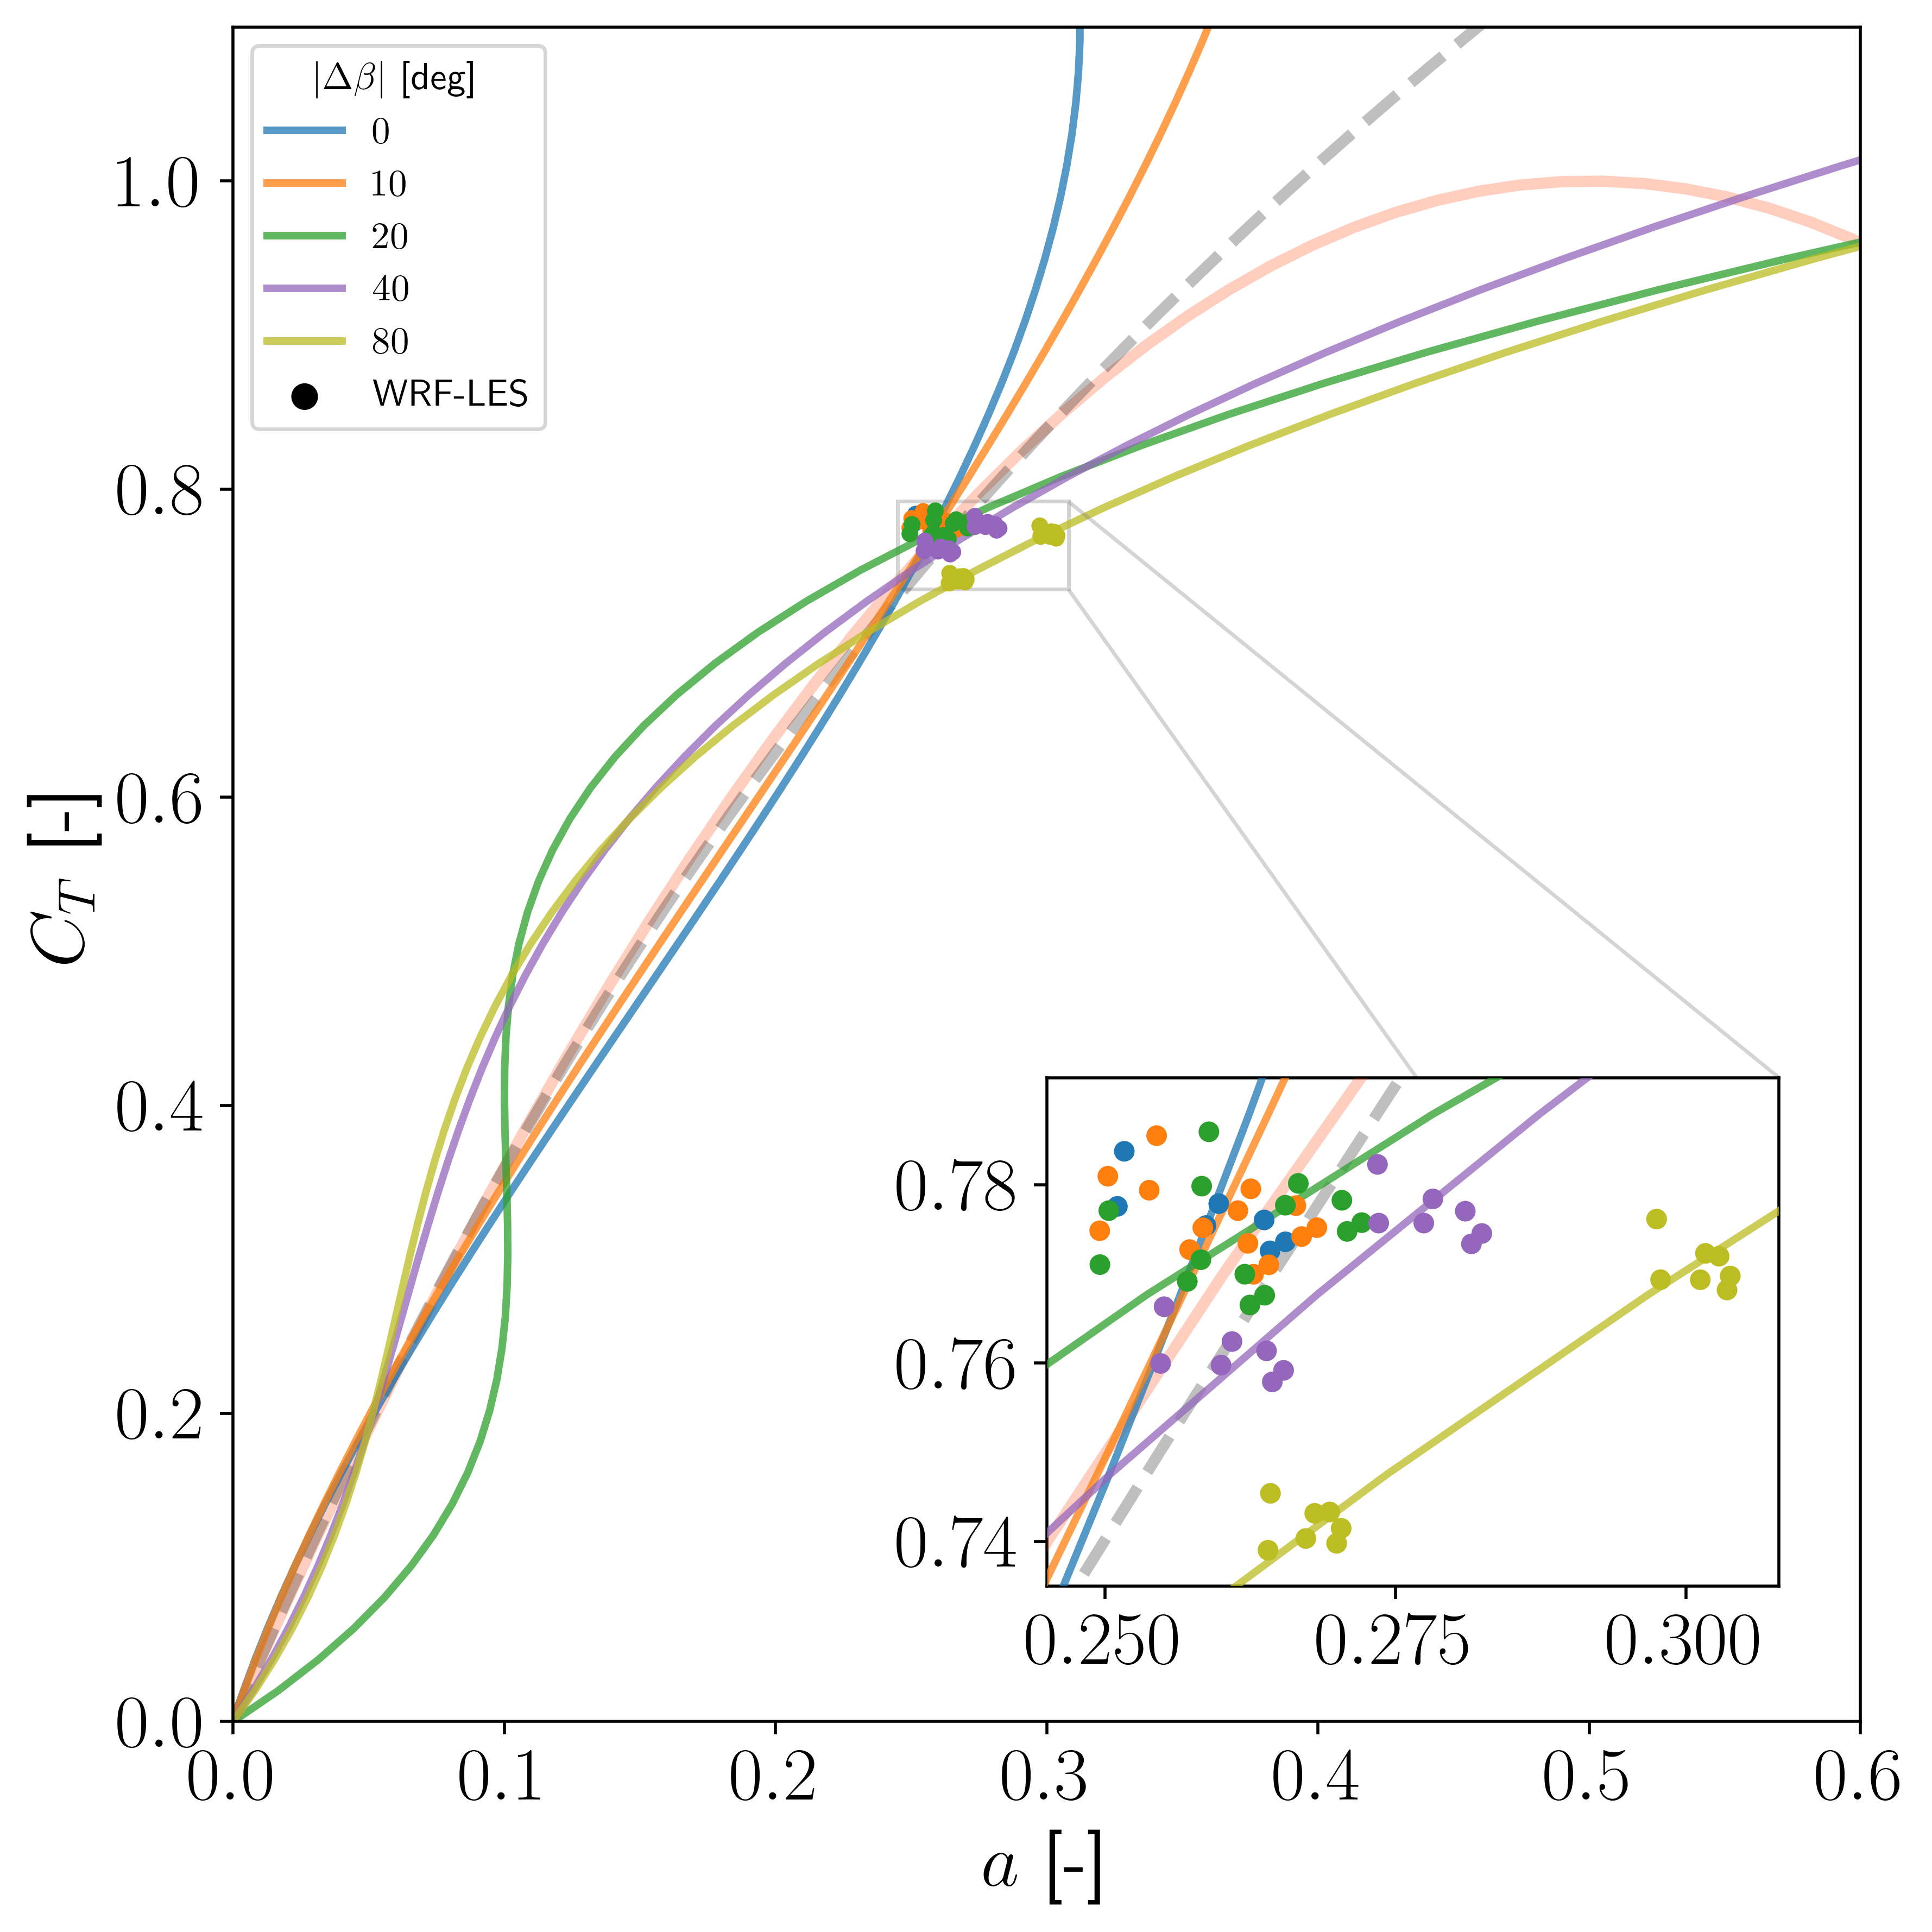

In [19]:
# Create the main figure and axis
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$0$')
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$10$')
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$20$')
ax.plot(y_fit_v40, x_fit_v40, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$40$')
ax.plot(y_fit_v80, x_fit_v80, color=colors[8],linewidth=2,zorder=2,alpha=0.75,label='$80$')

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.1])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

for i in range(len(indices_00)):
    mesh = ax.scatter(wrf_ind[indices_00[i]], wrf_cot[indices_00[i]], s=20, edgecolor='none',color=colors[0],zorder=3)

for i in range(len(indices_10)):
    mesh = ax.scatter(wrf_ind[indices_10[i]], wrf_cot[indices_10[i]], s=20, edgecolor='none',color=colors[1],zorder=3)

for i in range(len(indices_20)):
    mesh = ax.scatter(wrf_ind[indices_20[i]], wrf_cot[indices_20[i]], s=20, edgecolor='none',color=colors[2],zorder=3)

for i in range(len(indices_40)):
    mesh = ax.scatter(wrf_ind[indices_40[i]], wrf_cot[indices_40[i]], s=20, edgecolor='none',color=colors[4],zorder=3)

for i in range(len(indices_80)):
    mesh = ax.scatter(wrf_ind[indices_80[i]], wrf_cot[indices_80[i]], s=20, edgecolor='none',color=colors[8],zorder=3)

mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',label='WRF-LES')

ax.legend(title='$|\Delta \\beta|$ [deg]', loc='upper left')

# === Add inset axes ===
# Example: Zoom into a cluster near a=0.32, CT=0.7

inset_ax = ax.inset_axes(
   [0.5, 0.08, 0.45, 0.3],  # [x, y, width, height] w.r.t. axes
    xlim=[0.245, 0.308], ylim=[0.735, 0.792] # sets viewport & tells relation to main axes
    # xticklabels=[], yticklabels=[]
)

# # Plot the same data inside the inset
inset_ax.plot(a_mom, ct_mom, '#ff3c00', linewidth=3, alpha=0.25,zorder=3)
inset_ax.plot(a_mad, ct_mad, 'k--', linewidth=3, alpha=0.25,zorder=3)

# # Re-plot the fitted curves
inset_ax.plot(y_fit_v00, x_fit_v00, color=colors[0], linewidth=2, alpha=0.75,zorder=3)
inset_ax.plot(y_fit_v10, x_fit_v10, color=colors[1], linewidth=2, alpha=0.75,zorder=3)
inset_ax.plot(y_fit_v20, x_fit_v20, color=colors[2], linewidth=2, alpha=0.75,zorder=3)
inset_ax.plot(y_fit_v40, x_fit_v40, color=colors[4], linewidth=2, alpha=0.75,zorder=3)
inset_ax.plot(y_fit_v80, x_fit_v80, color=colors[8], linewidth=2, alpha=0.75,zorder=3)

import matplotlib.patches as patches

rect = patches.Rectangle((0.2, 0.6), 0.2, 0.2, facecolor='white', edgecolor='k',zorder=2)
inset_ax.add_patch(rect)

# Re-plot the scatter data
for i in indices_00:
    inset_ax.scatter(wrf_ind[i], wrf_cot[i], s=30, edgecolor='none', color=colors[0],zorder=4)
for i in indices_10:
    inset_ax.scatter(wrf_ind[i], wrf_cot[i], s=30, edgecolor='none', color=colors[1],zorder=4)
for i in indices_20:
    inset_ax.scatter(wrf_ind[i], wrf_cot[i], s=30, edgecolor='none', color=colors[2],zorder=4)
for i in indices_40:
    inset_ax.scatter(wrf_ind[i], wrf_cot[i], s=30, edgecolor='none', color=colors[4],zorder=4)
for i in indices_80:
    inset_ax.scatter(wrf_ind[i], wrf_cot[i], s=30, edgecolor='none', color=colors[8],zorder=4)

# Add a rectangle on the main plot showing the zoomed region
mark_inset(ax, inset_ax, loc1=1, loc2=4, fc="none", ec="0.5",zorder=1,alpha=1/3)

plt.show()

In [20]:
subset_indices = [i for i, (s, v) in enumerate(training)]
wrf_ref_index  = [i for i, (s, v) in enumerate(training) if (v == 0 and s == 0)]

In [21]:
wrf_power_dev     = postproc.per_error(wrf_pow, wrf_pow[wrf_ref_index])
wrf_thrust_dev    = postproc.per_error(wrf_thr, wrf_thr[wrf_ref_index])
wrf_induction_dev = postproc.per_error(wrf_ind, wrf_ind[wrf_ref_index])

np.savez("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_dim_absV_allS.npz", pow=wrf_pow, thr=wrf_thr, ind=wrf_ind)

np.savez("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_dev_absV_allS.npz", pow=wrf_power_dev, thr=wrf_thrust_dev, ind=wrf_induction_dev)

In [22]:
replacements = {
    'sn030151': 'sn06',
    'sn020101': 'sn04',
    'sn010050': 'sn02',
    's000000' : 's00',
    's010050' : 's02',
    's020101' : 's04',
    's030151' : 's06',
    'vn402010' : 'vn80',
    'vn351759' : 'vn70',
    'vn301508' : 'vn60',
    'vn251256' : 'vn50',
    'vn201005' : 'vn40',
    'vn150754' : 'vn30',
    'vn100503' : 'vn20',
    'vn050251' : 'vn10',
    'v000000'  : 'v00',
    'v050251'  : 'v10',
    'v100503'  : 'v20',
    'v150754'  : 'v30',
    'v201005'  : 'v40',
    'v251256'  : 'v50',
    'v301508'  : 'v60',
    'v351759'  : 'v70',
    'v402010'  : 'v80'
}

In [23]:
n_levels = 100

pow_levels = plt.colormaps['seismic'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-10, vmax=10)  # Normalize power to [0, 1]
pow_cmap = [pow_levels(int(norm(p) * (n_levels - 1))) for p in wrf_power_dev]  # Map power to discrete colors

thr_levels = plt.colormaps['PiYG'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-5, vmax=5)  # Normalize power to [0, 1]
thr_cmap = [thr_levels(int(norm(t) * (n_levels - 1))) for t in wrf_thrust_dev]  # Map power to discrete colors

ind_levels = plt.colormaps['Spectral'].resampled(n_levels)  # Extract 13 colors from 'viridis'
norm = mcolors.Normalize(vmin=-15, vmax=15)  # Normalize power to [0, 1]
ind_cmap = [ind_levels(int(norm(a) * (n_levels - 1))) for a in wrf_induction_dev]  # Map power to discrete colors

In [24]:
sub_cases = [np.array(casenames)[subset_indices]]

formatted_cases = []
for name in sub_cases[0]:
    for old, new in replacements.items():
        if old in name:
            name = name.replace(old, new)
    formatted_cases.append(name)

# Result
new_names = np.array(formatted_cases)

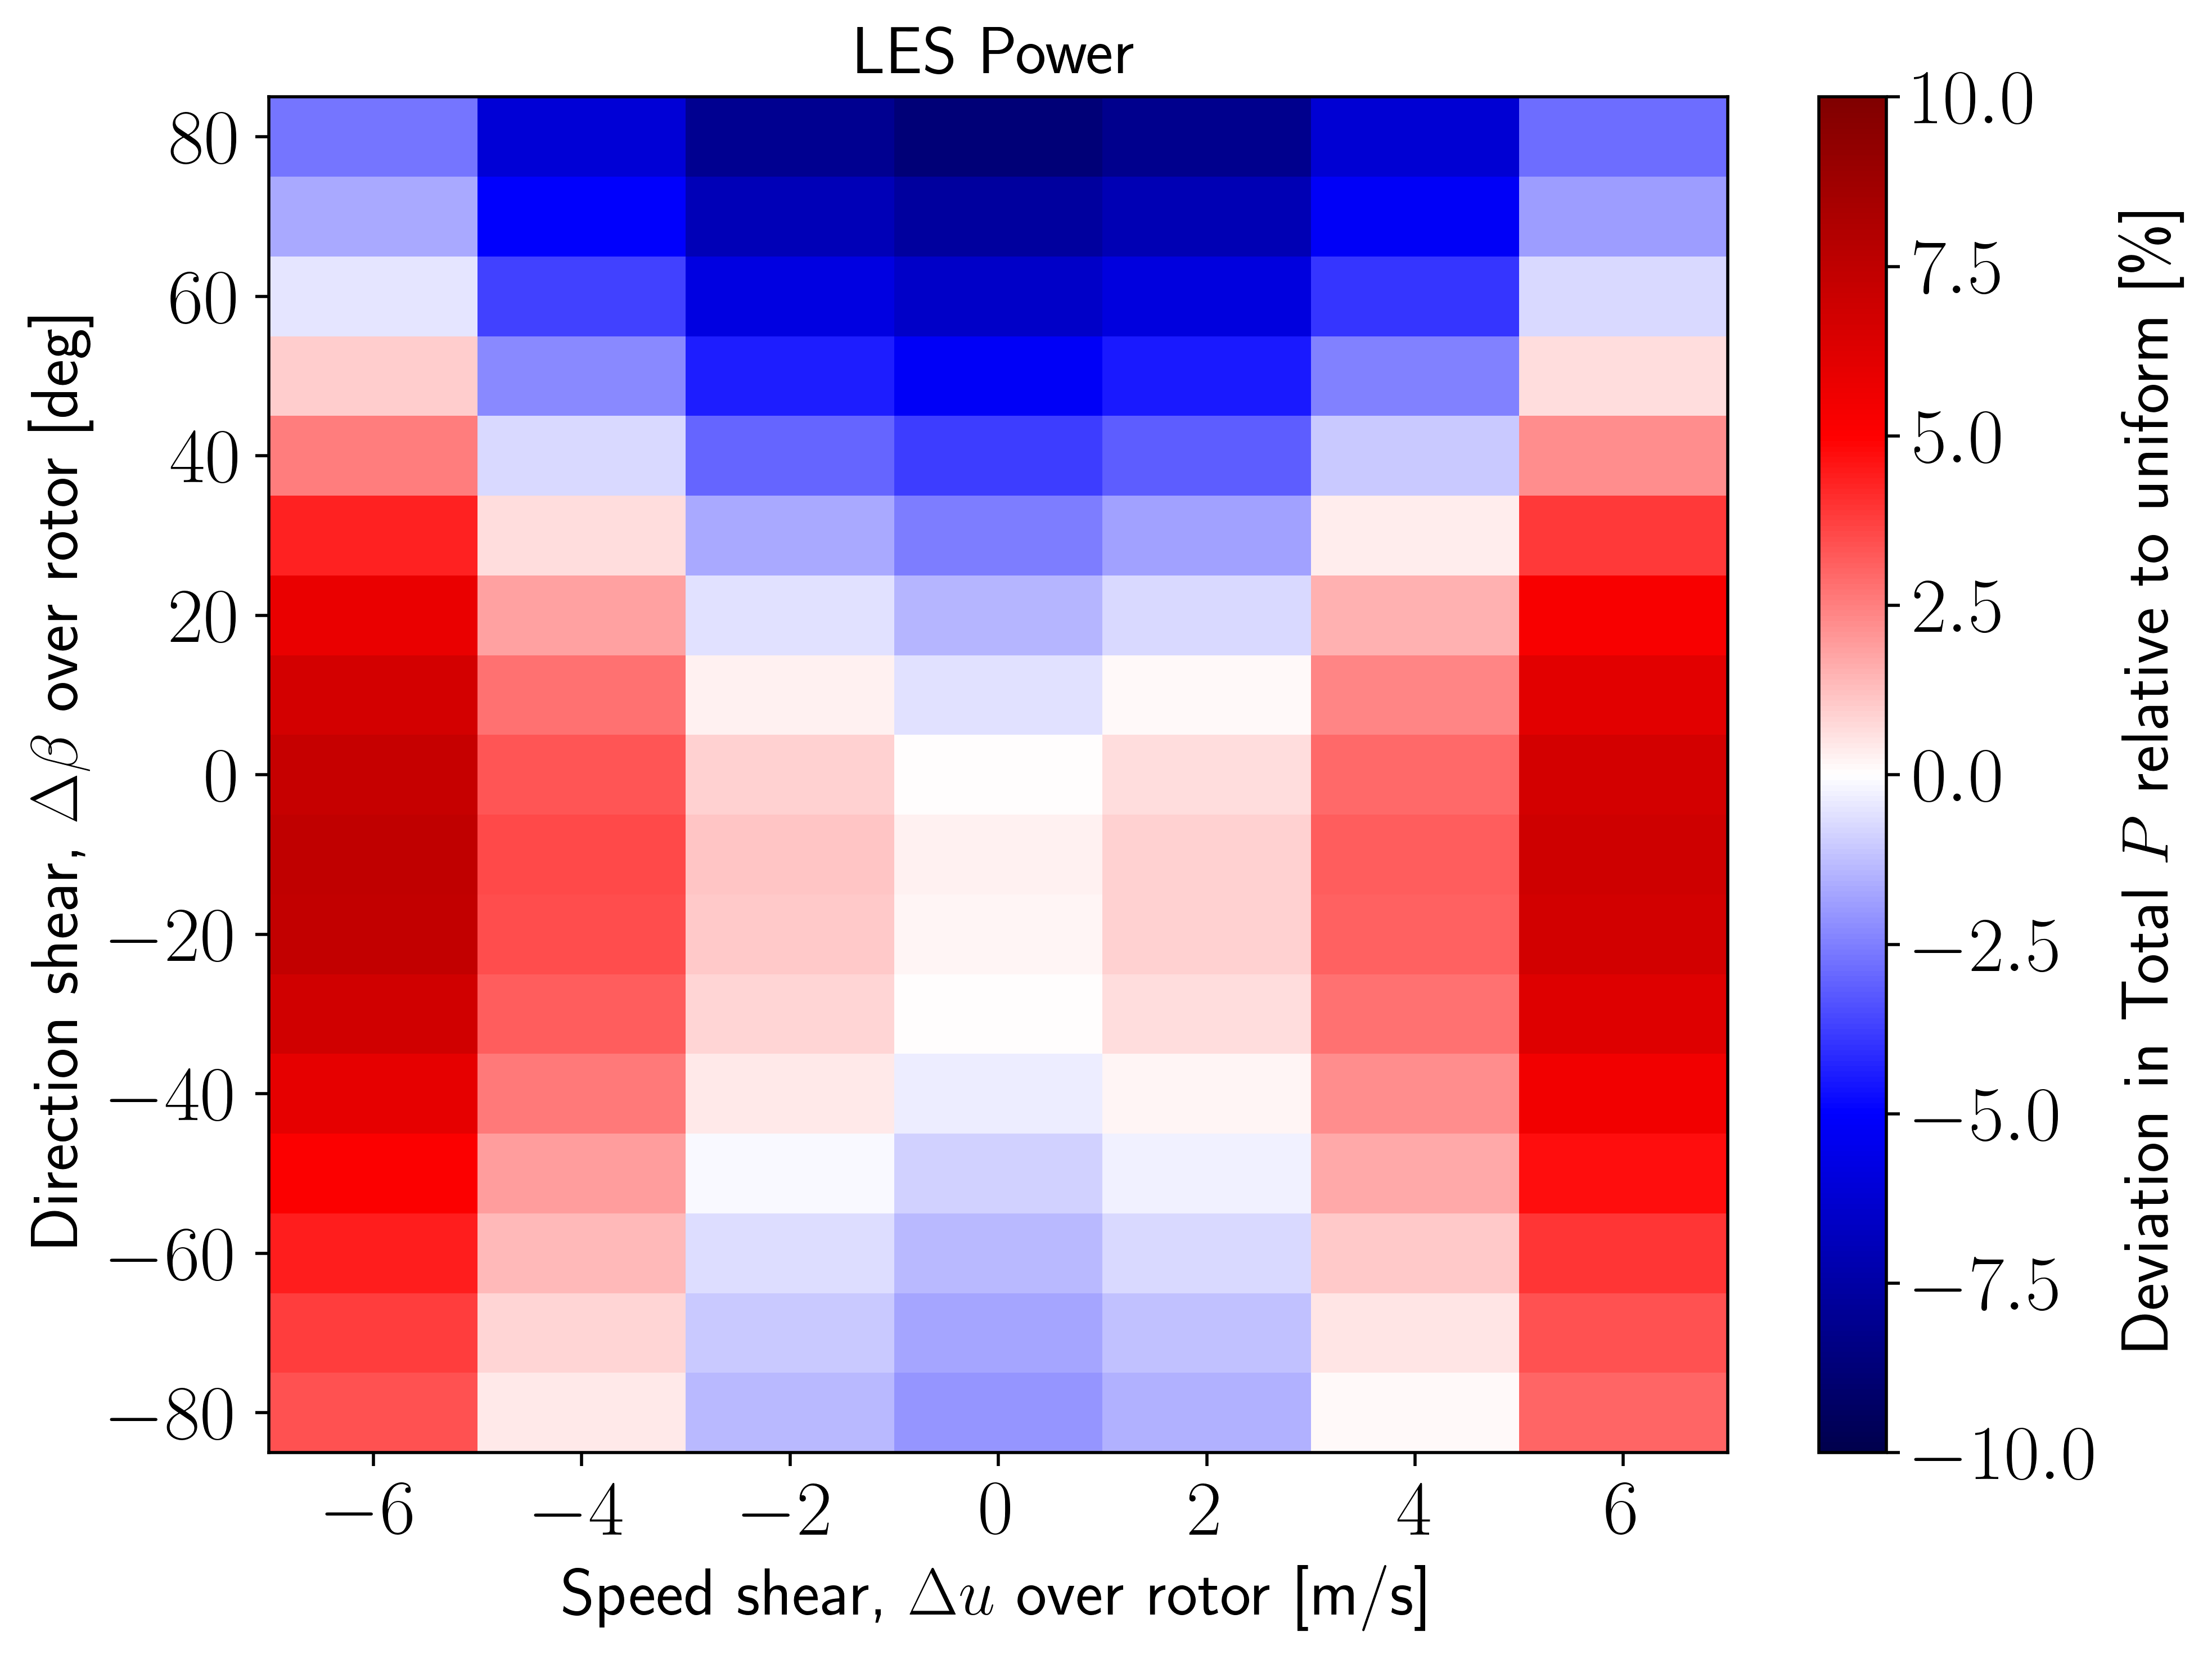

In [66]:
Z = np.zeros((len(veer),len(shear)))

for count in range(len(coords)):

    Z[coords[count][1],coords[count][0]] = wrf_power_dev[count]

plt.figure(figsize=(8, 6))
contour = plt.pcolormesh(shear, veer[::-1], Z, cmap='seismic',vmin=-10,vmax=10)  # or use plt.contour
cbar = plt.colorbar(contour)
cbar.set_label(r'Deviation in Total $P$ relative to uniform [\%]', fontsize=17)

plt.xticks(shear)  # every second x tick
plt.yticks(veer[::-1][::2])  # every second y tick

# Labels and formatting
plt.xlabel('Speed shear, $\Delta u$ over rotor [m/s]', fontsize=17)
plt.ylabel('Direction shear, $\Delta \\beta$ over rotor [deg]', fontsize=17)
plt.title('LES Power', fontsize=17)
plt.tight_layout()
plt.show()

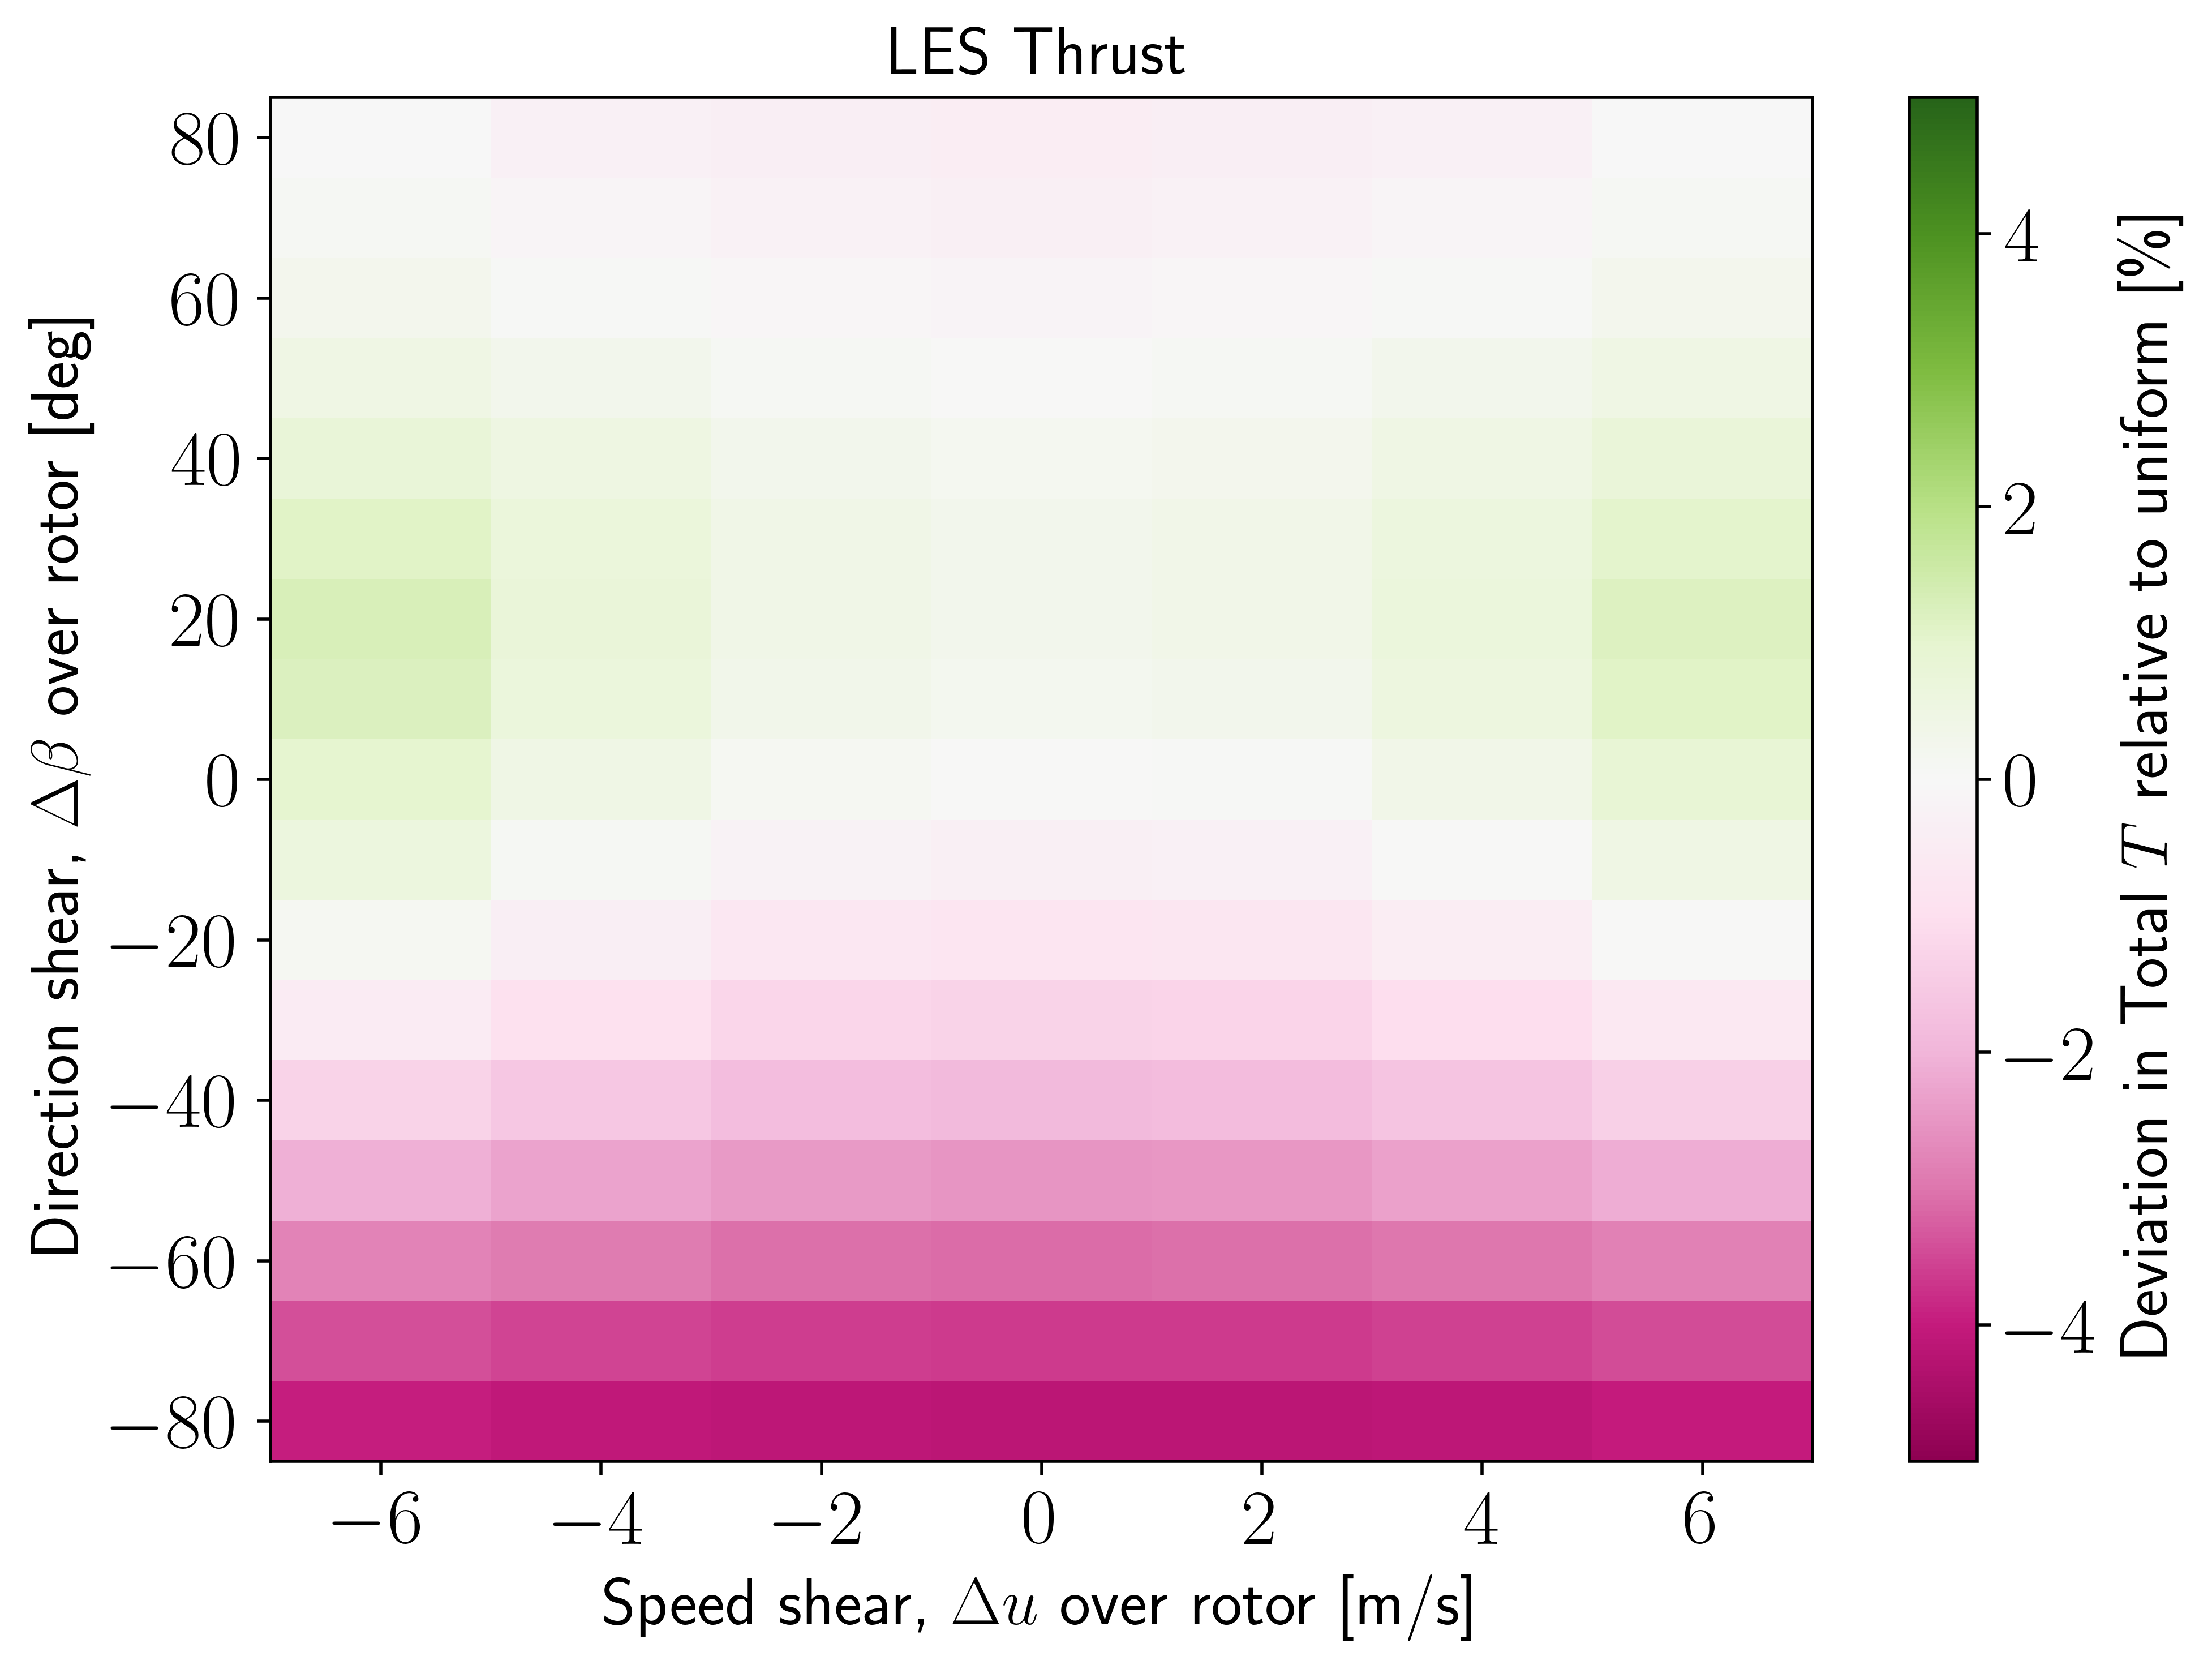

In [65]:
Z = np.zeros((len(veer),len(shear)))

for count in range(len(coords)):

    Z[coords[count][1],coords[count][0]] = wrf_thrust_dev[count]


plt.figure(figsize=(8, 6))
contour = plt.pcolormesh(shear, veer[::-1], Z, cmap='PiYG',vmin=-5,vmax=5)  # or use plt.contour
cbar = plt.colorbar(contour)
cbar.set_label(r'Deviation in Total $T$ relative to uniform [\%]', fontsize=17)

plt.xticks(shear)  # every second x tick
plt.yticks(veer[::-1][::2])  # every second y tick

# Labels and formatting
plt.xlabel('Speed shear, $\Delta u$ over rotor [m/s]', fontsize=17)
plt.ylabel('Direction shear, $\Delta \\beta$ over rotor [deg]', fontsize=17)
plt.title('LES Thrust', fontsize=17)
plt.tight_layout()
plt.show()

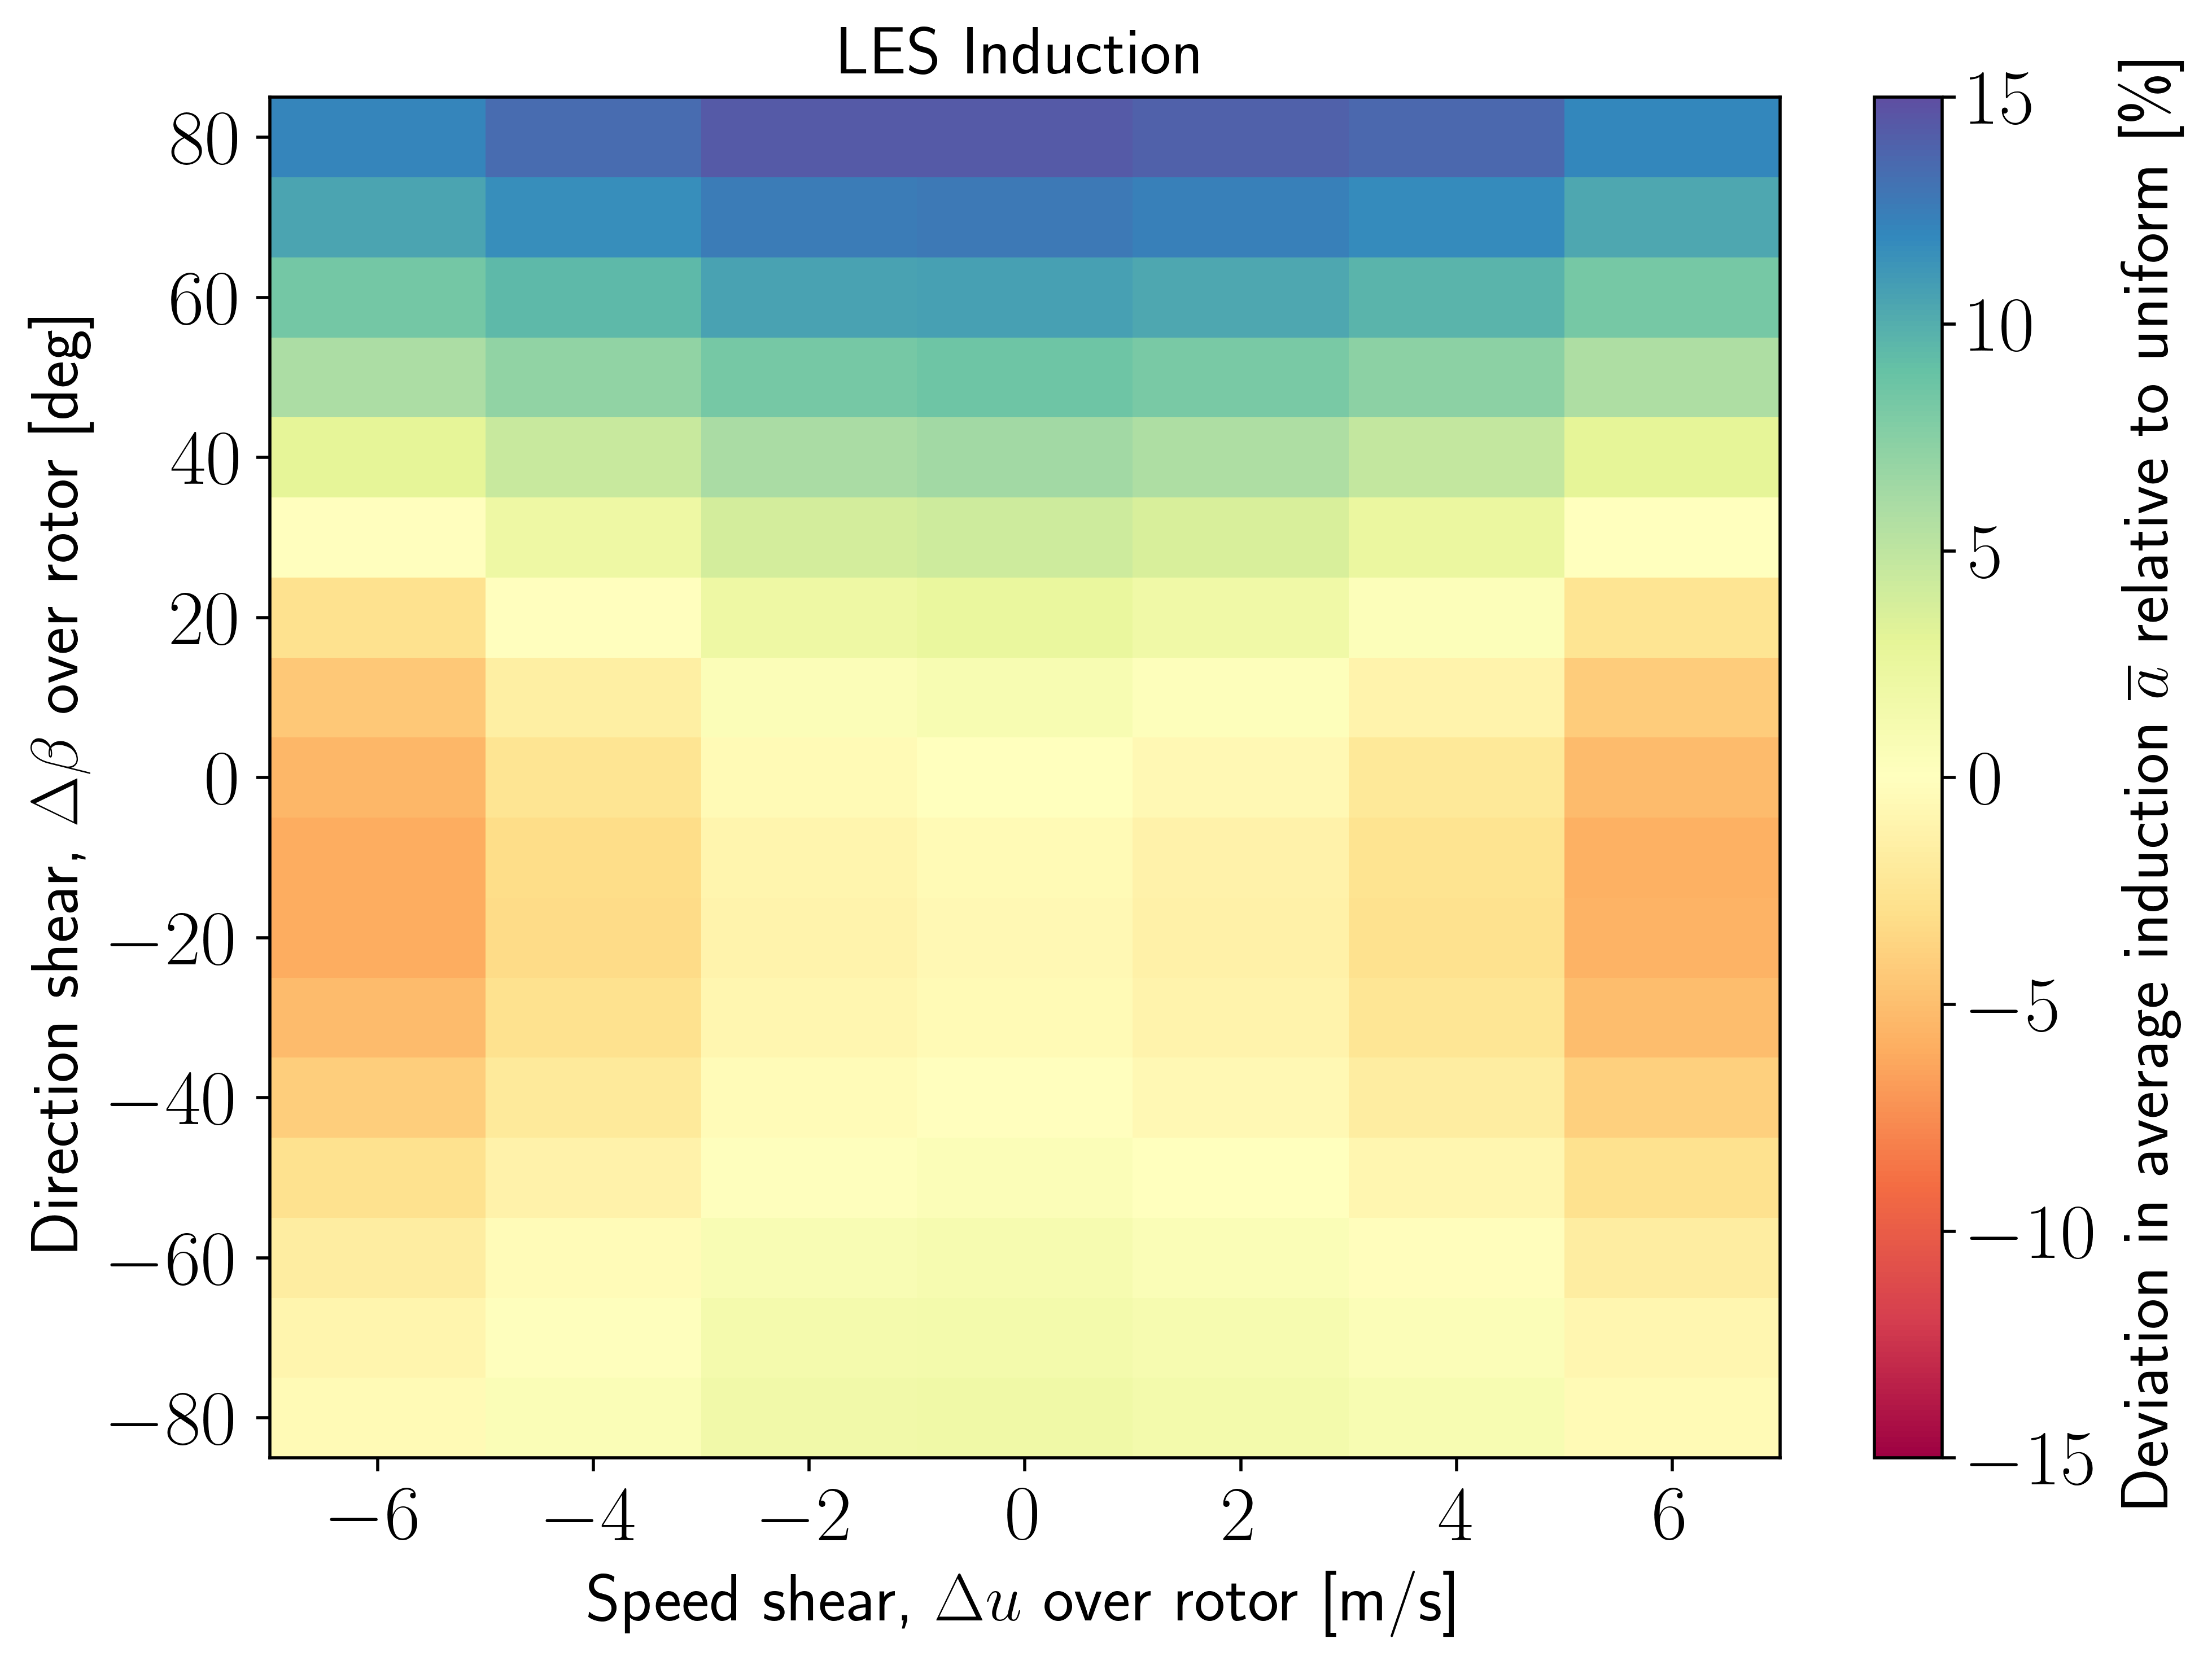

In [67]:
Z = np.zeros((len(veer),len(shear)))

for count in range(len(coords)):

    Z[coords[count][1],coords[count][0]] = wrf_induction_dev[count]


plt.figure(figsize=(8, 6))
contour = plt.pcolormesh(shear, veer[::-1], Z, cmap='Spectral',vmin=-15,vmax=15)  # or use plt.contour
cbar = plt.colorbar(contour)
cbar.set_label(r'Deviation in average induction $\overline{a}$ relative to uniform [\%]', fontsize=17)


plt.xticks(shear)  # every second x tick
plt.yticks(veer[::-1][::2])  # every second y tick

# Labels and formatting
plt.xlabel('Speed shear, $\Delta u$ over rotor [m/s]', fontsize=17)
plt.ylabel('Direction shear, $\Delta \\beta$ over rotor [deg]', fontsize=17)
plt.title('LES Induction', fontsize=17)
plt.tight_layout()
plt.show()

In [28]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, KraghAerodynamics, NoTangentialInduction, Madsen_Rotor_Momentum_AbsV_AllS

In [29]:
rotor = IEA10MW()
veers = (np.array(training)[:, 1]/10).astype(int)

mit_ind = np.zeros_like(wrf_pow, dtype='float')
mit_cot = np.zeros_like(wrf_pow, dtype='float')
mit_thr = np.zeros_like(wrf_pow, dtype='float')
mit_cop = np.zeros_like(wrf_pow, dtype='float')
mit_pow = np.zeros_like(wrf_pow, dtype='float')
iters   = np.zeros_like(wrf_pow, dtype='float')

mit_w   = np.zeros_like(wrf_pow, dtype='float')
mit_cax = np.zeros_like(wrf_pow, dtype='float')
mit_vax = np.zeros_like(wrf_pow, dtype='float')
mit_vtn = np.zeros_like(wrf_pow, dtype='float')

for count in range(len(mit_ind)):

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=20,Ntheta=180), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=Madsen_Rotor_Momentum_AbsV_AllS(veer=veers[count]), tangential_induction_model=NoTangentialInduction())

    tsr = wrf_tsr[count] * rotor.R / R

    t = np.linspace(0,2*np.pi,Nsct)
    r = rOverR

    interpU = RegularGridInterpolator(
    (r, t), U_loc[:,:,count], bounds_error=False, fill_value=None
    )

    interpW = RegularGridInterpolator(
    (r, t), dir_loc[:,:,count], bounds_error=False, fill_value=None
    )

    t_new = np.linspace(0,2*np.pi,180)
    r_new = np.linspace(0,1,20)

    R_new, T_new = np.meshgrid(r_new, t_new, indexing='ij')

    points = np.column_stack((R_new.ravel(), T_new.ravel()))  # shape (Nr*Nt, 2)
    U_interp_flat = interpU(points)
    W_interp_flat = interpW(points)
    U_interp = U_interp_flat.reshape(R_new.shape)
    W_interp = W_interp_flat.reshape(R_new.shape)

    r_dim = r_new * rotor.R

    tsr_adj = 0.46

    sol = bem(0, tsr-tsr_adj, 0, U = U_interp, wdir=W_interp,veer=veers[count])
    # sol = bem(0, tsr, 0, U = U_interp, wdir=W_interp,veer=veers[count])

    rho = 1.225

    Nr = 20  # number of radial points
    Ntheta = 180  # number of azimuthal points
    r =sol.geom.mu_mesh[:,0]*rotor.R

    theta = sol.geom.theta_mesh[0,:]
    R_grid, Theta_grid = np.meshgrid(r, theta, indexing='ij')  # shape (Nr, Ntheta)

    # Compute local area element: dA = r * dr * dθ
    dr = 0.05 + (rotor.R - rotor.hub_radius) / (Nr - 1)
    dtheta = 2 * np.pi / Ntheta
    dA = R_grid * dr * dtheta  # shape (Nr, Ntheta)

    integrand = (1/2 * rho * sol.solidity('sector') * (sol.W('sector') * Uhub[count])**2 * sol.Cn('sector')).T * r * dr * dtheta
    T_total = np.sum(integrand)

    integrand = (1/2 * rho * sol.solidity('sector') * (sol.W('sector') * Uhub[count])**2 * sol.Ctan('sector')).T * r**2 * dr * dtheta
    P_total = np.sum(integrand) * ((tsr-tsr_adj) * Uhub[count] / rotor.R) 

    mit_cot[count] = sol.Ct()
    mit_thr[count] = T_total/1e3
    mit_pow[count] = P_total/1e6
    mit_cop[count] = sol.Cp()
    mit_ind[count] = sol.a()
    iters[count]   = sol.niter
    mit_w[count]   = sol.W()
    mit_cax[count] = sol.Cx()
    mit_vax[count] = sol.Vax()
    mit_vtn[count] = sol.Vtan()
    
iters

array([ 8.,  9.,  9.,  7.,  7.,  5., 11.,  5.,  5.,  5., 13.,  5.,  9.,
       10., 13., 13., 14.,  9.,  9.,  9.,  8.,  7.,  5., 11.,  5.,  5.,
        5., 14.,  6.,  9., 10., 13., 14., 14.,  9.,  9.,  9.,  8.,  8.,
        5., 12.,  5.,  5.,  4., 14.,  6.,  9., 10., 13., 14., 14.,  9.,
        9.,  9.,  8.,  8.,  5., 12.,  5.,  5.,  4., 14.,  6., 10., 10.,
       13., 14., 14.,  9.,  9.,  9.,  8.,  8.,  5., 12.,  5.,  5.,  4.,
       14.,  6., 10., 10., 13., 14., 14.,  9.,  9.,  9.,  8.,  8.,  5.,
       12.,  5.,  5.,  4., 14.,  6.,  9., 10., 13., 14., 14.,  9.,  9.,
        9.,  8.,  7.,  5., 12.,  5.,  5.,  5., 14.,  6.,  9., 10., 13.,
       14., 14.])

In [30]:
mit_ref_index = wrf_ref_index

mit_power_dev     = postproc.per_error(mit_cop, mit_cop[mit_ref_index])
mit_thrust_dev    = postproc.per_error(mit_thr, mit_thr[mit_ref_index])
mit_induction_dev = postproc.per_error(mit_ind, mit_ind[mit_ref_index])

np.savez("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/mitrotor_dim_absV_AllS.npz", pow=mit_pow, thr=mit_thr, ind=mit_ind)

np.savez("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/mitrotor_dev_absV_AllS.npz", pow=mit_power_dev, thr=mit_thrust_dev, ind=mit_induction_dev)

# np.save("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/cases_absV_AllS.npy", new_names)

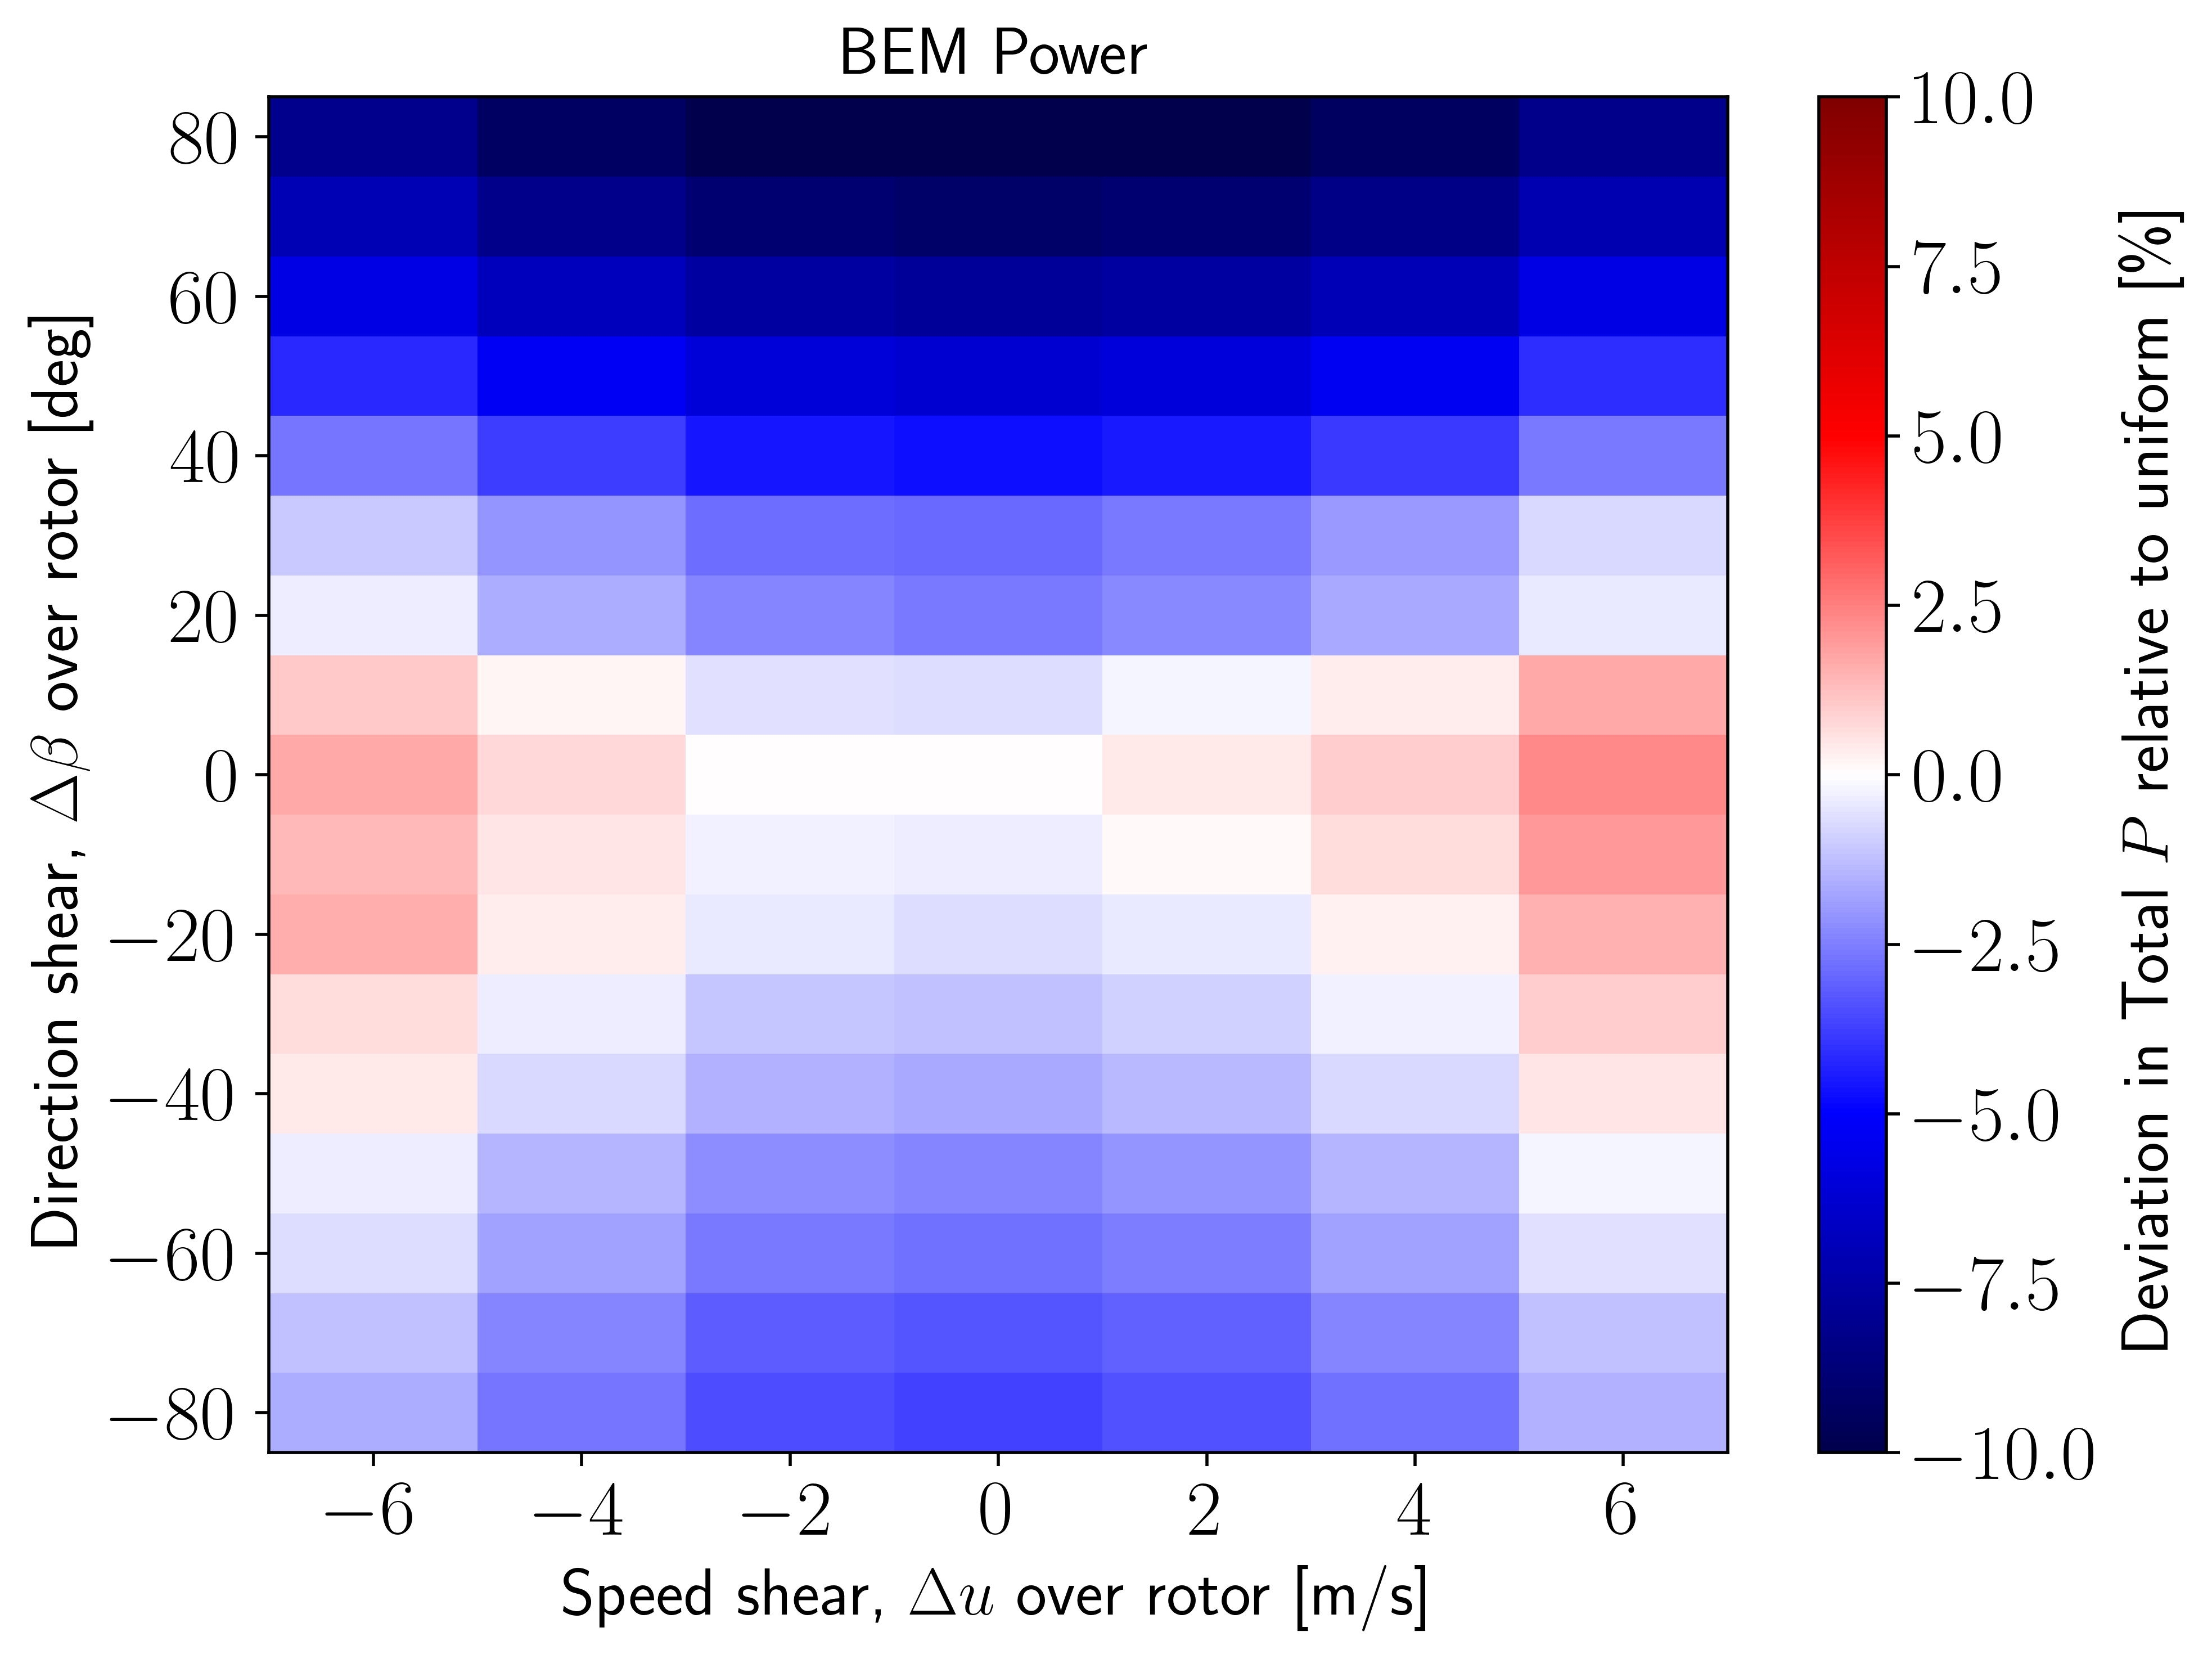

In [68]:
Z = np.zeros((len(veer),len(shear)))

for count in range(len(coords)):

    Z[coords[count][1],coords[count][0]] = mit_power_dev[count]

plt.figure(figsize=(8, 6))
contour = plt.pcolormesh(shear, veer[::-1], Z, cmap='seismic',vmin=-10,vmax=10)  # or use plt.contour
cbar = plt.colorbar(contour)
cbar.set_label(r'Deviation in Total $P$ relative to uniform [\%]', fontsize=17)

plt.xticks(shear)  # every second x tick
plt.yticks(veer[::-1][::2])  # every second y tick

# Labels and formatting
plt.xlabel('Speed shear, $\Delta u$ over rotor [m/s]', fontsize=17)
plt.ylabel('Direction shear, $\Delta \\beta$ over rotor [deg]', fontsize=17)
plt.title('BEM Power', fontsize=17)
plt.tight_layout()
plt.show()

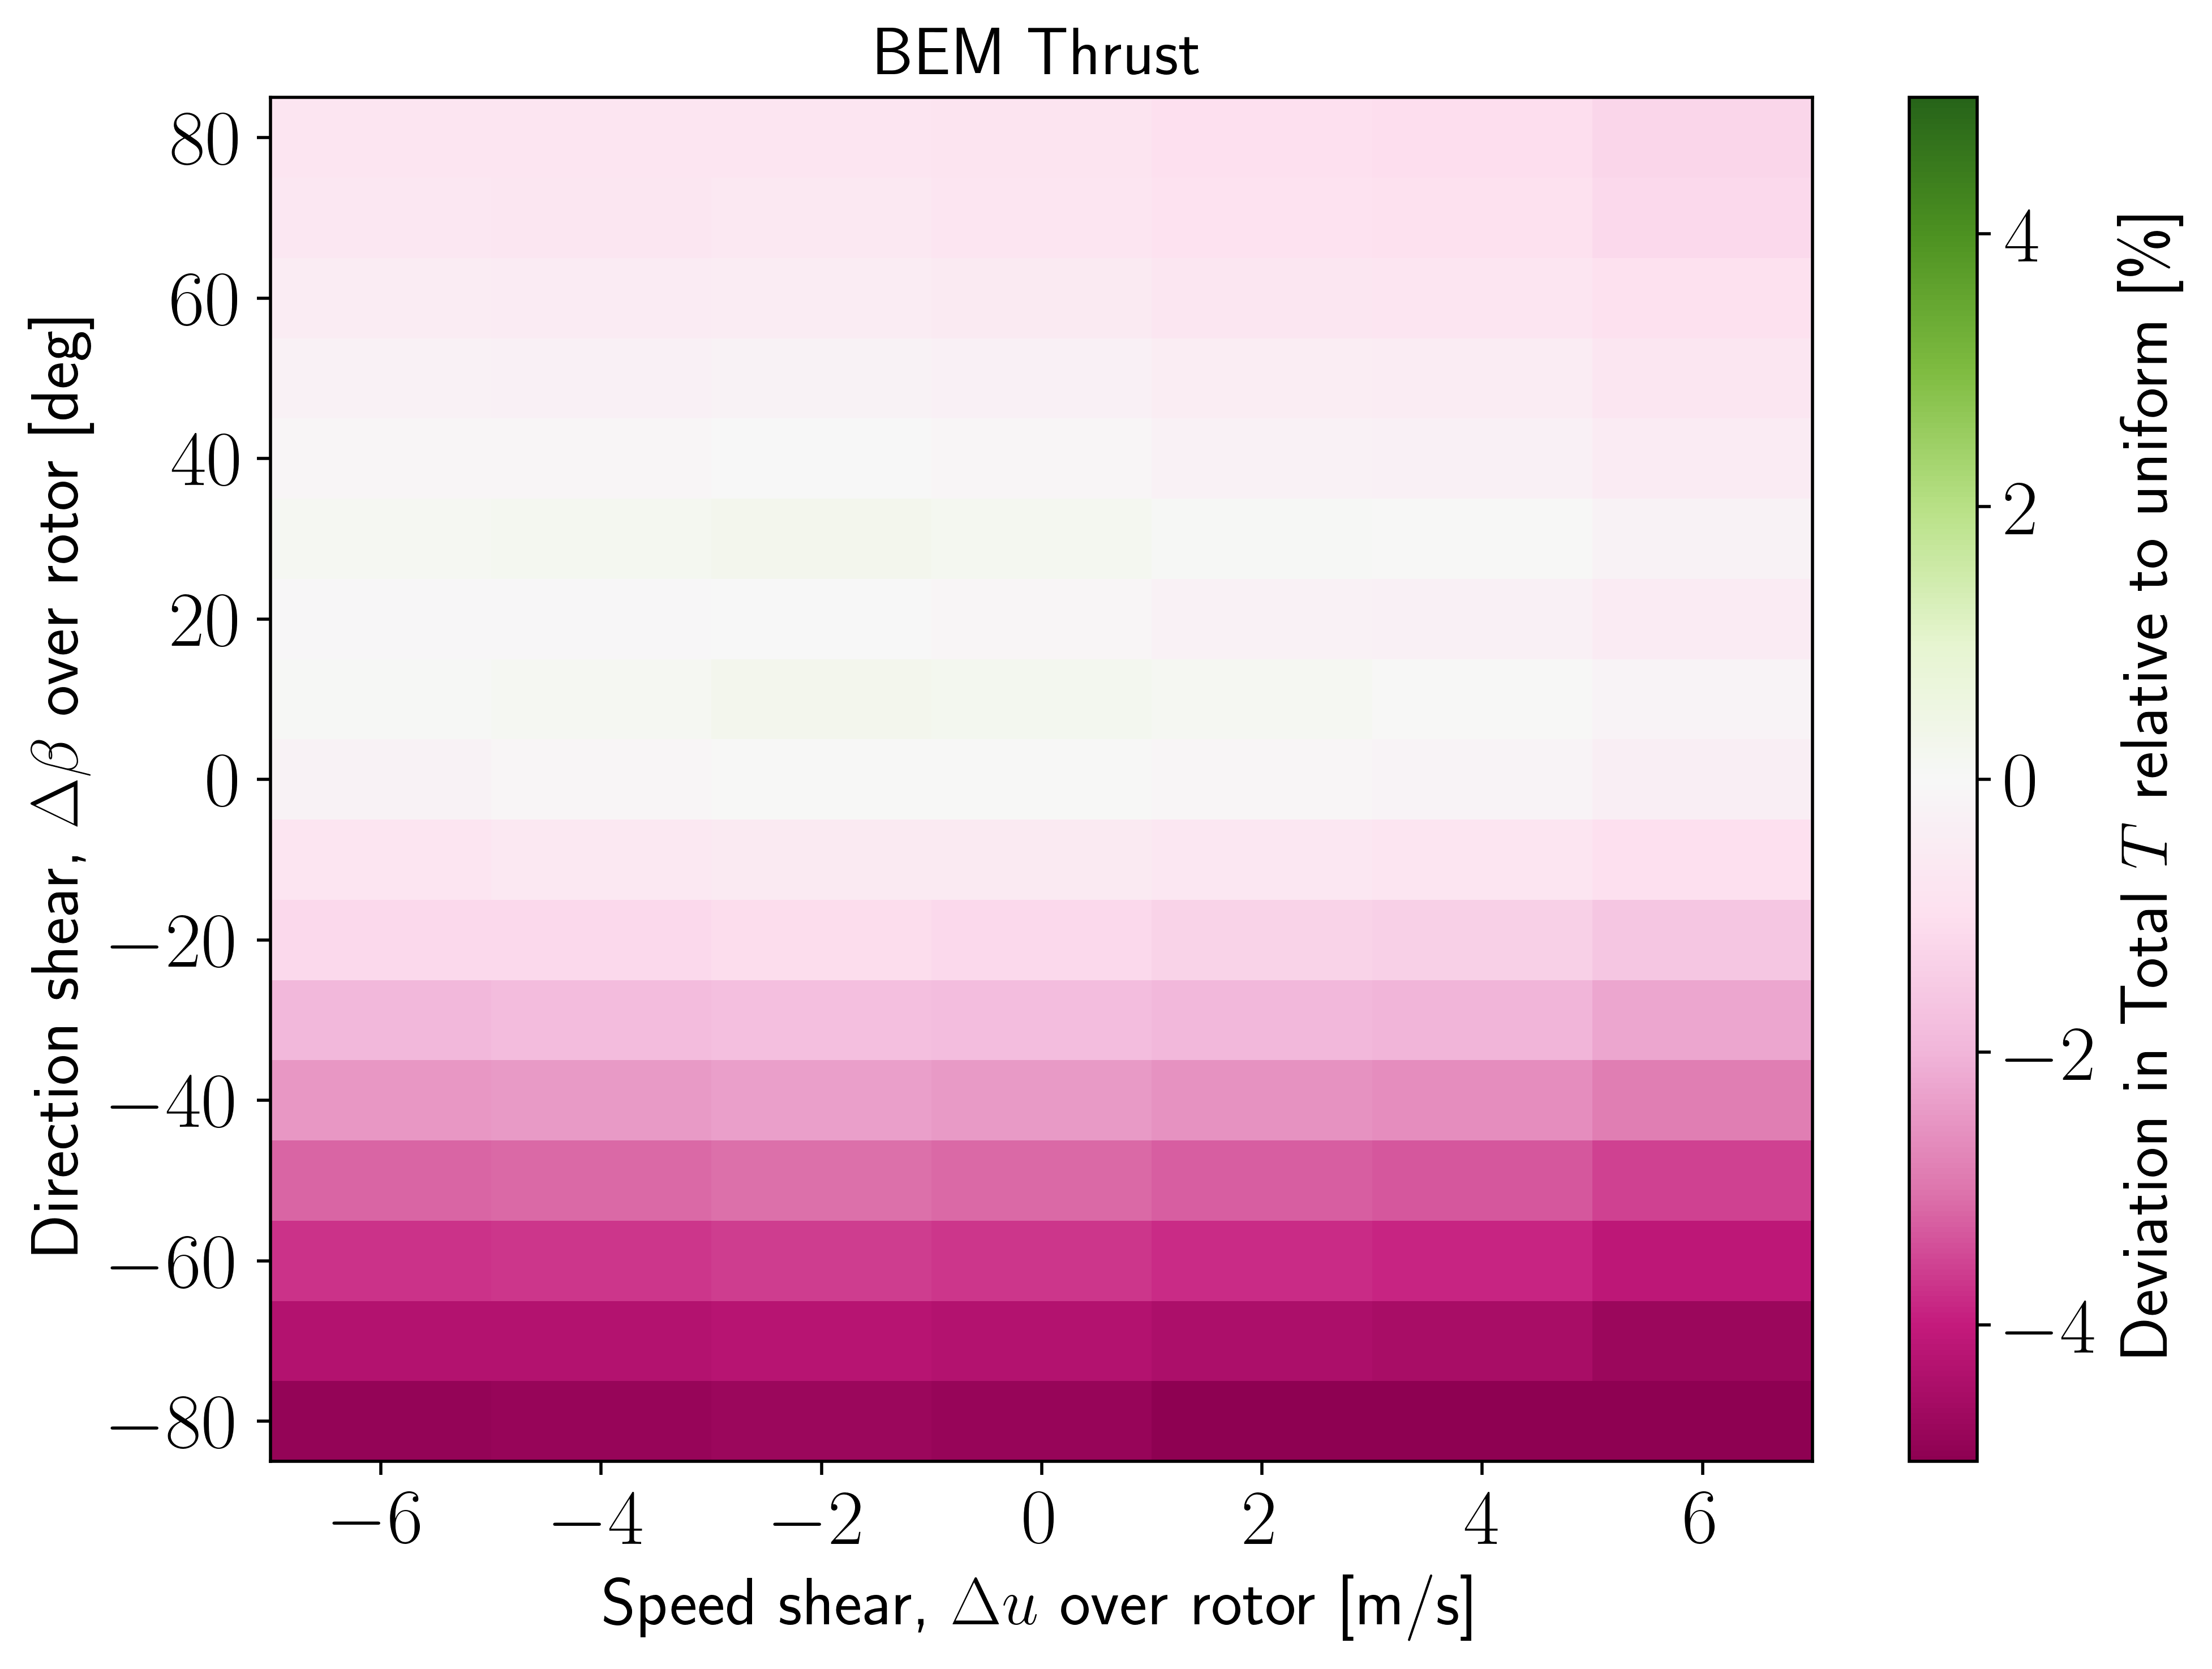

In [69]:
Z = np.zeros((len(veer),len(shear)))

for count in range(len(coords)):

    Z[coords[count][1],coords[count][0]] = mit_thrust_dev[count]


plt.figure(figsize=(8, 6))
contour = plt.pcolormesh(shear, veer[::-1], Z, cmap='PiYG',vmin=-5,vmax=5)  # or use plt.contour
cbar = plt.colorbar(contour)
cbar.set_label(r'Deviation in Total $T$ relative to uniform [\%]', fontsize=17)

plt.xticks(shear)  # every second x tick
plt.yticks(veer[::-1][::2])  # every second y tick

# Labels and formatting
plt.xlabel('Speed shear, $\Delta u$ over rotor [m/s]', fontsize=17)
plt.ylabel('Direction shear, $\Delta \\beta$ over rotor [deg]', fontsize=17)
plt.title('BEM Thrust', fontsize=17)
plt.tight_layout()
plt.show()

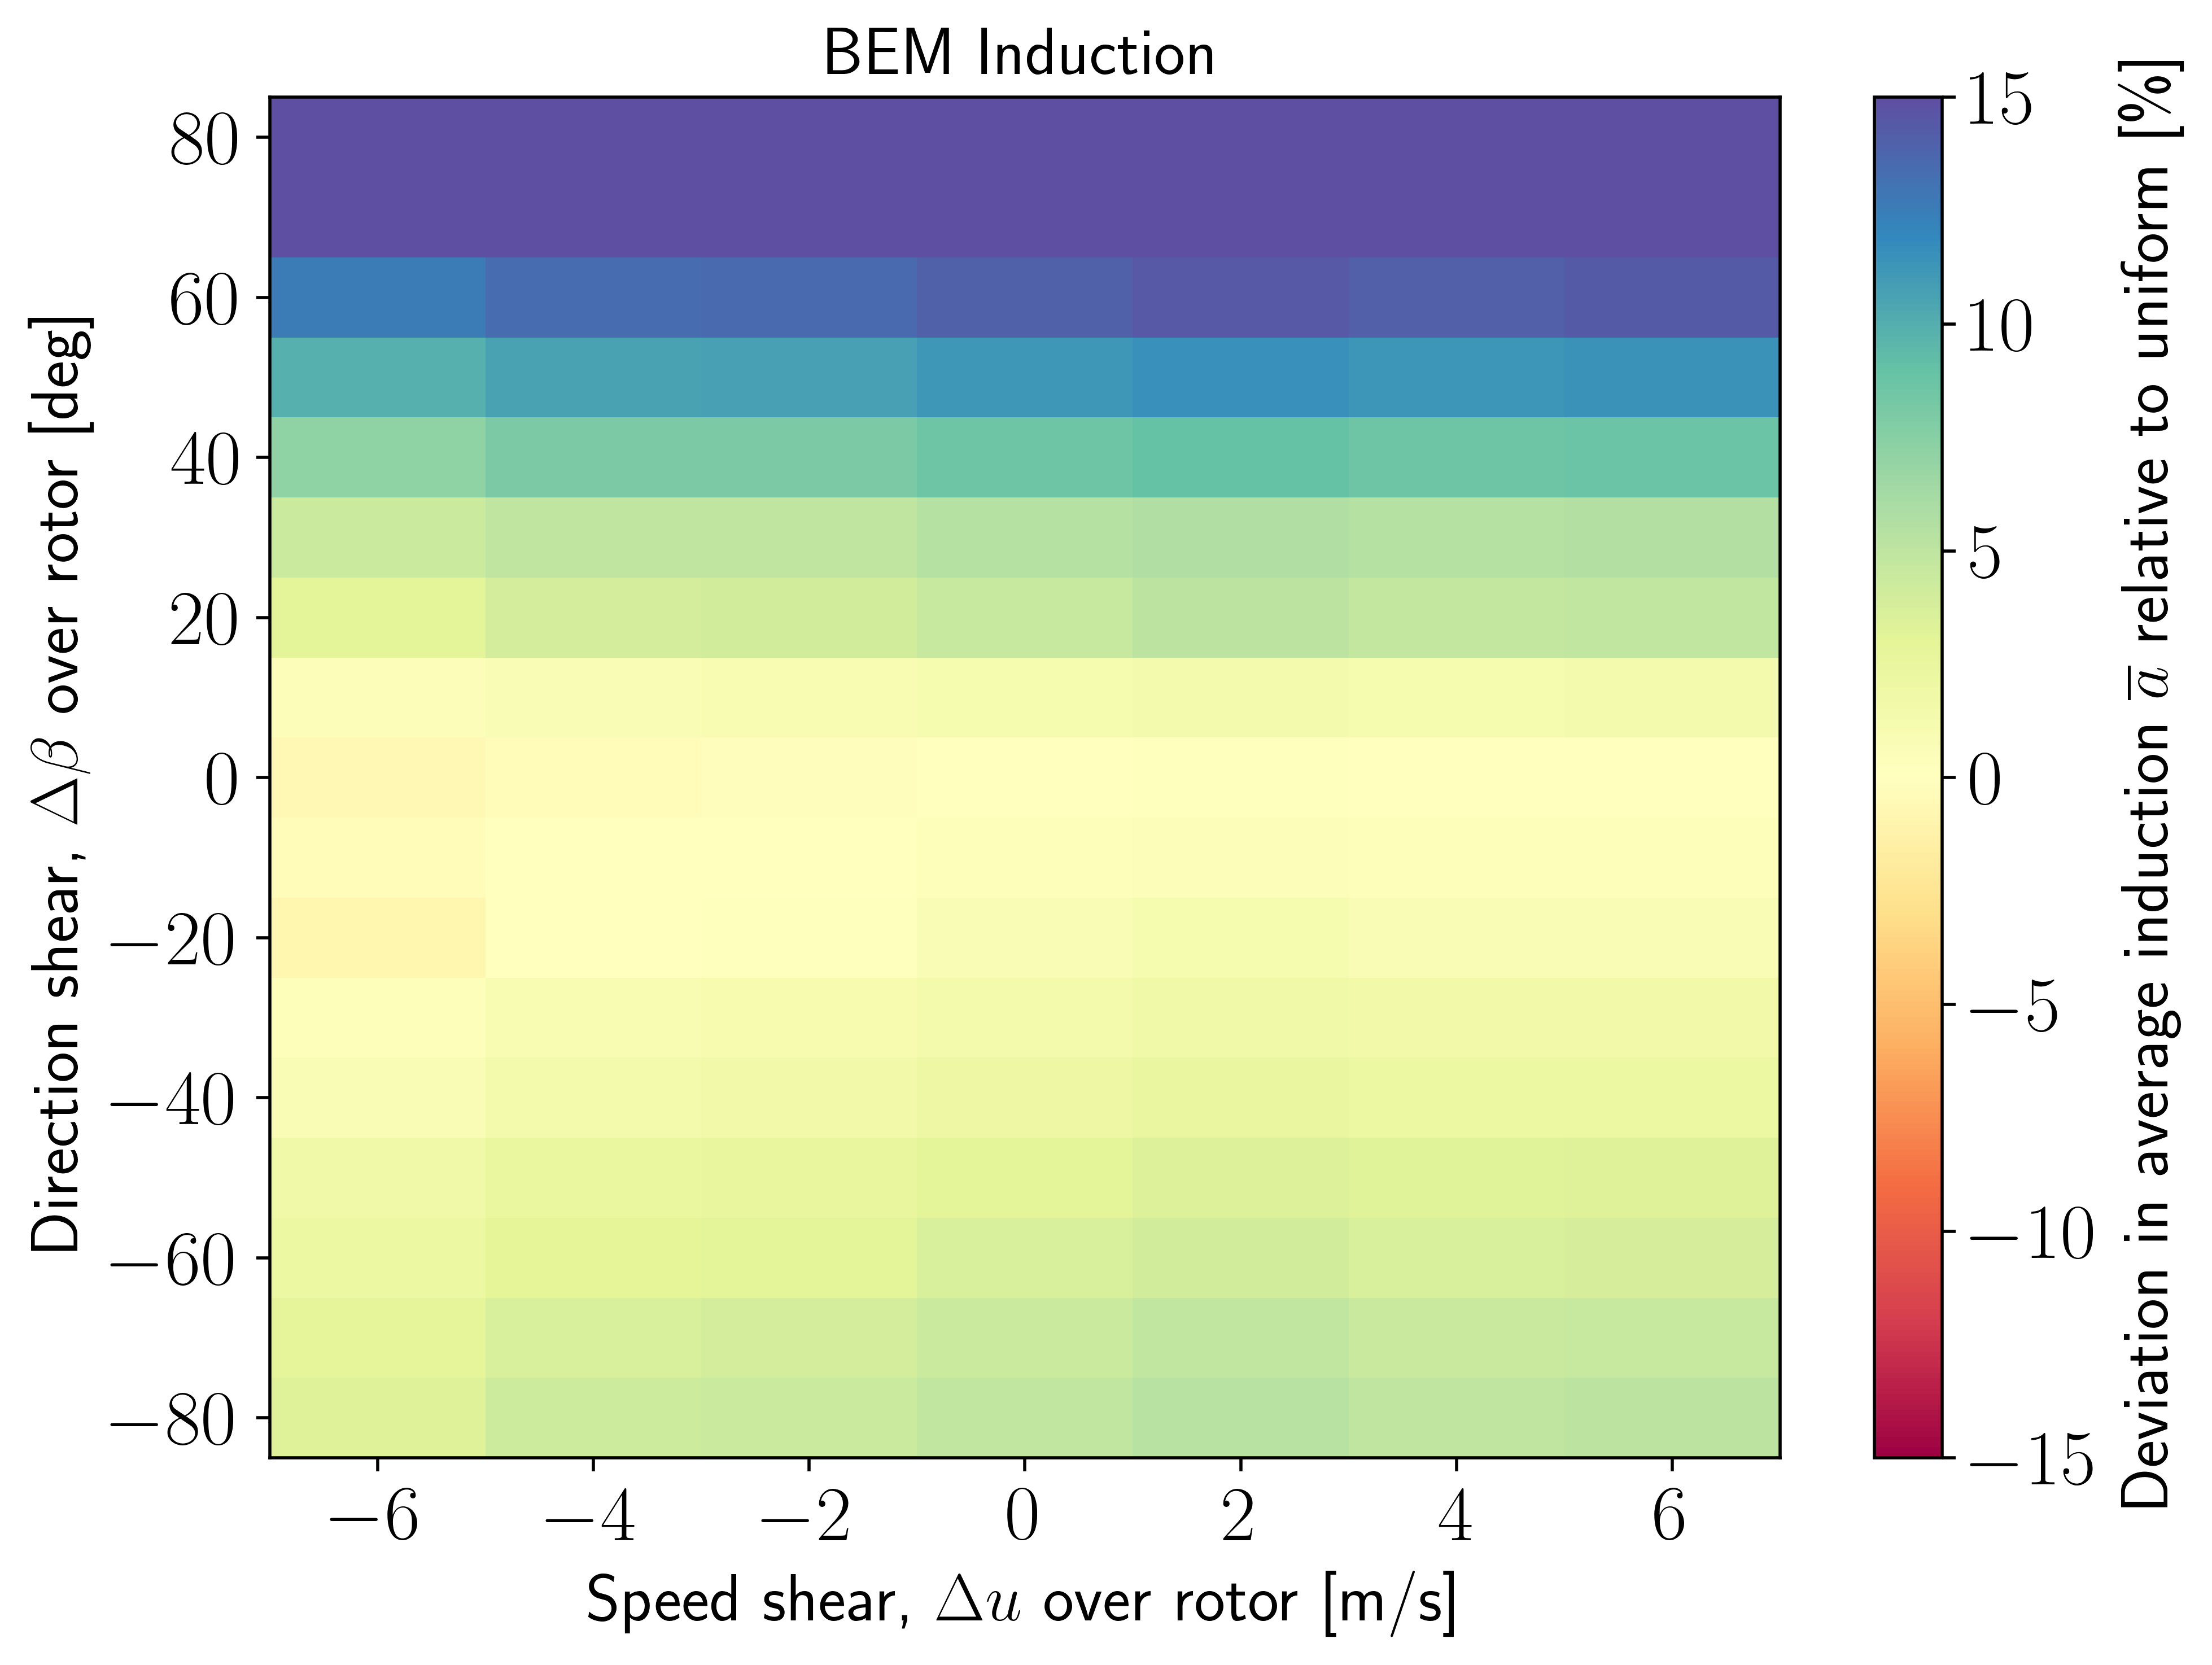

In [70]:
Z = np.zeros((len(veer),len(shear)))

for count in range(len(coords)):

    Z[coords[count][1],coords[count][0]] = mit_induction_dev[count]


plt.figure(figsize=(8, 6))
contour = plt.pcolormesh(shear, veer[::-1], Z, cmap='Spectral',vmin=-15,vmax=15)  # or use plt.contour
cbar = plt.colorbar(contour)
cbar.set_label(r'Deviation in average induction $\overline{a}$ relative to uniform [\%]', fontsize=17)


plt.xticks(shear)  # every second x tick
plt.yticks(veer[::-1][::2])  # every second y tick

# Labels and formatting
plt.xlabel('Speed shear, $\Delta u$ over rotor [m/s]', fontsize=17)
plt.ylabel('Direction shear, $\Delta \\beta$ over rotor [deg]', fontsize=17)
plt.title('BEM Induction', fontsize=17)
plt.tight_layout()
plt.show()

Text(0.5, 0, '$a$ [-]')

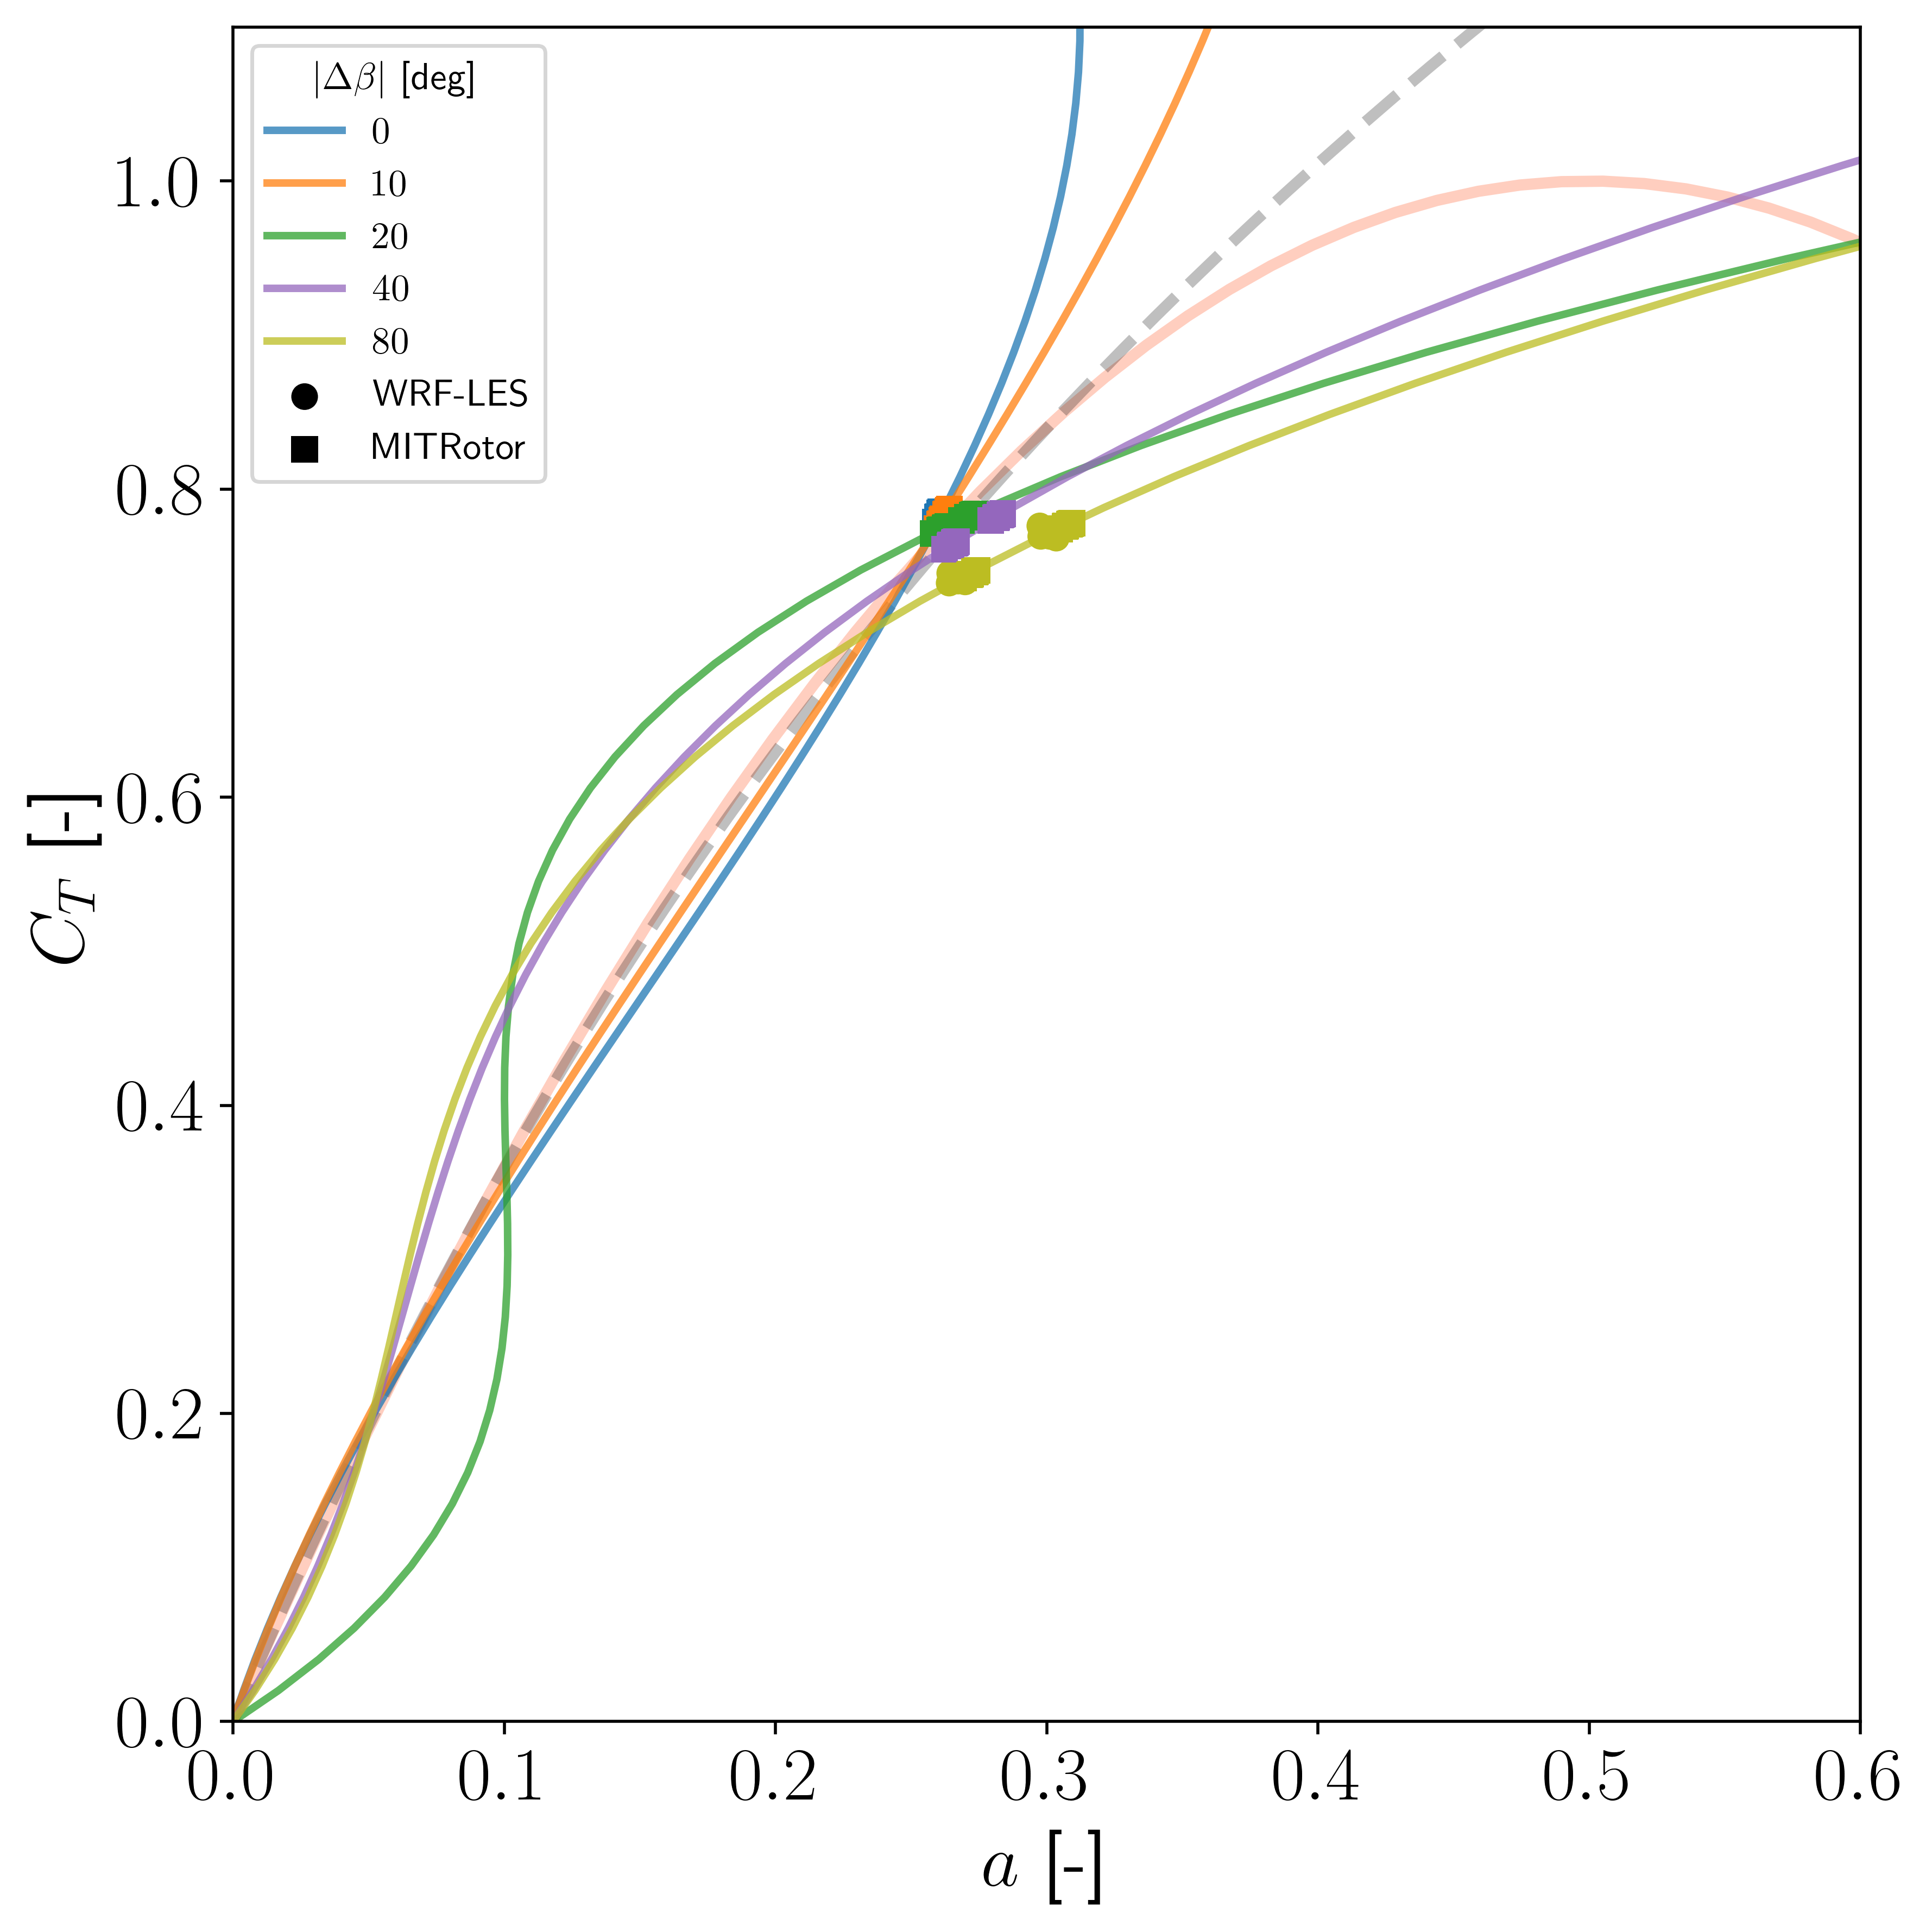

In [38]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$0$')
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$10$')
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$20$')
ax.plot(y_fit_v40, x_fit_v40, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$40$')
ax.plot(y_fit_v80, x_fit_v80, color=colors[8],linewidth=2,zorder=2,alpha=0.75,label='$80$')


for i in range(len(indices_00)):
    # mesh = ax.scatter(wrf_ind[indices_00[i]], wrf_cot[indices_00[i]], s=50, edgecolor='none',color=colors[0],zorder=3)
    mesh = ax.scatter(mit_ind[indices_00[i]], mit_cot[indices_00[i]], s=50, marker='s', edgecolor='none',color=colors[0],zorder=3)

for i in range(len(indices_10)):
    # mesh = ax.scatter(wrf_ind[indices_10[i]], wrf_cot[indices_10[i]], s=50, edgecolor='none',color=colors[1],zorder=3)
    mesh = ax.scatter(mit_ind[indices_10[i]], mit_cot[indices_10[i]], s=50, marker='s', edgecolor='none',color=colors[1],zorder=3)

for i in range(len(indices_20)):
    # mesh = ax.scatter(wrf_ind[indices_20[i]], wrf_cot[indices_20[i]], s=50, edgecolor='none',color=colors[2],zorder=3)
    mesh = ax.scatter(mit_ind[indices_20[i]], mit_cot[indices_20[i]], s=50, marker='s', edgecolor='none',color=colors[2],zorder=3)

for i in range(len(indices_40)):
    # mesh = ax.scatter(wrf_ind[indices_40[i]], wrf_cot[indices_40[i]], s=50, edgecolor='none',color=colors[4],zorder=3)
    mesh = ax.scatter(mit_ind[indices_40[i]], mit_cot[indices_40[i]], s=50, marker='s', edgecolor='none',color=colors[4],zorder=3)

for i in range(len(indices_80)):
    mesh = ax.scatter(wrf_ind[indices_80[i]], wrf_cot[indices_80[i]], s=50, edgecolor='none',color=colors[8],zorder=3)
    mesh = ax.scatter(mit_ind[indices_80[i]], mit_cot[indices_80[i]], s=50, marker='s', edgecolor='none',color=colors[8],zorder=3)
    # print(veers[indices_80[i]])

for i in range(len(indices_00)):
    # mesh = ax.scatter(wrf_ind[indices_00[i]], wrf_cot[indices_00[i]], s=50, edgecolor='none',color=colors[0],zorder=3)
    mesh = ax.scatter(mit_ind[indices_00[i]], mit_cot[indices_00[i]], s=50, marker='s', edgecolor='none',color=colors[0],zorder=3)

for i in range(len(indices_10)):
    # mesh = ax.scatter(wrf_ind[indices_10[i]], wrf_cot[indices_10[i]], s=50, edgecolor='none',color=colors[1],zorder=3)
    mesh = ax.scatter(mit_ind[indices_10[i]], mit_cot[indices_10[i]], s=50, marker='s', edgecolor='none',color=colors[1],zorder=3)

for i in range(len(indices_20)):
    # mesh = ax.scatter(wrf_ind[indices_20[i]], wrf_cot[indices_20[i]], s=50, edgecolor='none',color=colors[2],zorder=3)
    mesh = ax.scatter(mit_ind[indices_20[i]], mit_cot[indices_20[i]], s=50, marker='s', edgecolor='none',color=colors[2],zorder=3)

for i in range(len(indices_40)):
    # mesh = ax.scatter(wrf_ind[indices_40[i]], wrf_cot[indices_40[i]], s=50, edgecolor='none',color=colors[4],zorder=3)
    mesh = ax.scatter(mit_ind[indices_40[i]], mit_cot[indices_40[i]], s=50, marker='s', edgecolor='none',color=colors[4],zorder=3)

for i in range(len(indices_80)):
    # mesh = ax.scatter(wrf_ind[indices_80[i]], wrf_cot[indices_80[i]], s=50, edgecolor='none',color=colors[8],zorder=3)
    mesh = ax.scatter(mit_ind[indices_80[i]], mit_cot[indices_80[i]], s=50, marker='s', edgecolor='none',color=colors[8],zorder=3)

mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',zorder=3,label='WRF-LES')
mesh = ax.scatter(-5, -5, s=50, marker='s', edgecolor='none',color='k',zorder=3,label='MITRotor')

ax.legend(title='$|\Delta \\beta|$ [deg]')

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.1])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

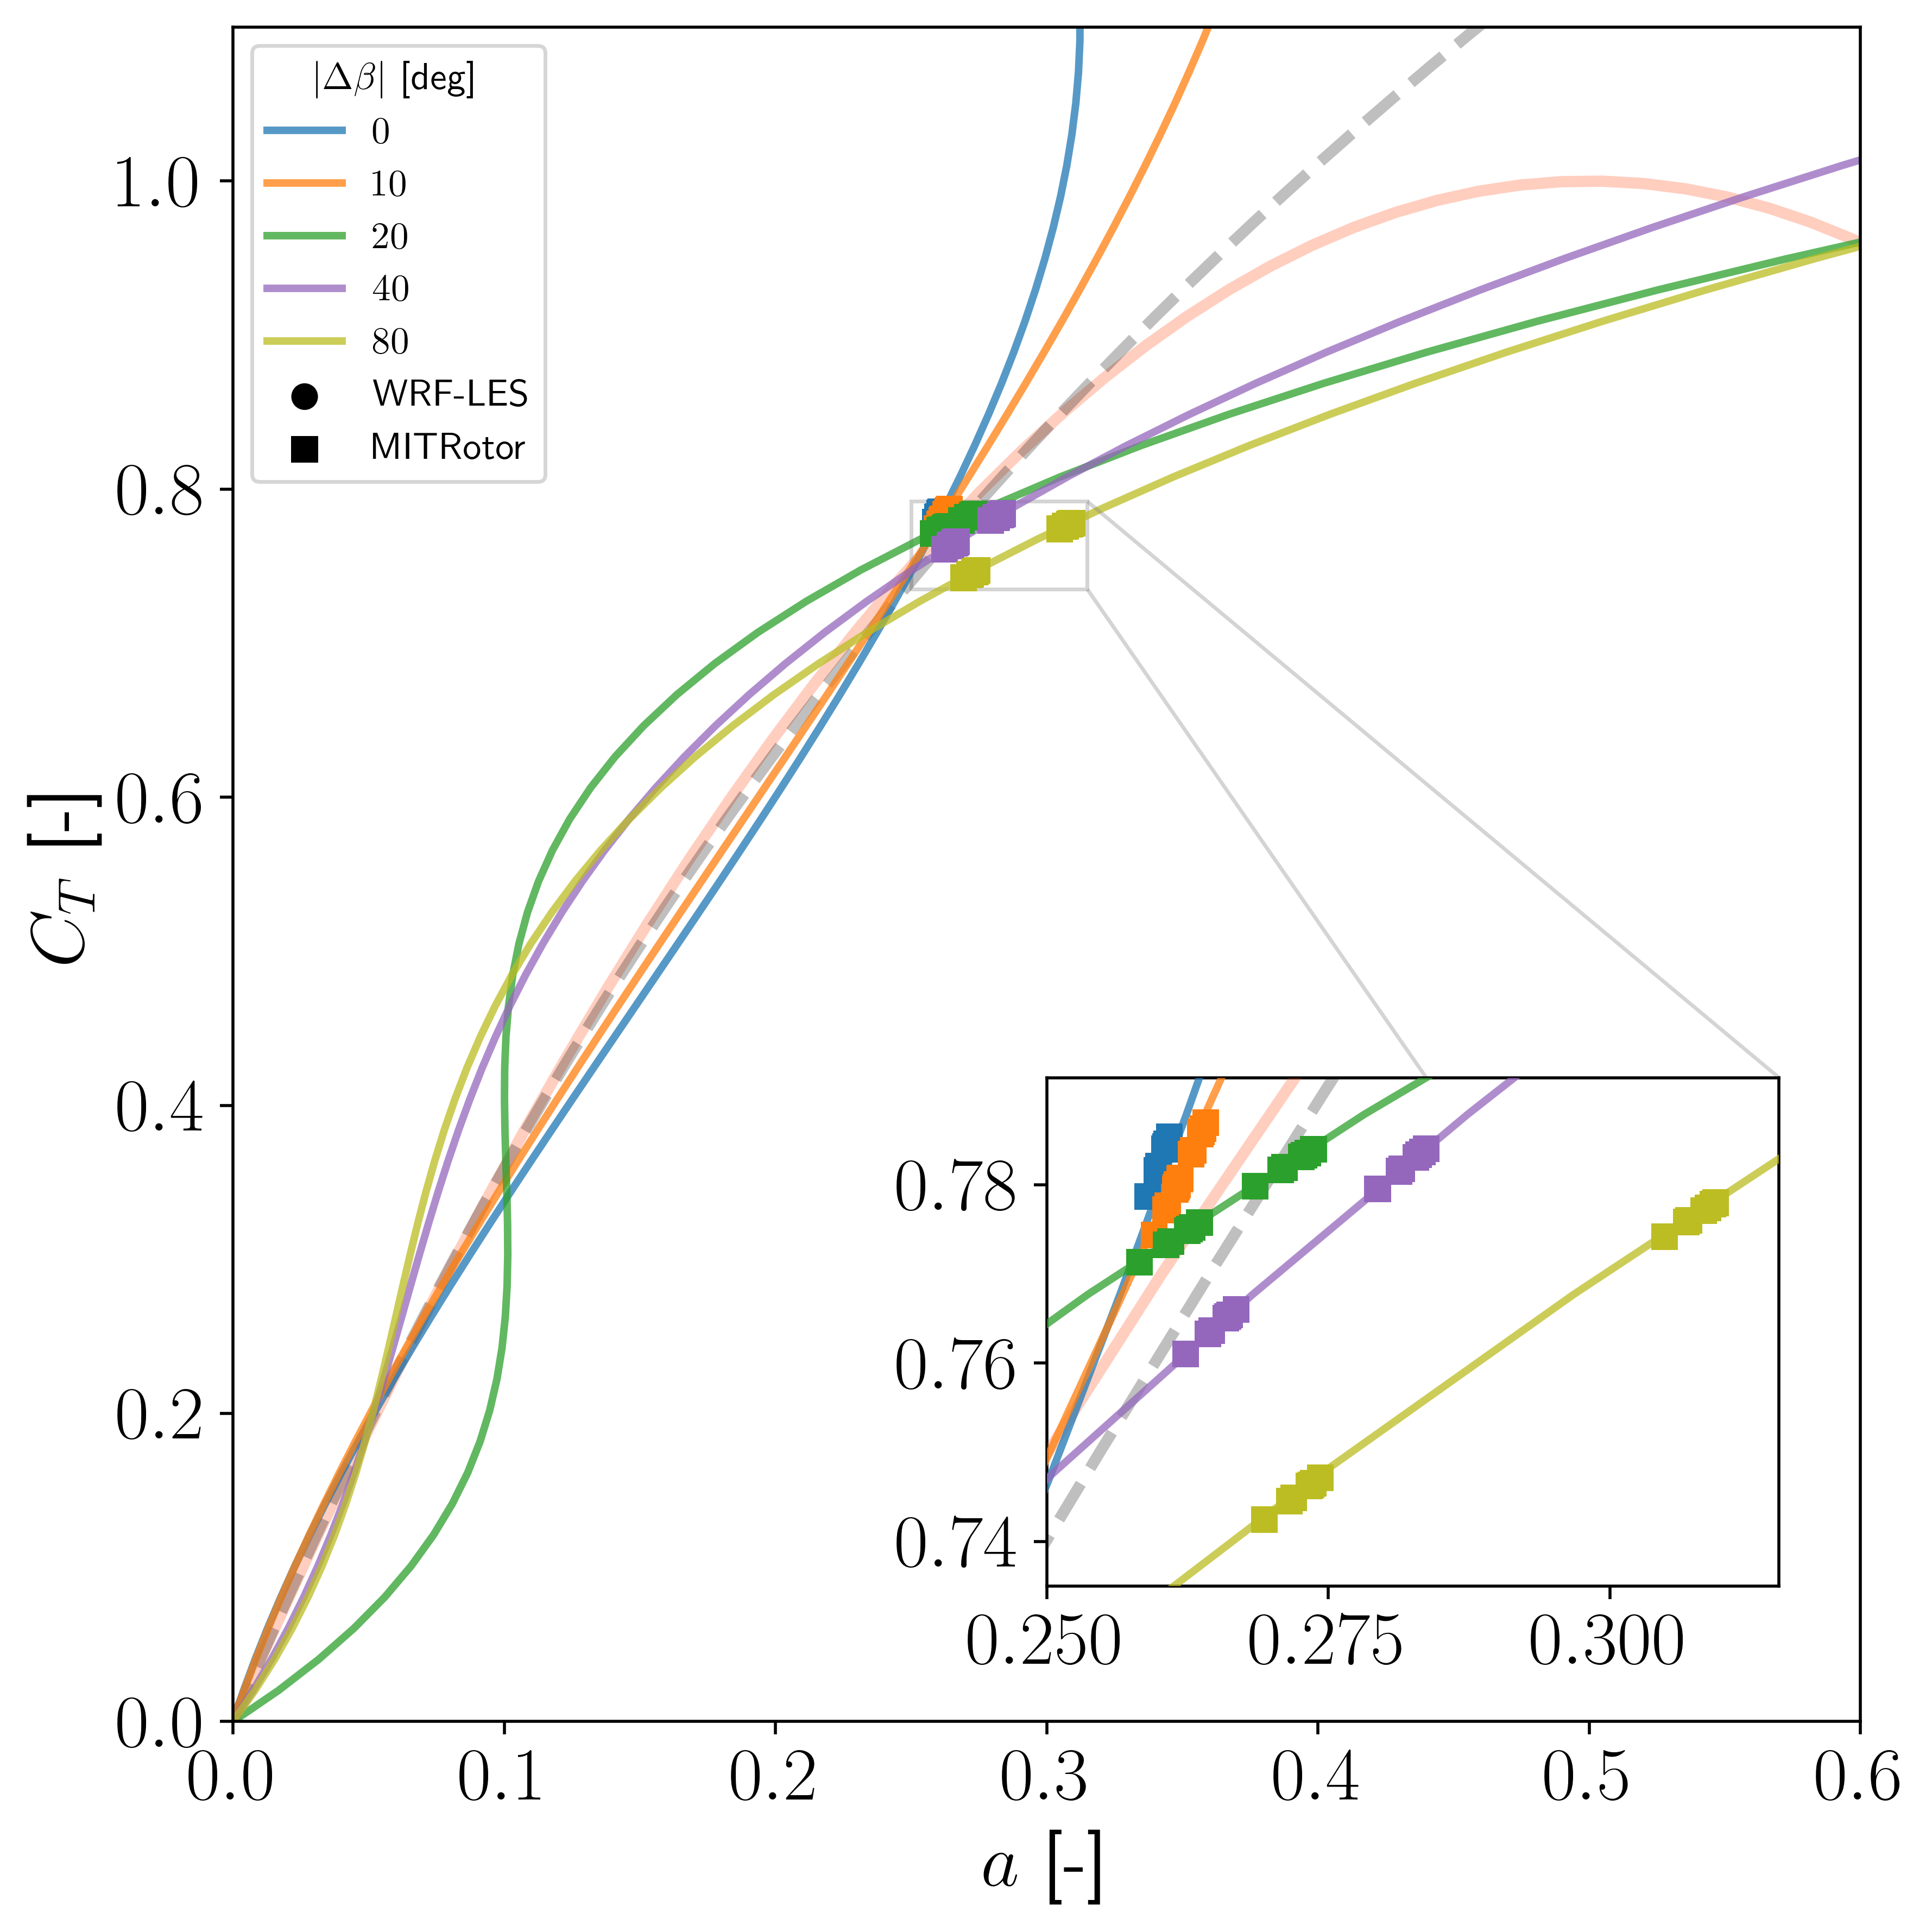

In [36]:
# Create the main figure and axis
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)

a_mom  = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1,alpha=0.25)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2,alpha=0.25)

ax.plot(y_fit_v00, x_fit_v00, color=colors[0],linewidth=2,zorder=2,alpha=0.75,label='$0$')
ax.plot(y_fit_v10, x_fit_v10, color=colors[1],linewidth=2,zorder=2,alpha=0.75,label='$10$')
ax.plot(y_fit_v20, x_fit_v20, color=colors[2],linewidth=2,zorder=2,alpha=0.75,label='$20$')
ax.plot(y_fit_v40, x_fit_v40, color=colors[4],linewidth=2,zorder=2,alpha=0.75,label='$40$')
ax.plot(y_fit_v80, x_fit_v80, color=colors[8],linewidth=2,zorder=2,alpha=0.75,label='$80$')

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.1])

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)

mesh = ax.scatter(-5, -5, s=50, edgecolor='none',color='k',zorder=3,label='WRF-LES')
mesh = ax.scatter(-5, -5, s=50, marker='s', edgecolor='none',color='k',zorder=3,label='MITRotor')

ax.legend(title='$|\Delta \\beta|$ [deg]')

# === Add inset axes ===
# Example: Zoom into a cluster near a=0.32, CT=0.7

inset_ax = ax.inset_axes(
   [0.5, 0.08, 0.45, 0.3],  # [x, y, width, height] w.r.t. axes
    xlim=[0.25, 0.315], ylim=[0.735, 0.792] # sets viewport & tells relation to main axes
    # xticklabels=[], yticklabels=[]
)

# # Plot the same data inside the inset
inset_ax.plot(a_mom, ct_mom, '#ff3c00', linewidth=3, alpha=0.25,zorder=3)
inset_ax.plot(a_mad, ct_mad, 'k--', linewidth=3, alpha=0.25,zorder=3)

# # Re-plot the fitted curves
inset_ax.plot(y_fit_v00, x_fit_v00, color=colors[0], linewidth=2, alpha=0.75,zorder=3)
inset_ax.plot(y_fit_v10, x_fit_v10, color=colors[1], linewidth=2, alpha=0.75,zorder=3)
inset_ax.plot(y_fit_v20, x_fit_v20, color=colors[2], linewidth=2, alpha=0.75,zorder=3)
inset_ax.plot(y_fit_v40, x_fit_v40, color=colors[4], linewidth=2, alpha=0.75,zorder=3)
inset_ax.plot(y_fit_v80, x_fit_v80, color=colors[8], linewidth=2, alpha=0.75,zorder=3)

import matplotlib.patches as patches

rect = patches.Rectangle((0.2, 0.6), 0.2, 0.2, facecolor='white', edgecolor='k',zorder=2)
inset_ax.add_patch(rect)

for i in range(len(indices_00)):
    # mesh = ax.scatter(wrf_ind[indices_00[i]], wrf_cot[indices_00[i]], s=50, edgecolor='none',color=colors[0],zorder=3)
    mesh = ax.scatter(mit_ind[indices_00[i]], mit_cot[indices_00[i]], s=50, marker='s', edgecolor='none',color=colors[0],zorder=3)
    inset_ax.scatter(mit_ind[indices_00[i]], mit_cot[indices_00[i]], s=50, marker='s', edgecolor='none',color=colors[0],zorder=3)

for i in range(len(indices_10)):
    # mesh = ax.scatter(wrf_ind[indices_10[i]], wrf_cot[indices_10[i]], s=50, edgecolor='none',color=colors[1],zorder=3)
    mesh = ax.scatter(mit_ind[indices_10[i]], mit_cot[indices_10[i]], s=50, marker='s', edgecolor='none',color=colors[1],zorder=3)
    inset_ax.scatter(mit_ind[indices_10[i]], mit_cot[indices_10[i]], s=50, marker='s', edgecolor='none',color=colors[1],zorder=3)

for i in range(len(indices_20)):
    # mesh = ax.scatter(wrf_ind[indices_20[i]], wrf_cot[indices_20[i]], s=50, edgecolor='none',color=colors[2],zorder=3)
    mesh = ax.scatter(mit_ind[indices_20[i]], mit_cot[indices_20[i]], s=50, marker='s', edgecolor='none',color=colors[2],zorder=3)
    inset_ax.scatter(mit_ind[indices_20[i]], mit_cot[indices_20[i]], s=50, marker='s', edgecolor='none',color=colors[2],zorder=3)

for i in range(len(indices_40)):
    # mesh = ax.scatter(wrf_ind[indices_40[i]], wrf_cot[indices_40[i]], s=50, edgecolor='none',color=colors[4],zorder=3)
    mesh = ax.scatter(mit_ind[indices_40[i]], mit_cot[indices_40[i]], s=50, marker='s', edgecolor='none',color=colors[4],zorder=3)
    inset_ax.scatter(mit_ind[indices_40[i]], mit_cot[indices_40[i]], s=50, marker='s', edgecolor='none',color=colors[4],zorder=3)

for i in range(len(indices_80)):
    # mesh = ax.scatter(wrf_ind[indices_80[i]], wrf_cot[indices_80[i]], s=50, edgecolor='none',color=colors[8],zorder=3)
    mesh = ax.scatter(mit_ind[indices_80[i]], mit_cot[indices_80[i]], s=50, marker='s', edgecolor='none',color=colors[8],zorder=3)
    inset_ax.scatter(mit_ind[indices_80[i]], mit_cot[indices_80[i]], s=50, marker='s', edgecolor='none',color=colors[8],zorder=3)

# Add a rectangle on the main plot showing the zoomed region
mark_inset(ax, inset_ax, loc1=1, loc2=4, fc="none", ec="0.5",zorder=1,alpha=1/3)

plt.show()

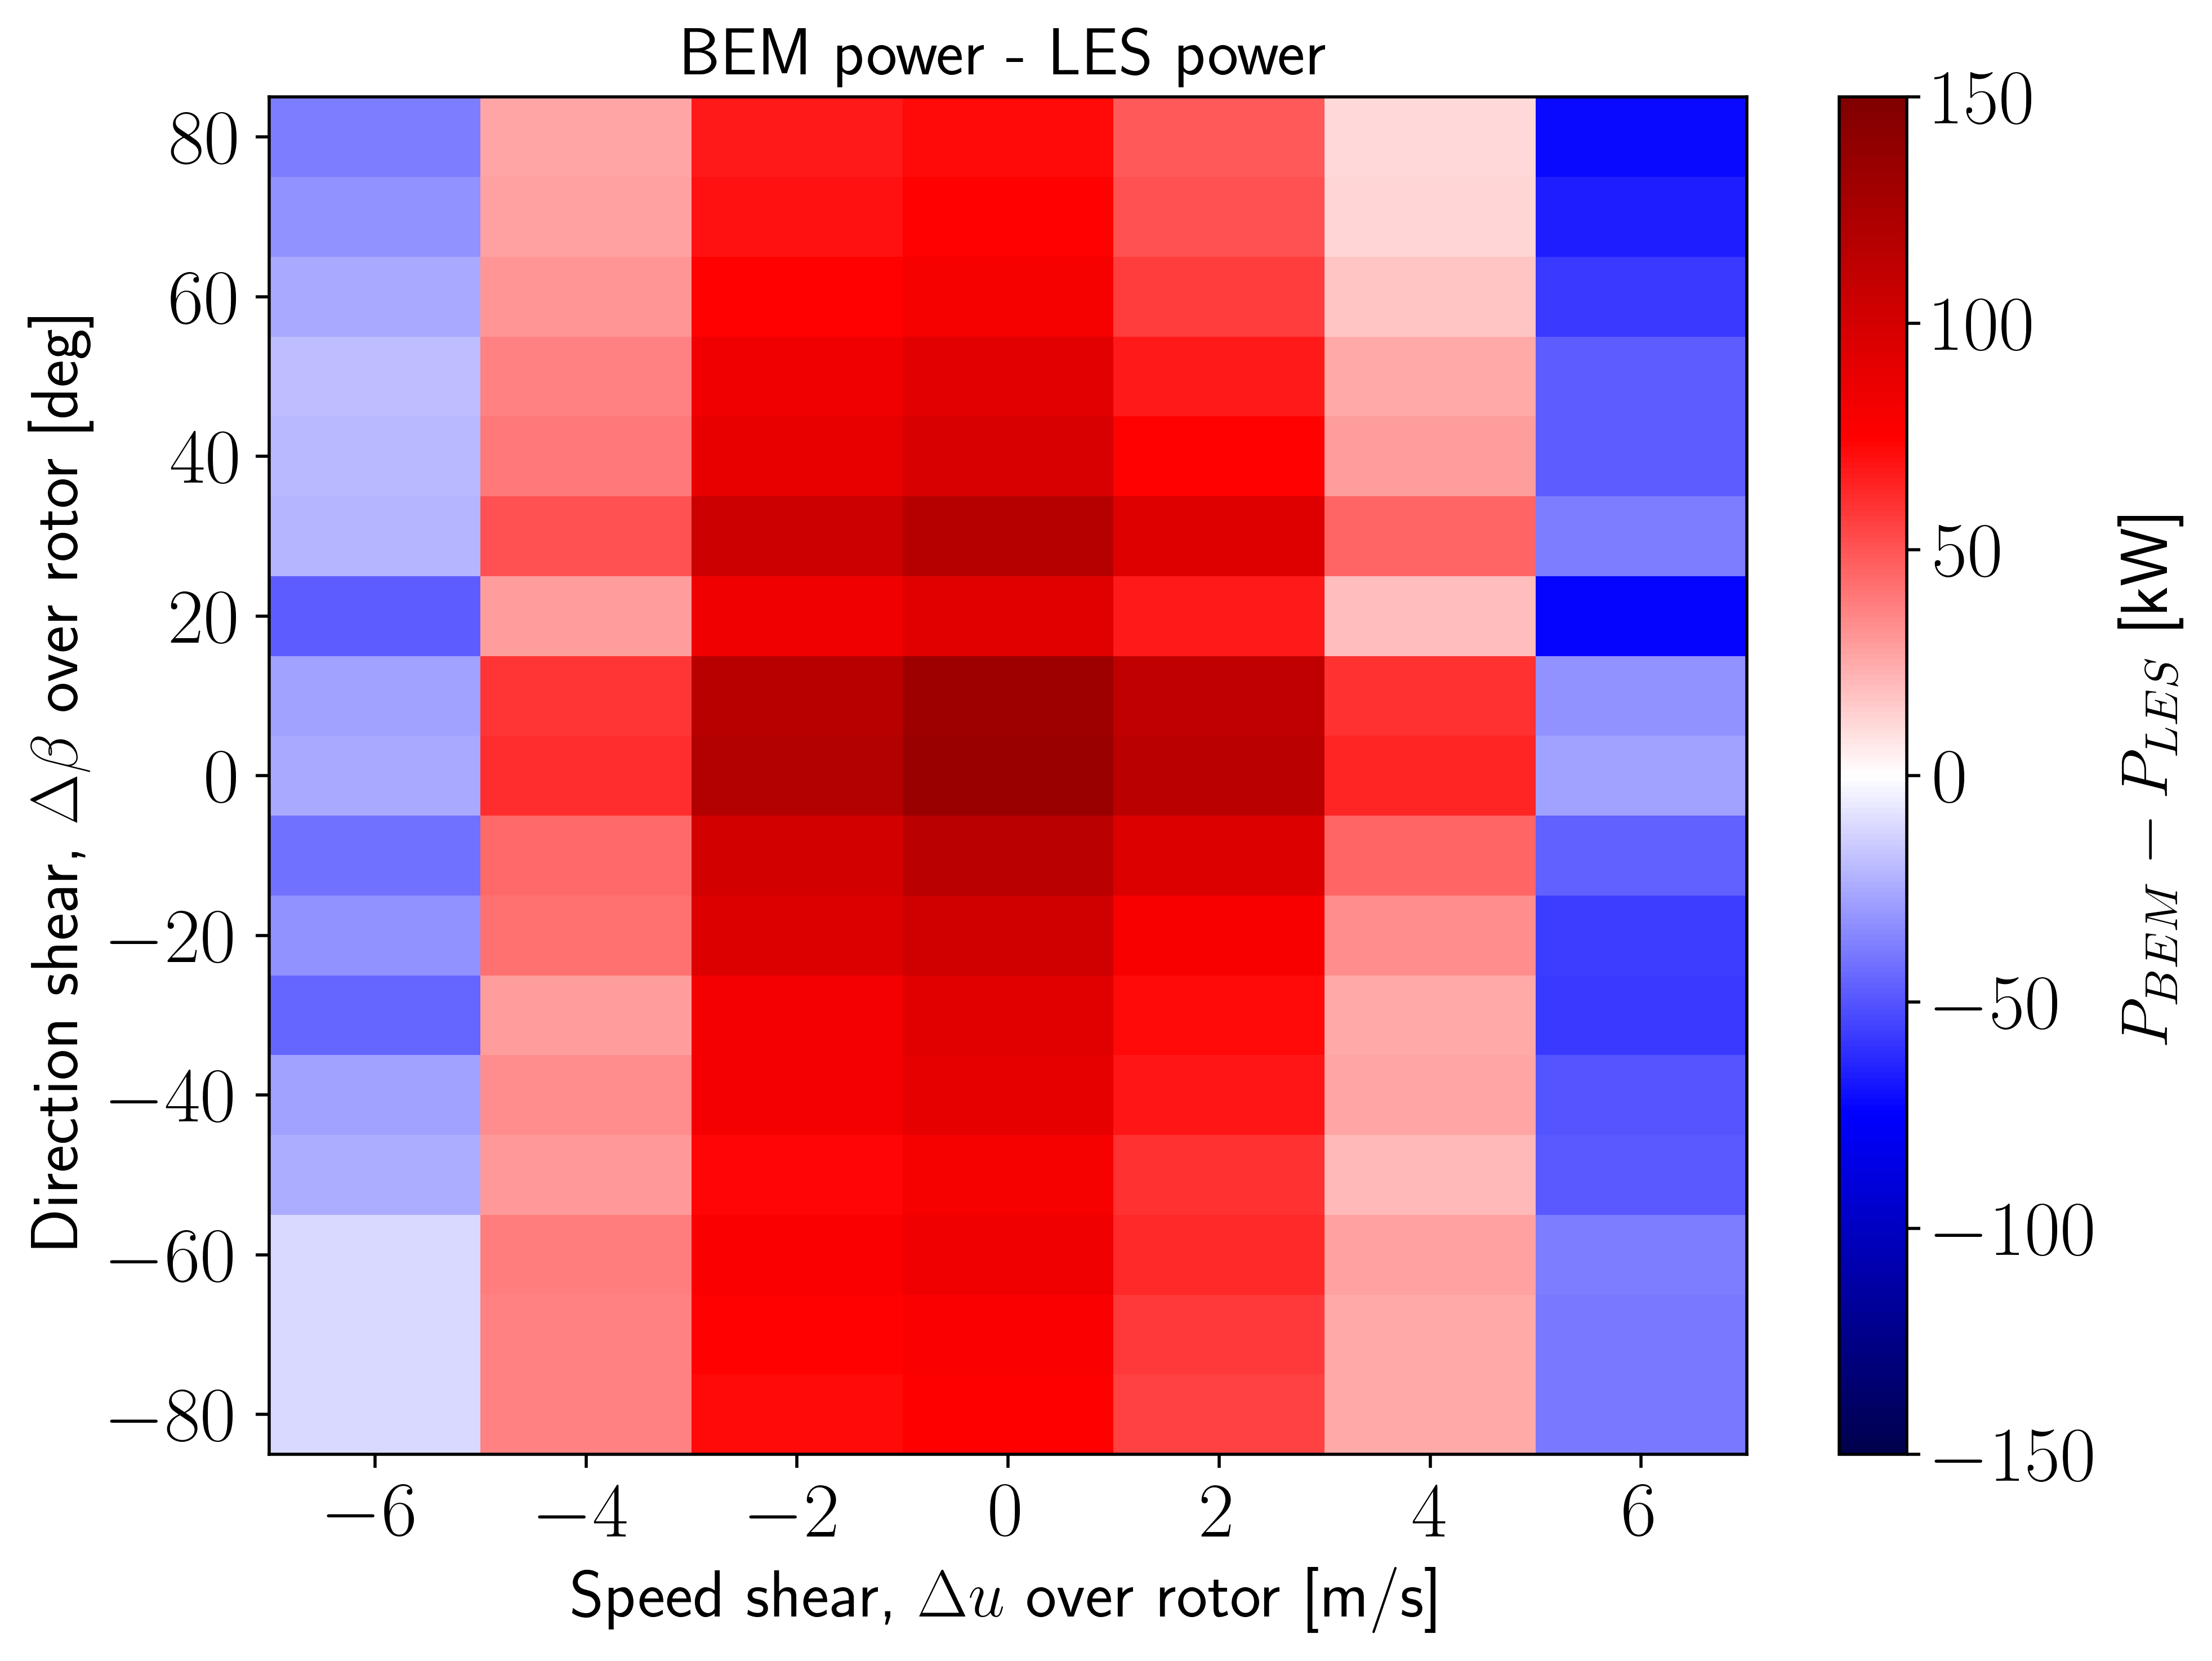

In [58]:
Z = np.zeros((len(veer),len(shear)))

for count in range(len(coords)):

    Z[coords[count][1],coords[count][0]] = (mit_pow[count] - wrf_pow[count]/1e6)*1e3

plt.figure(figsize=(8, 6))
contour = plt.pcolormesh(shear, veer[::-1], Z, cmap='seismic',vmin=-150,vmax=150)  # or use plt.contour
cbar = plt.colorbar(contour)
cbar.set_label(r'$P_{BEM} - P_{LES}$ [kW]', fontsize=17)

plt.xticks(shear)  # every second x tick
plt.yticks(veer[::-1][::2])  # every second y tick

# Labels and formatting
plt.xlabel('Speed shear, $\Delta u$ over rotor [m/s]', fontsize=17)
plt.ylabel('Direction shear, $\Delta \\beta$ over rotor [deg]', fontsize=17)
plt.title('BEM power - LES power', fontsize=17)
plt.tight_layout()
plt.show()

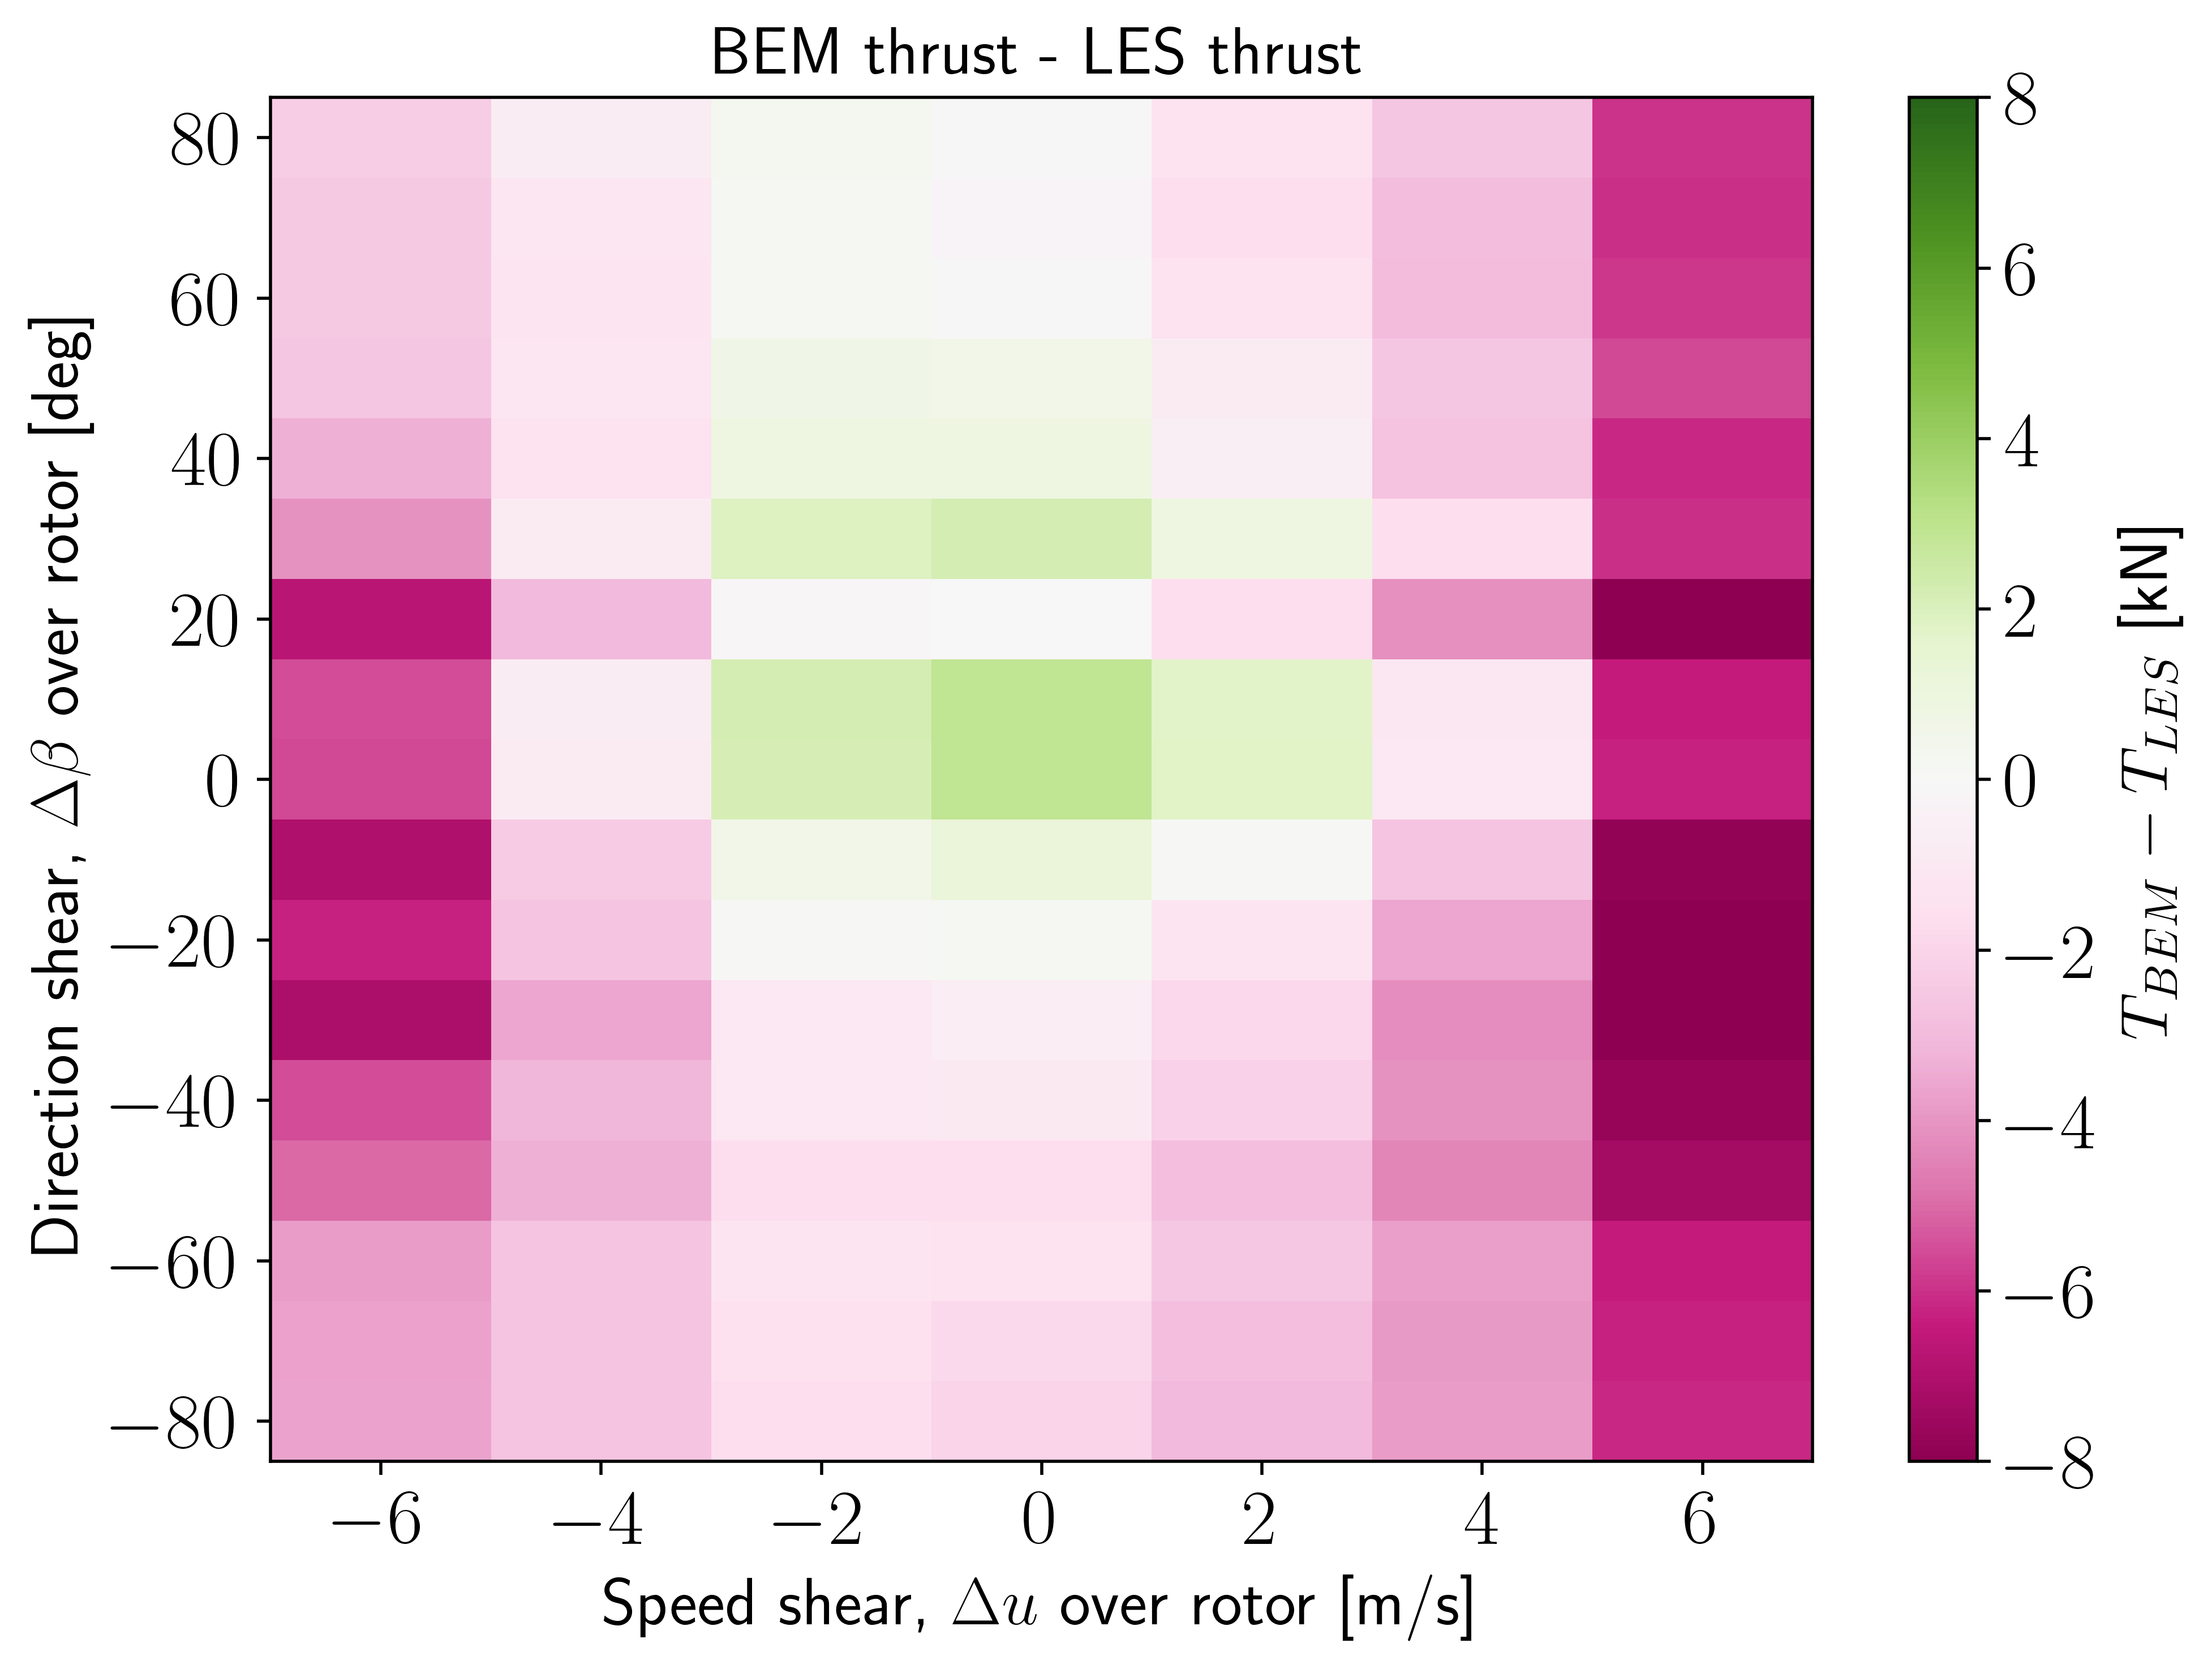

In [60]:
Z = np.zeros((len(veer),len(shear)))

for count in range(len(coords)):

    Z[coords[count][1],coords[count][0]] = (mit_thr[count] - wrf_thr[count]/1e3)

plt.figure(figsize=(8, 6))
contour = plt.pcolormesh(shear, veer[::-1], Z, cmap='PiYG',vmin=-8,vmax=8)  # or use plt.contour
cbar = plt.colorbar(contour)
cbar.set_label(r'$T_{BEM} - T_{LES}$ [kN]', fontsize=17)

plt.xticks(shear)  # every second x tick
plt.yticks(veer[::-1][::2])  # every second y tick

# Labels and formatting
plt.xlabel('Speed shear, $\Delta u$ over rotor [m/s]', fontsize=17)
plt.ylabel('Direction shear, $\Delta \\beta$ over rotor [deg]', fontsize=17)
plt.title('BEM thrust - LES thrust', fontsize=17)
plt.tight_layout()
plt.show()

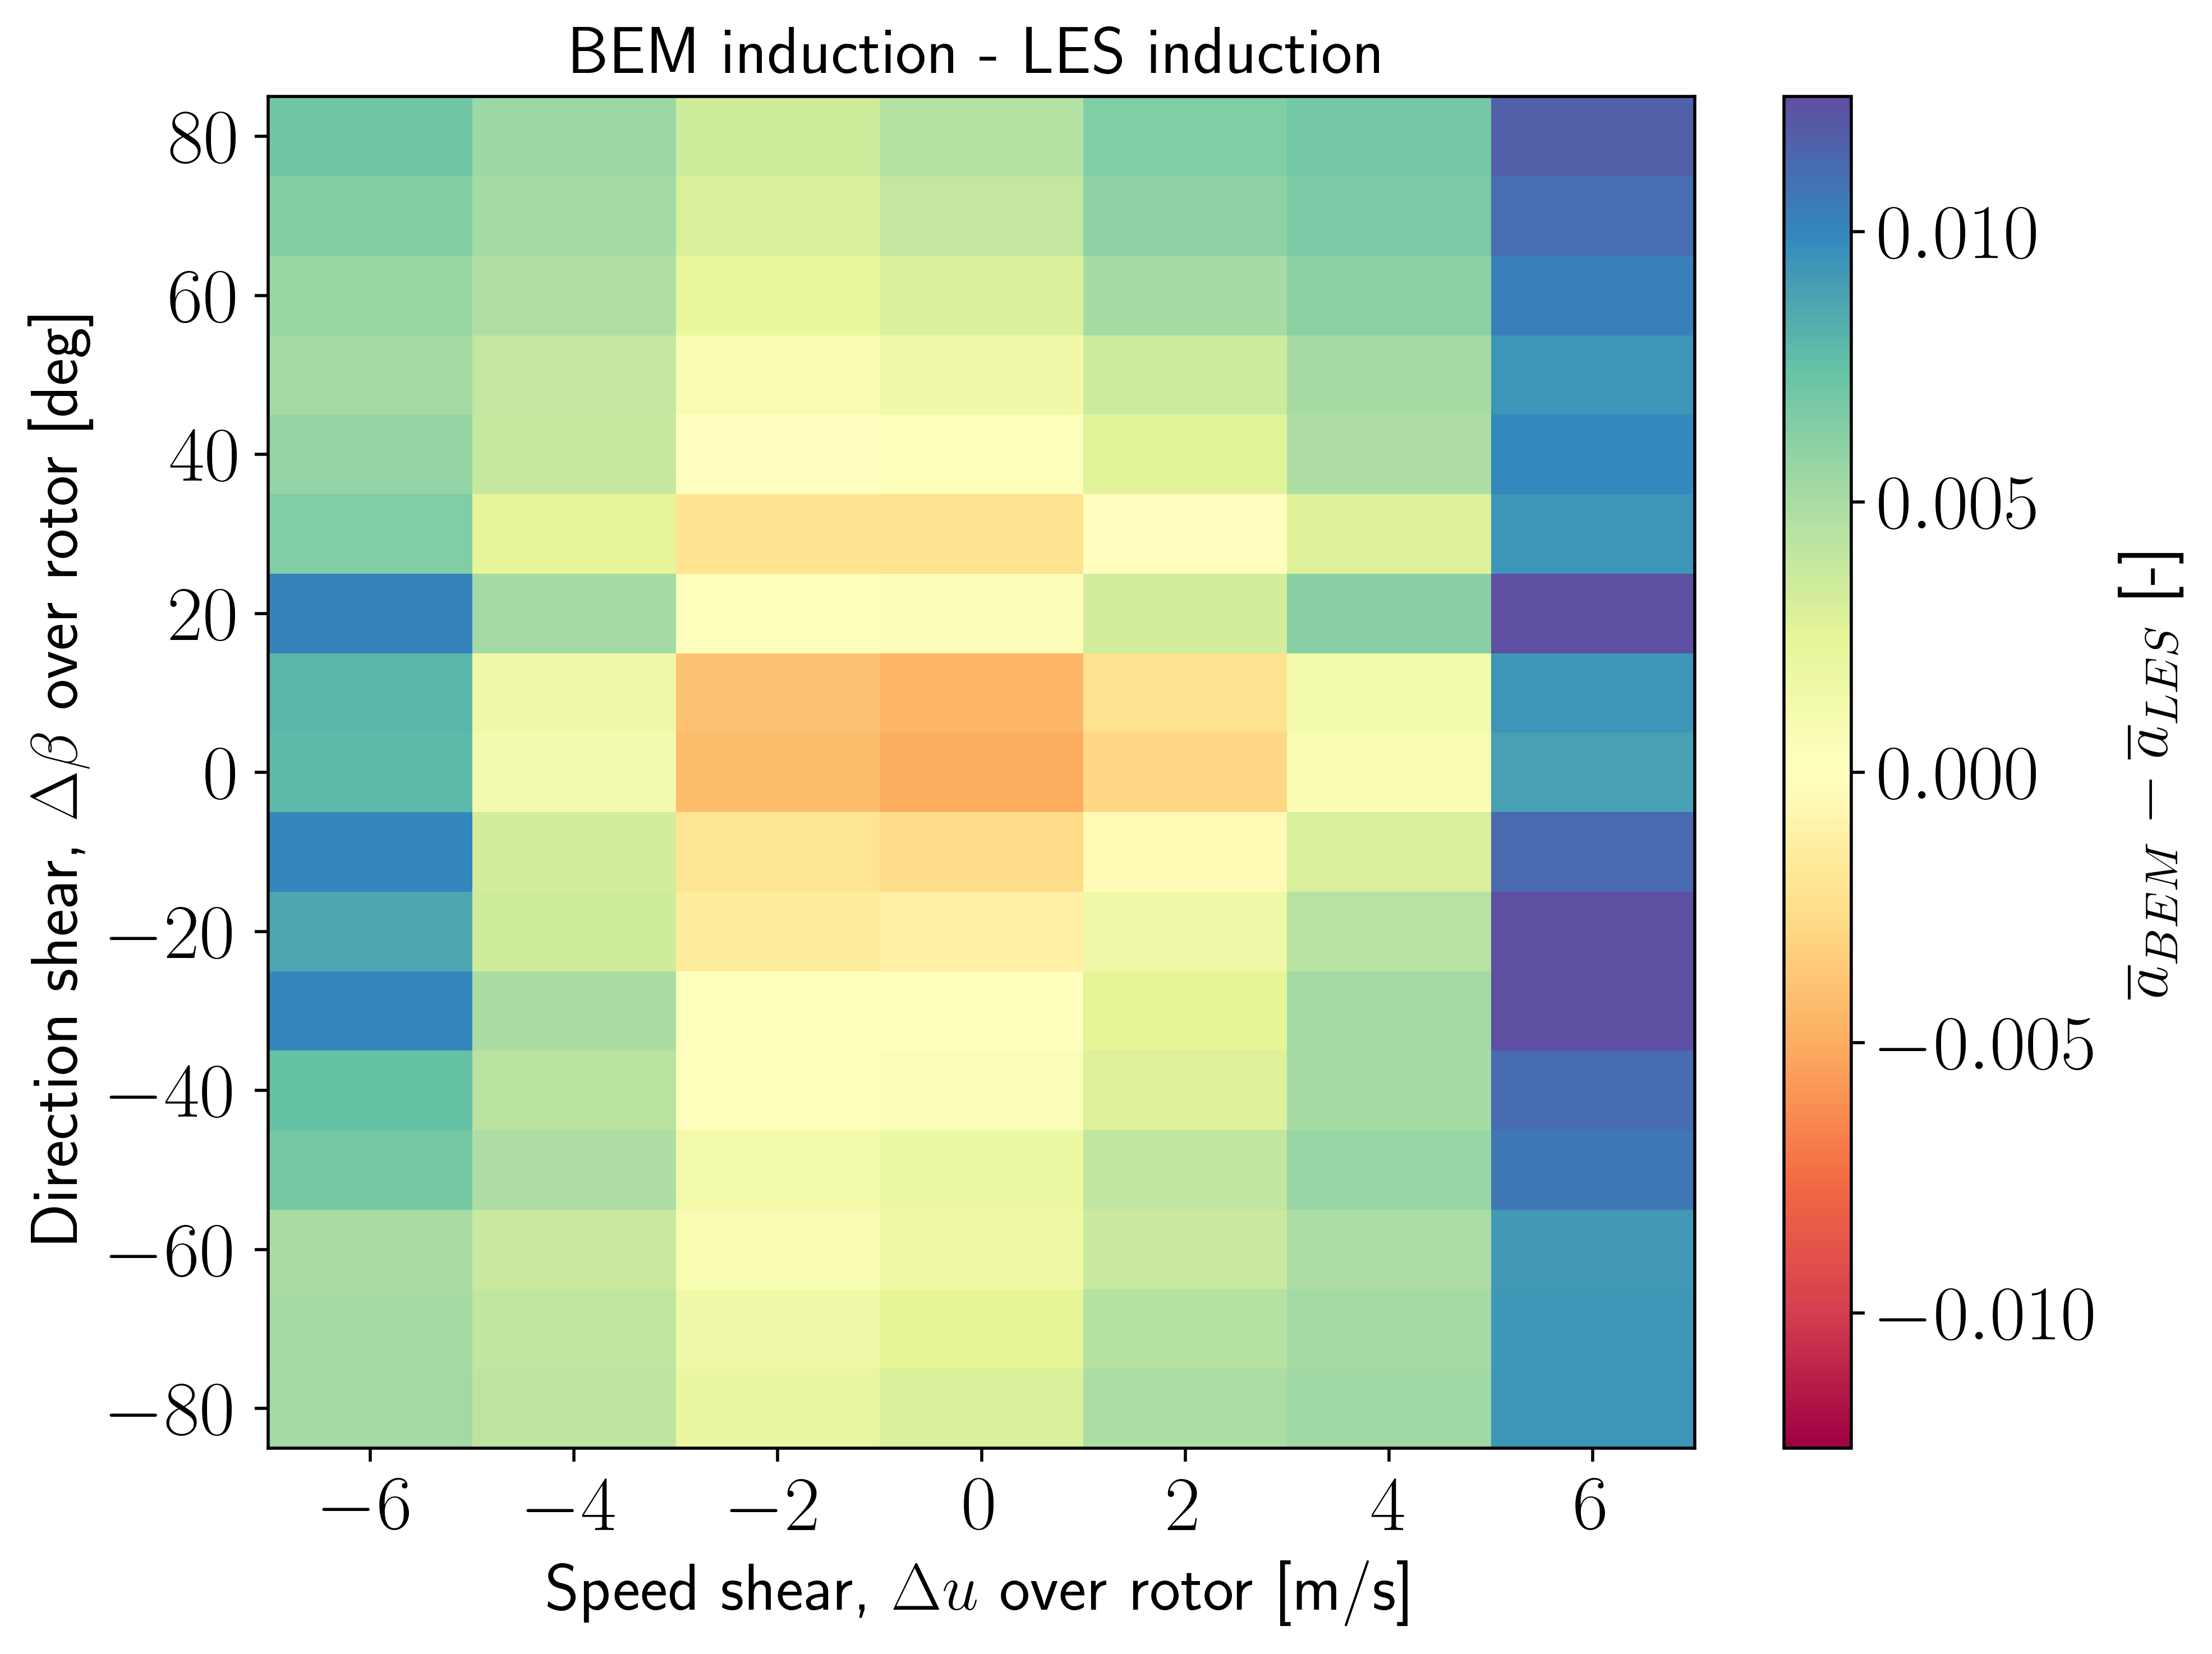

In [61]:
Z = np.zeros((len(veer),len(shear)))

for count in range(len(coords)):

    Z[coords[count][1],coords[count][0]] = (mit_ind[count] - wrf_ind[count])

plt.figure(figsize=(8, 6))
contour = plt.pcolormesh(shear, veer[::-1], Z, cmap='Spectral', vmin=-0.0125, vmax=0.0125)  # or use plt.contour
cbar = plt.colorbar(contour)
cbar.set_label(r'$\overline{a}_{BEM} - \overline{a}_{LES}$ [-]', fontsize=17)

plt.xticks(shear)  # every second x tick
plt.yticks(veer[::-1][::2])  # every second y tick

# Labels and formatting
plt.xlabel('Speed shear, $\Delta u$ over rotor [m/s]', fontsize=17)
plt.ylabel('Direction shear, $\Delta \\beta$ over rotor [deg]', fontsize=17)
plt.title('BEM induction - LES induction', fontsize=17)
plt.tight_layout()
plt.show()

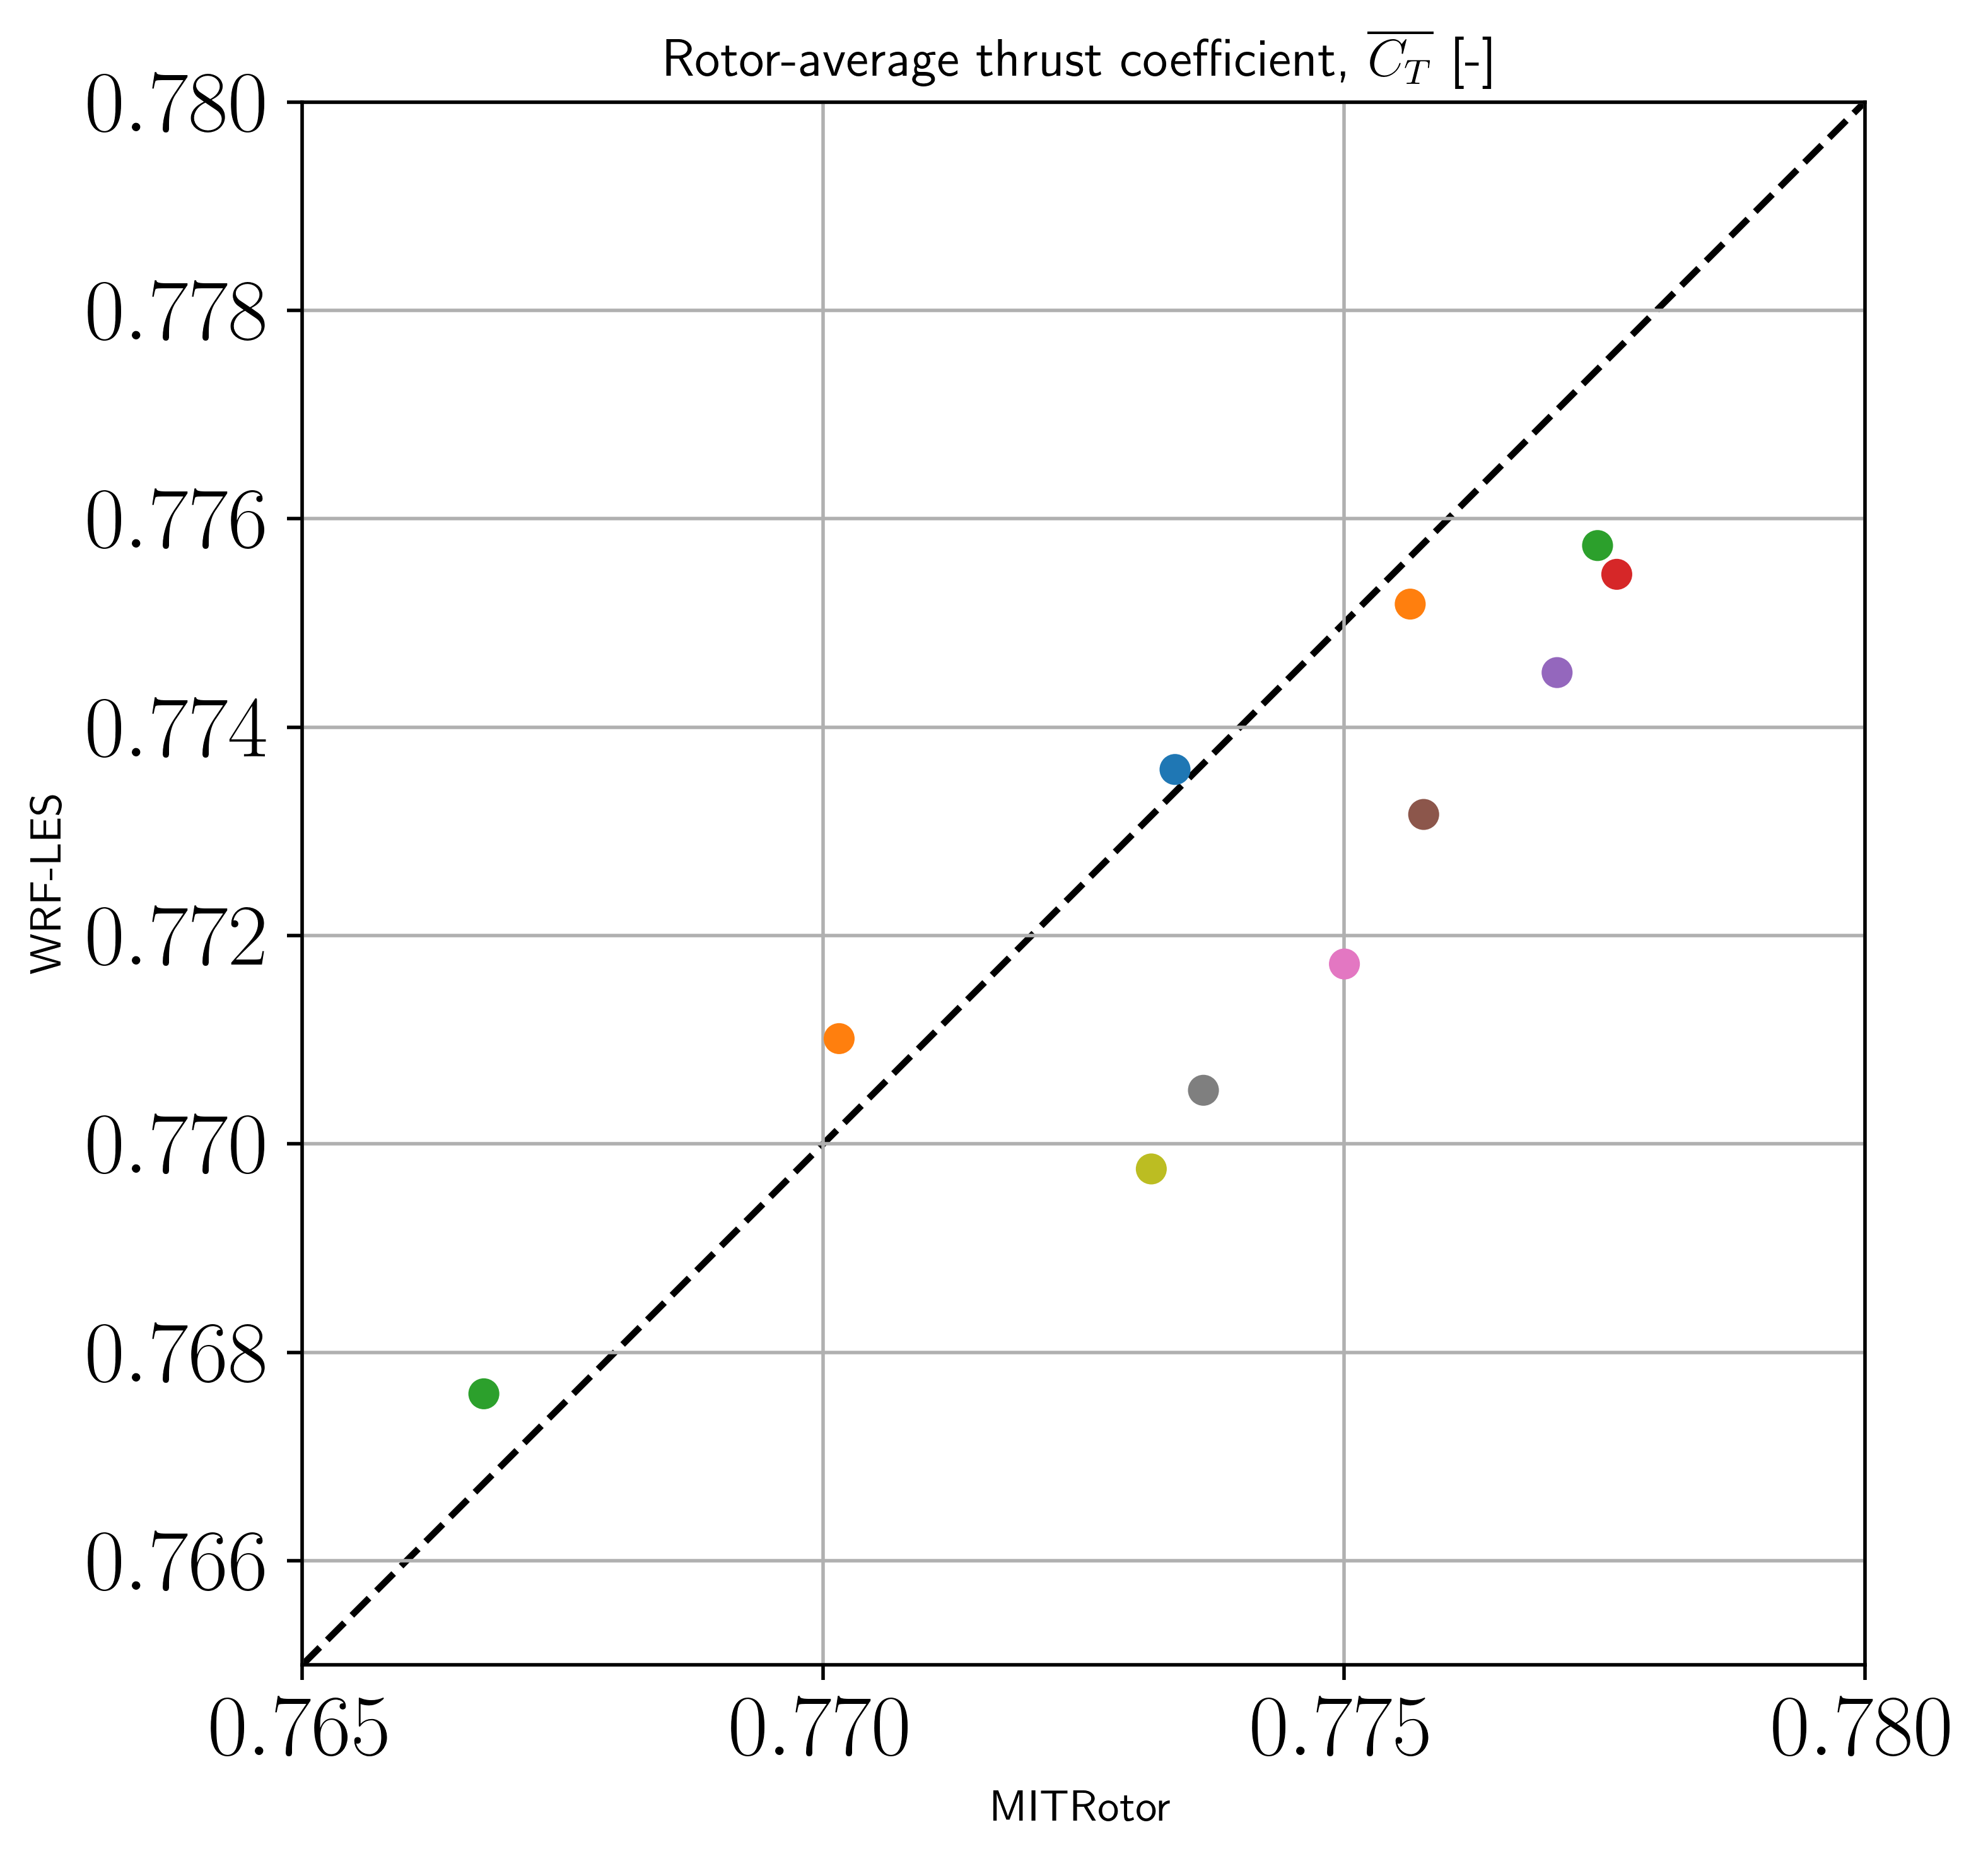

In [71]:
# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_cot)):
    ax.scatter(mit_cot[i], wrf_cot_ss[i], s=50, edgecolor='none', color=full_colors[i], zorder = i+2)

ax.plot([0,3],[0,3],color='k',linestyle='--',zorder=1)

ax.set_xlim([0.765,0.78])
ax.set_ylim([0.765,0.78])
ax.set_aspect('equal')

plt.title(r"Rotor-average thrust coefficient, $\overline{C_T}$ [-]")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
plt.tight_layout()
plt.show()

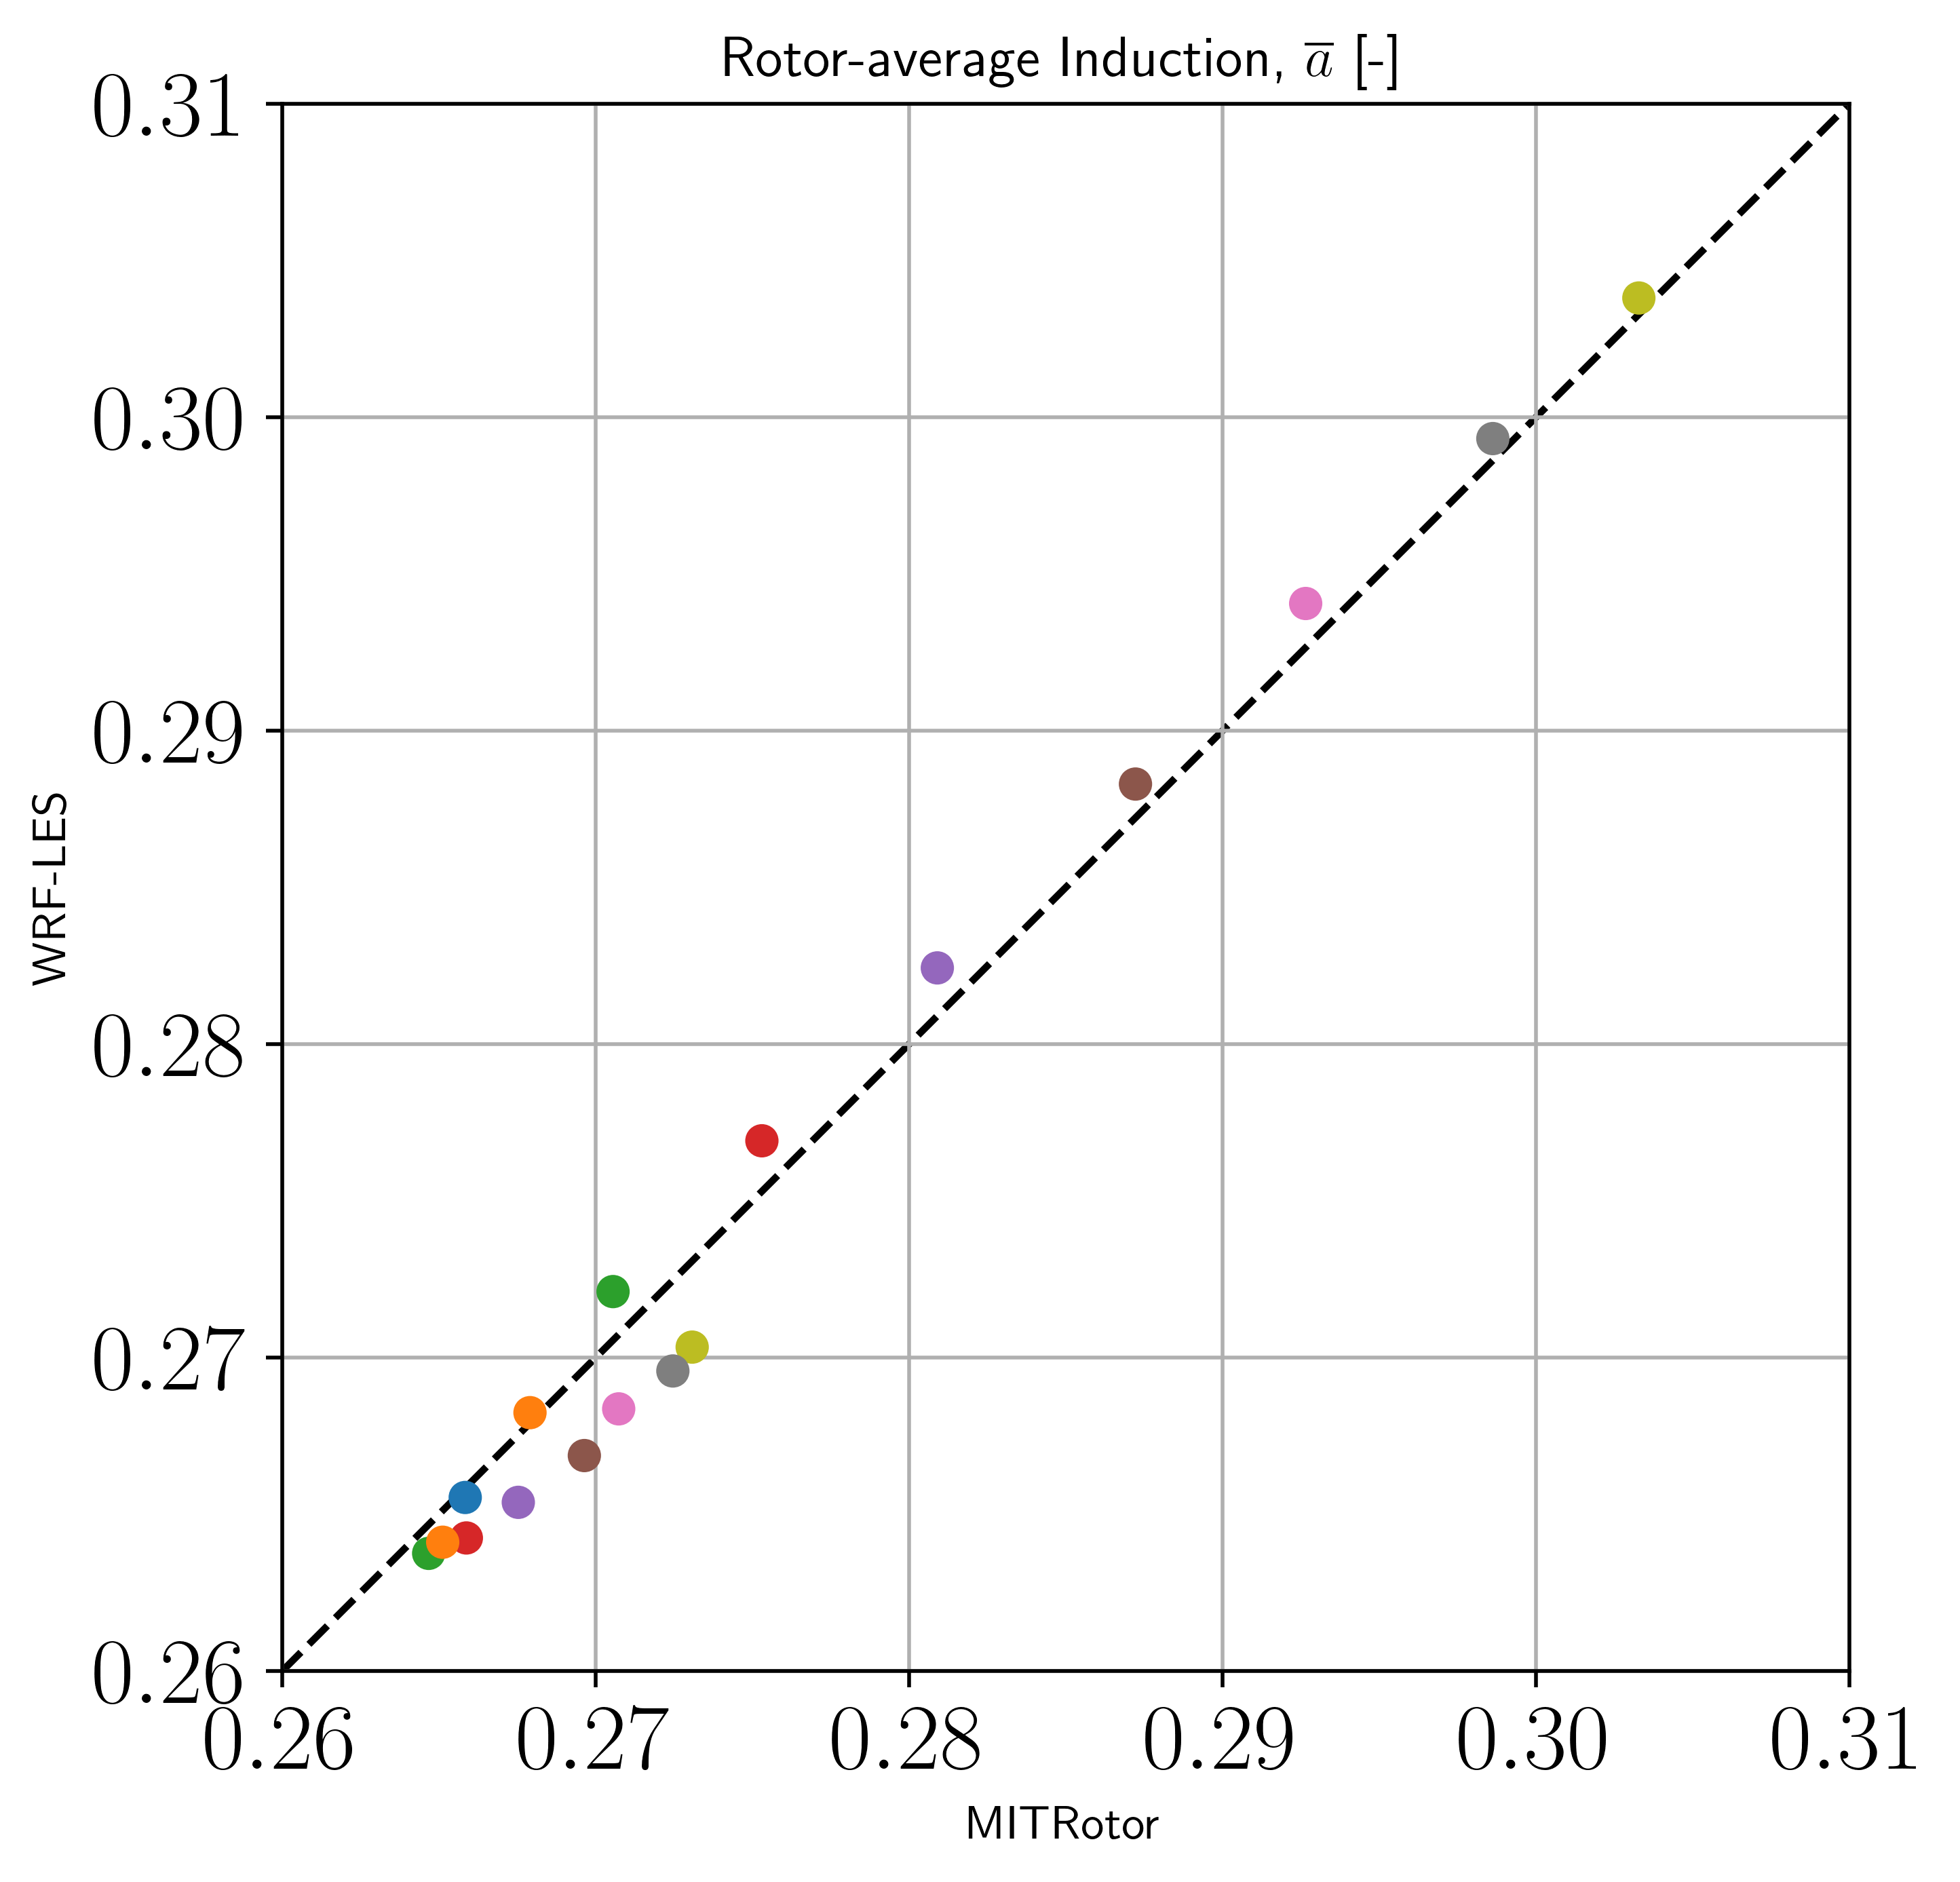

In [72]:
# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_ind)):
    ax.scatter(mit_ind[i], wrf_ind_ss[i], s=50, edgecolor='none', color=full_colors[i], zorder=i+2)

ax.plot([0,1],[0,1],color='k',linestyle='--',zorder=1)

ax.set_xlim([0.26,0.31])
ax.set_ylim([0.26,0.31])
ax.set_aspect('equal')

plt.title(r"Rotor-average Induction, $\overline{a}$ [-]")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
# plt.tight_layout()
plt.show()

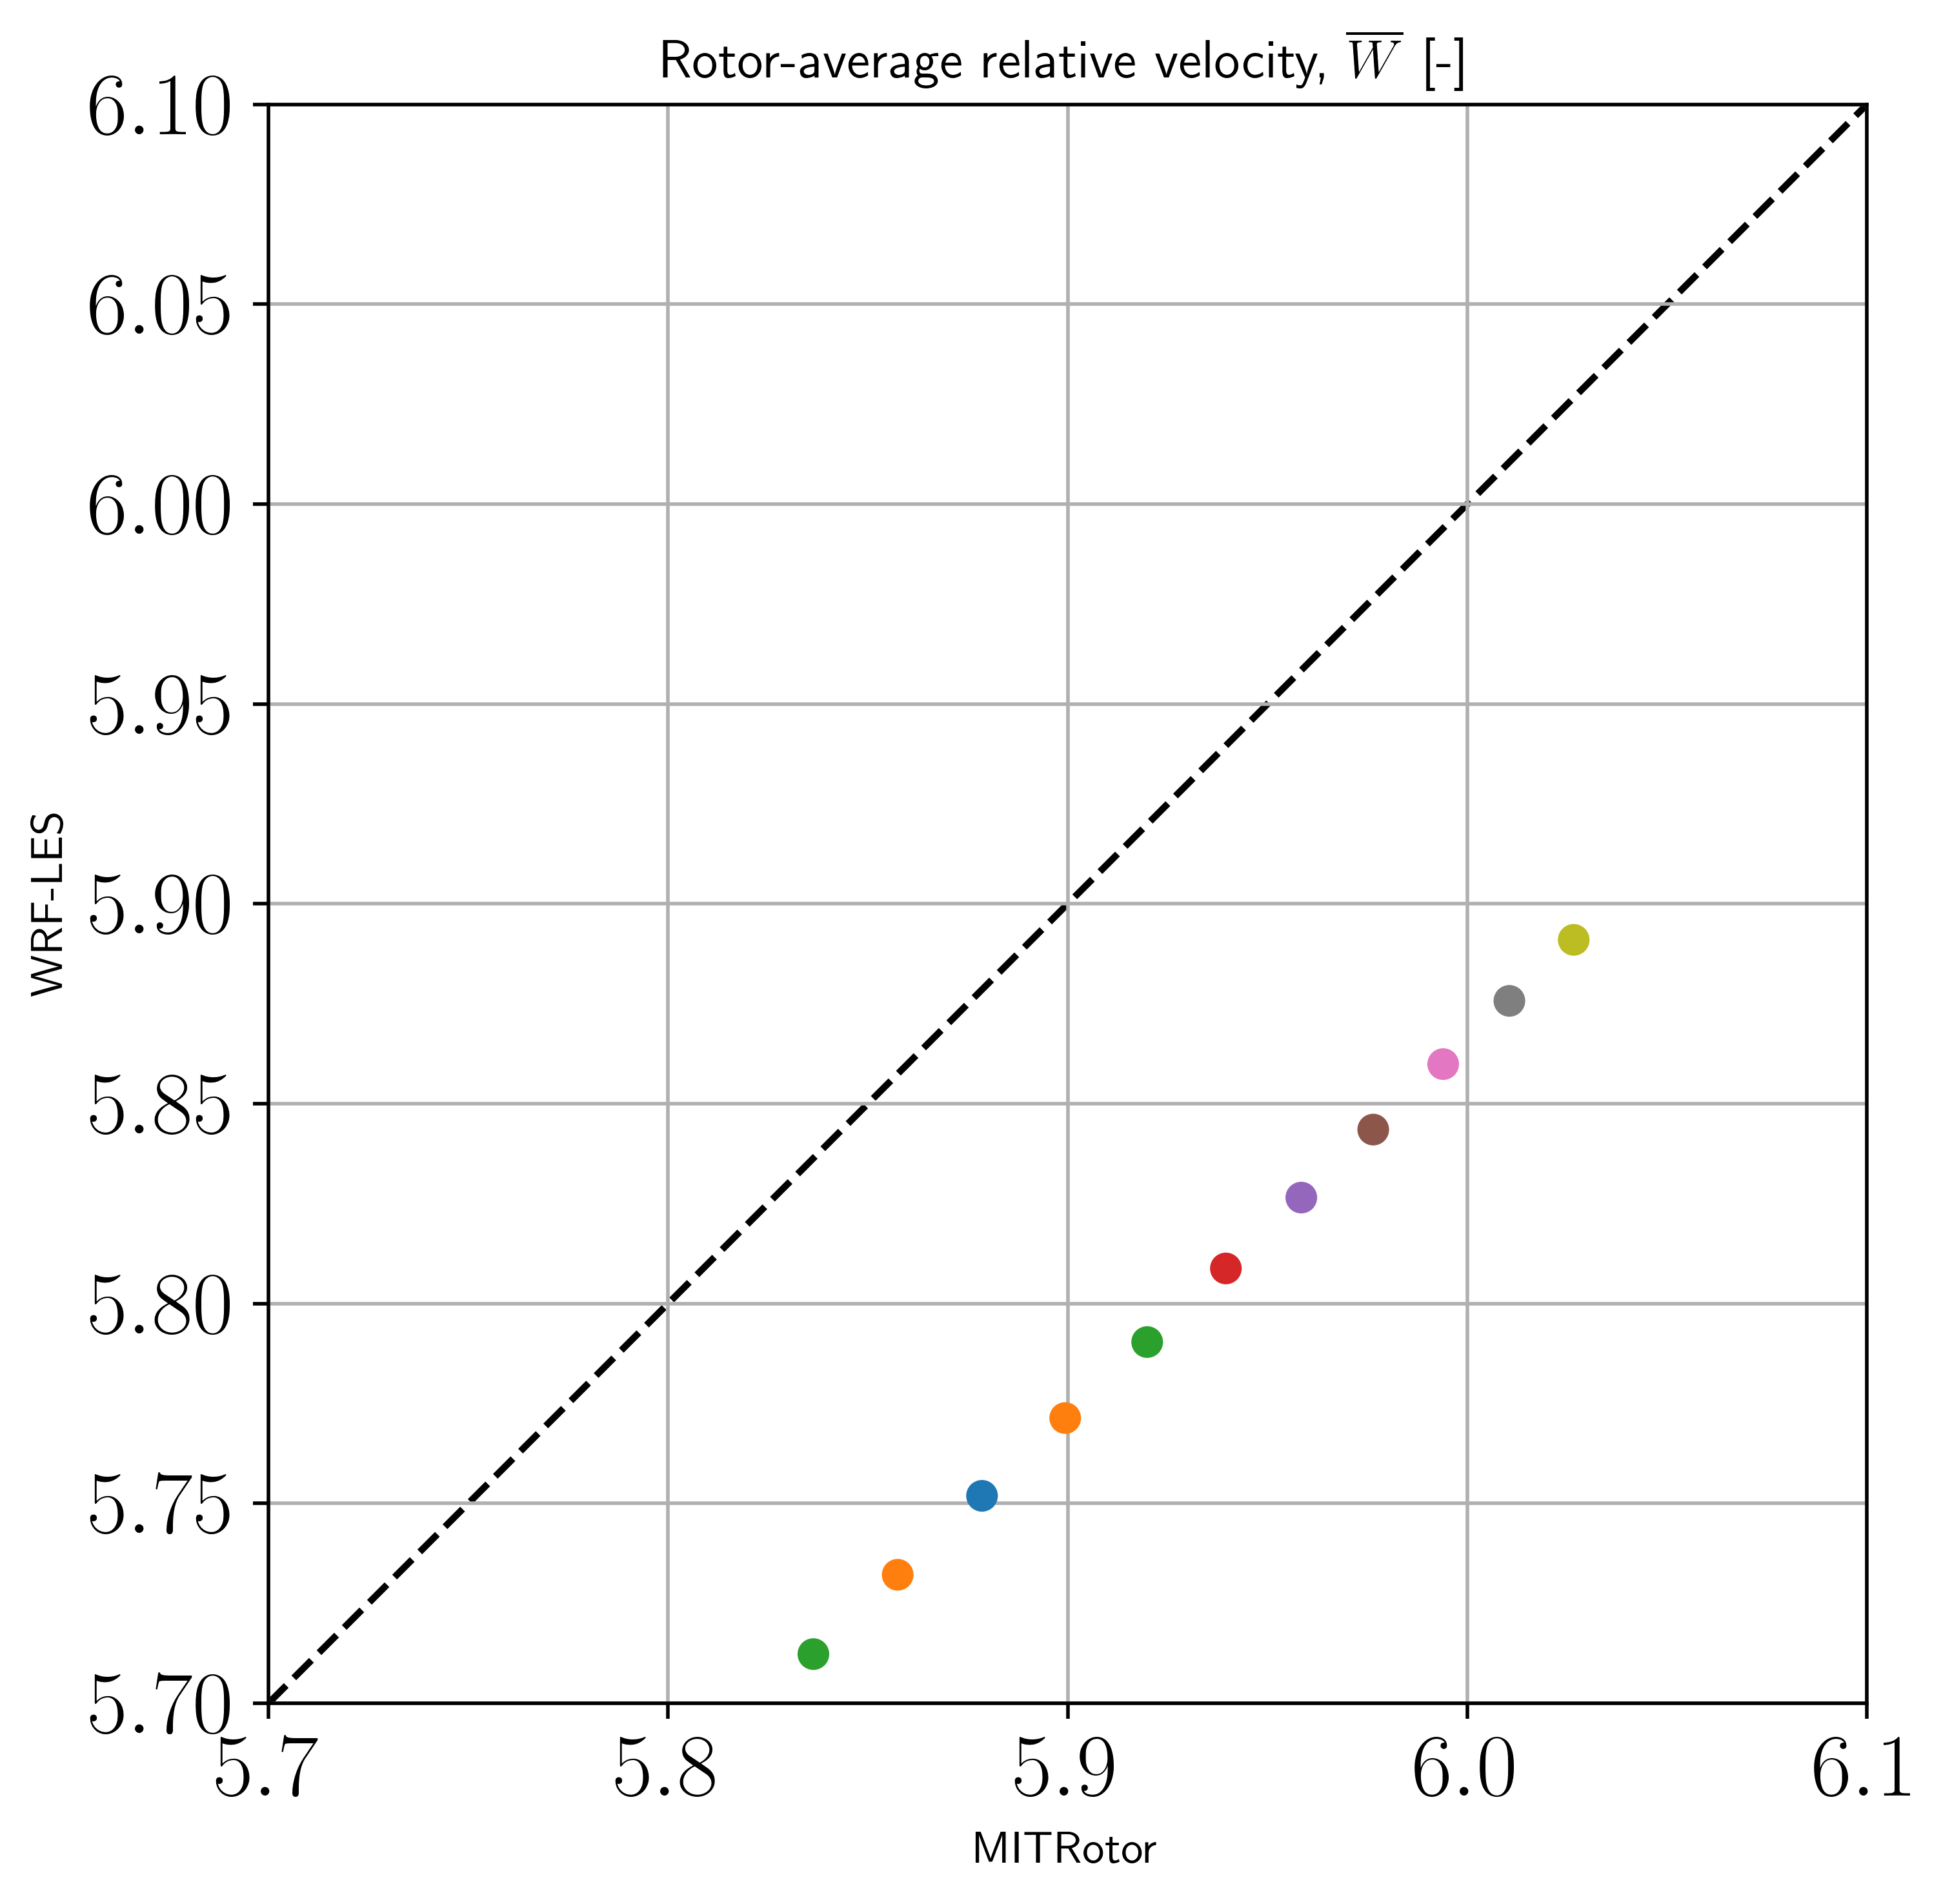

In [74]:
# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_w)):
    ax.scatter(mit_w[i], wrf_rel_ss[i], s=50, edgecolor='none', color=full_colors[i],zorder=i+2)
ax.plot([0,10],[0,10],color='k',linestyle='--',zorder=1)

ax.set_xlim([5.7,6.1])
ax.set_ylim([5.7,6.1])
ax.set_aspect('equal')

plt.title(r"Rotor-average relative velocity, $\overline{W}$ [-]")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
plt.tight_layout()
plt.show()

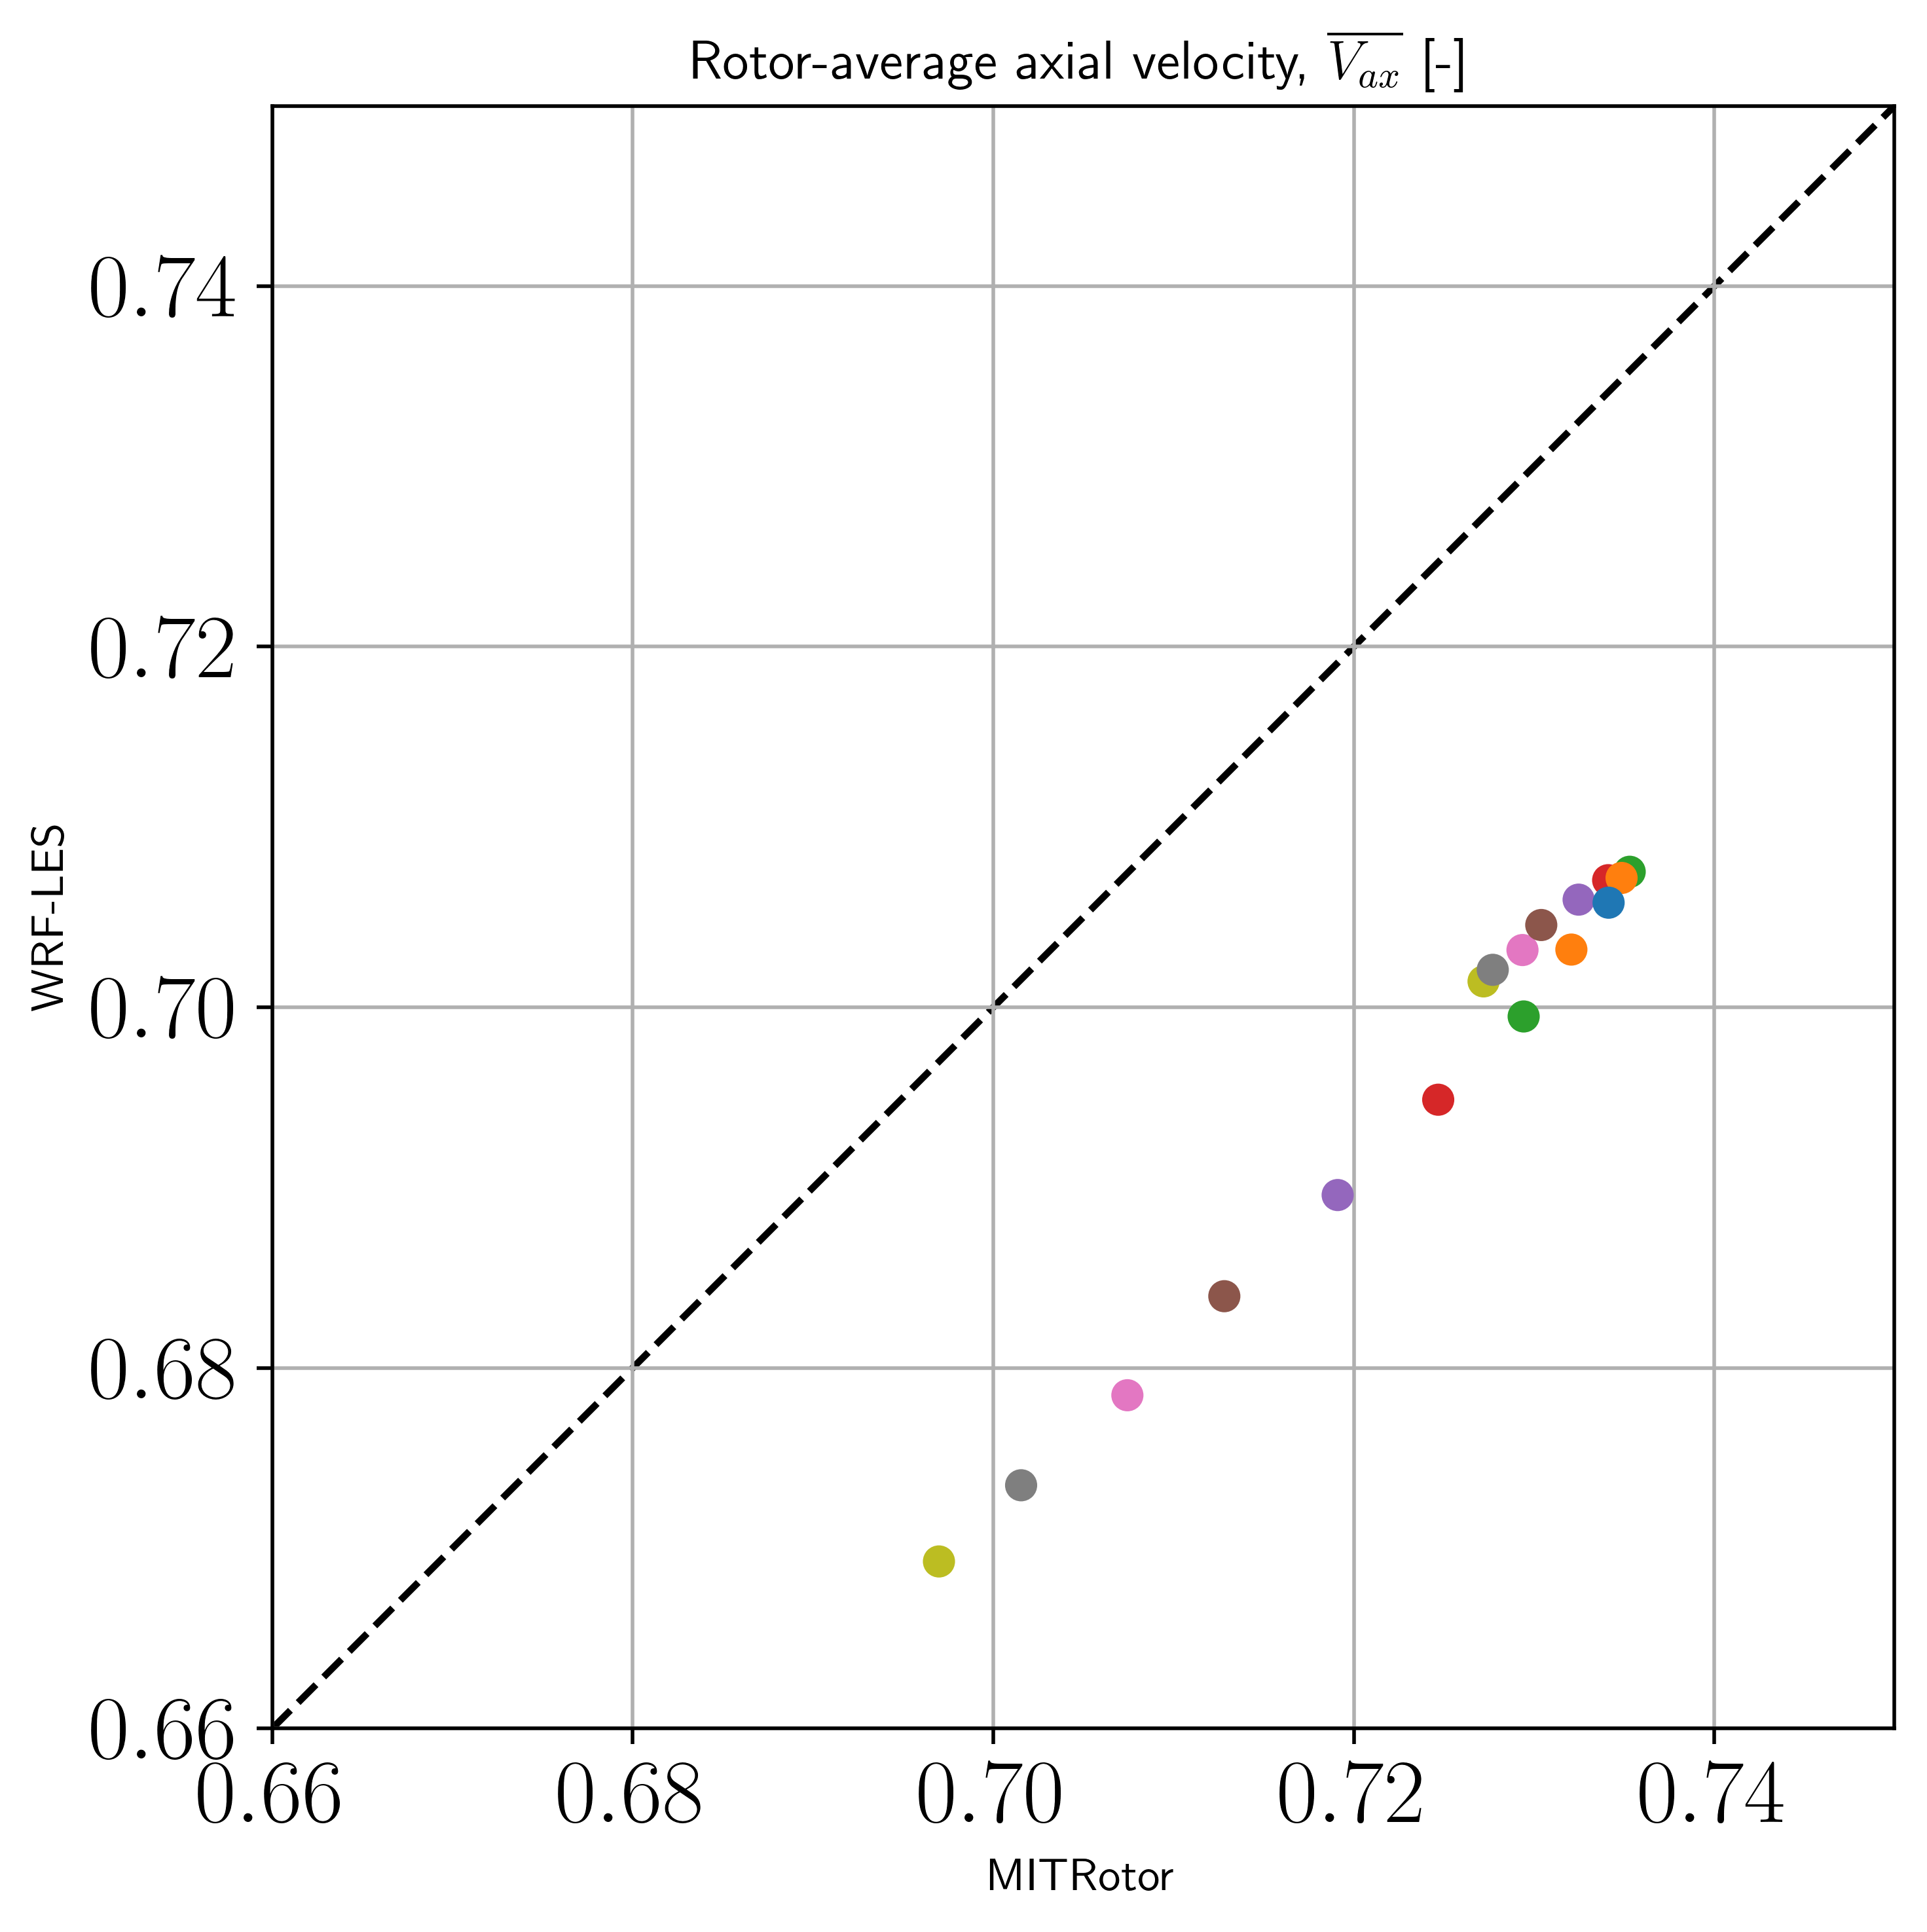

In [75]:
# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_vax)):
    ax.scatter(mit_vax[i], wrf_vax_ss[i], s=50, edgecolor='none', color=full_colors[i], zorder=i+2)
ax.plot([0,10],[0,10],color='k',linestyle='--',zorder=1)

ax.set_xlim([0.66,0.75])
ax.set_ylim([0.66,0.75])
ax.set_aspect('equal')

plt.title(r"Rotor-average axial velocity, $\overline{V_{ax}}$ [-]")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
plt.tight_layout()
plt.show()

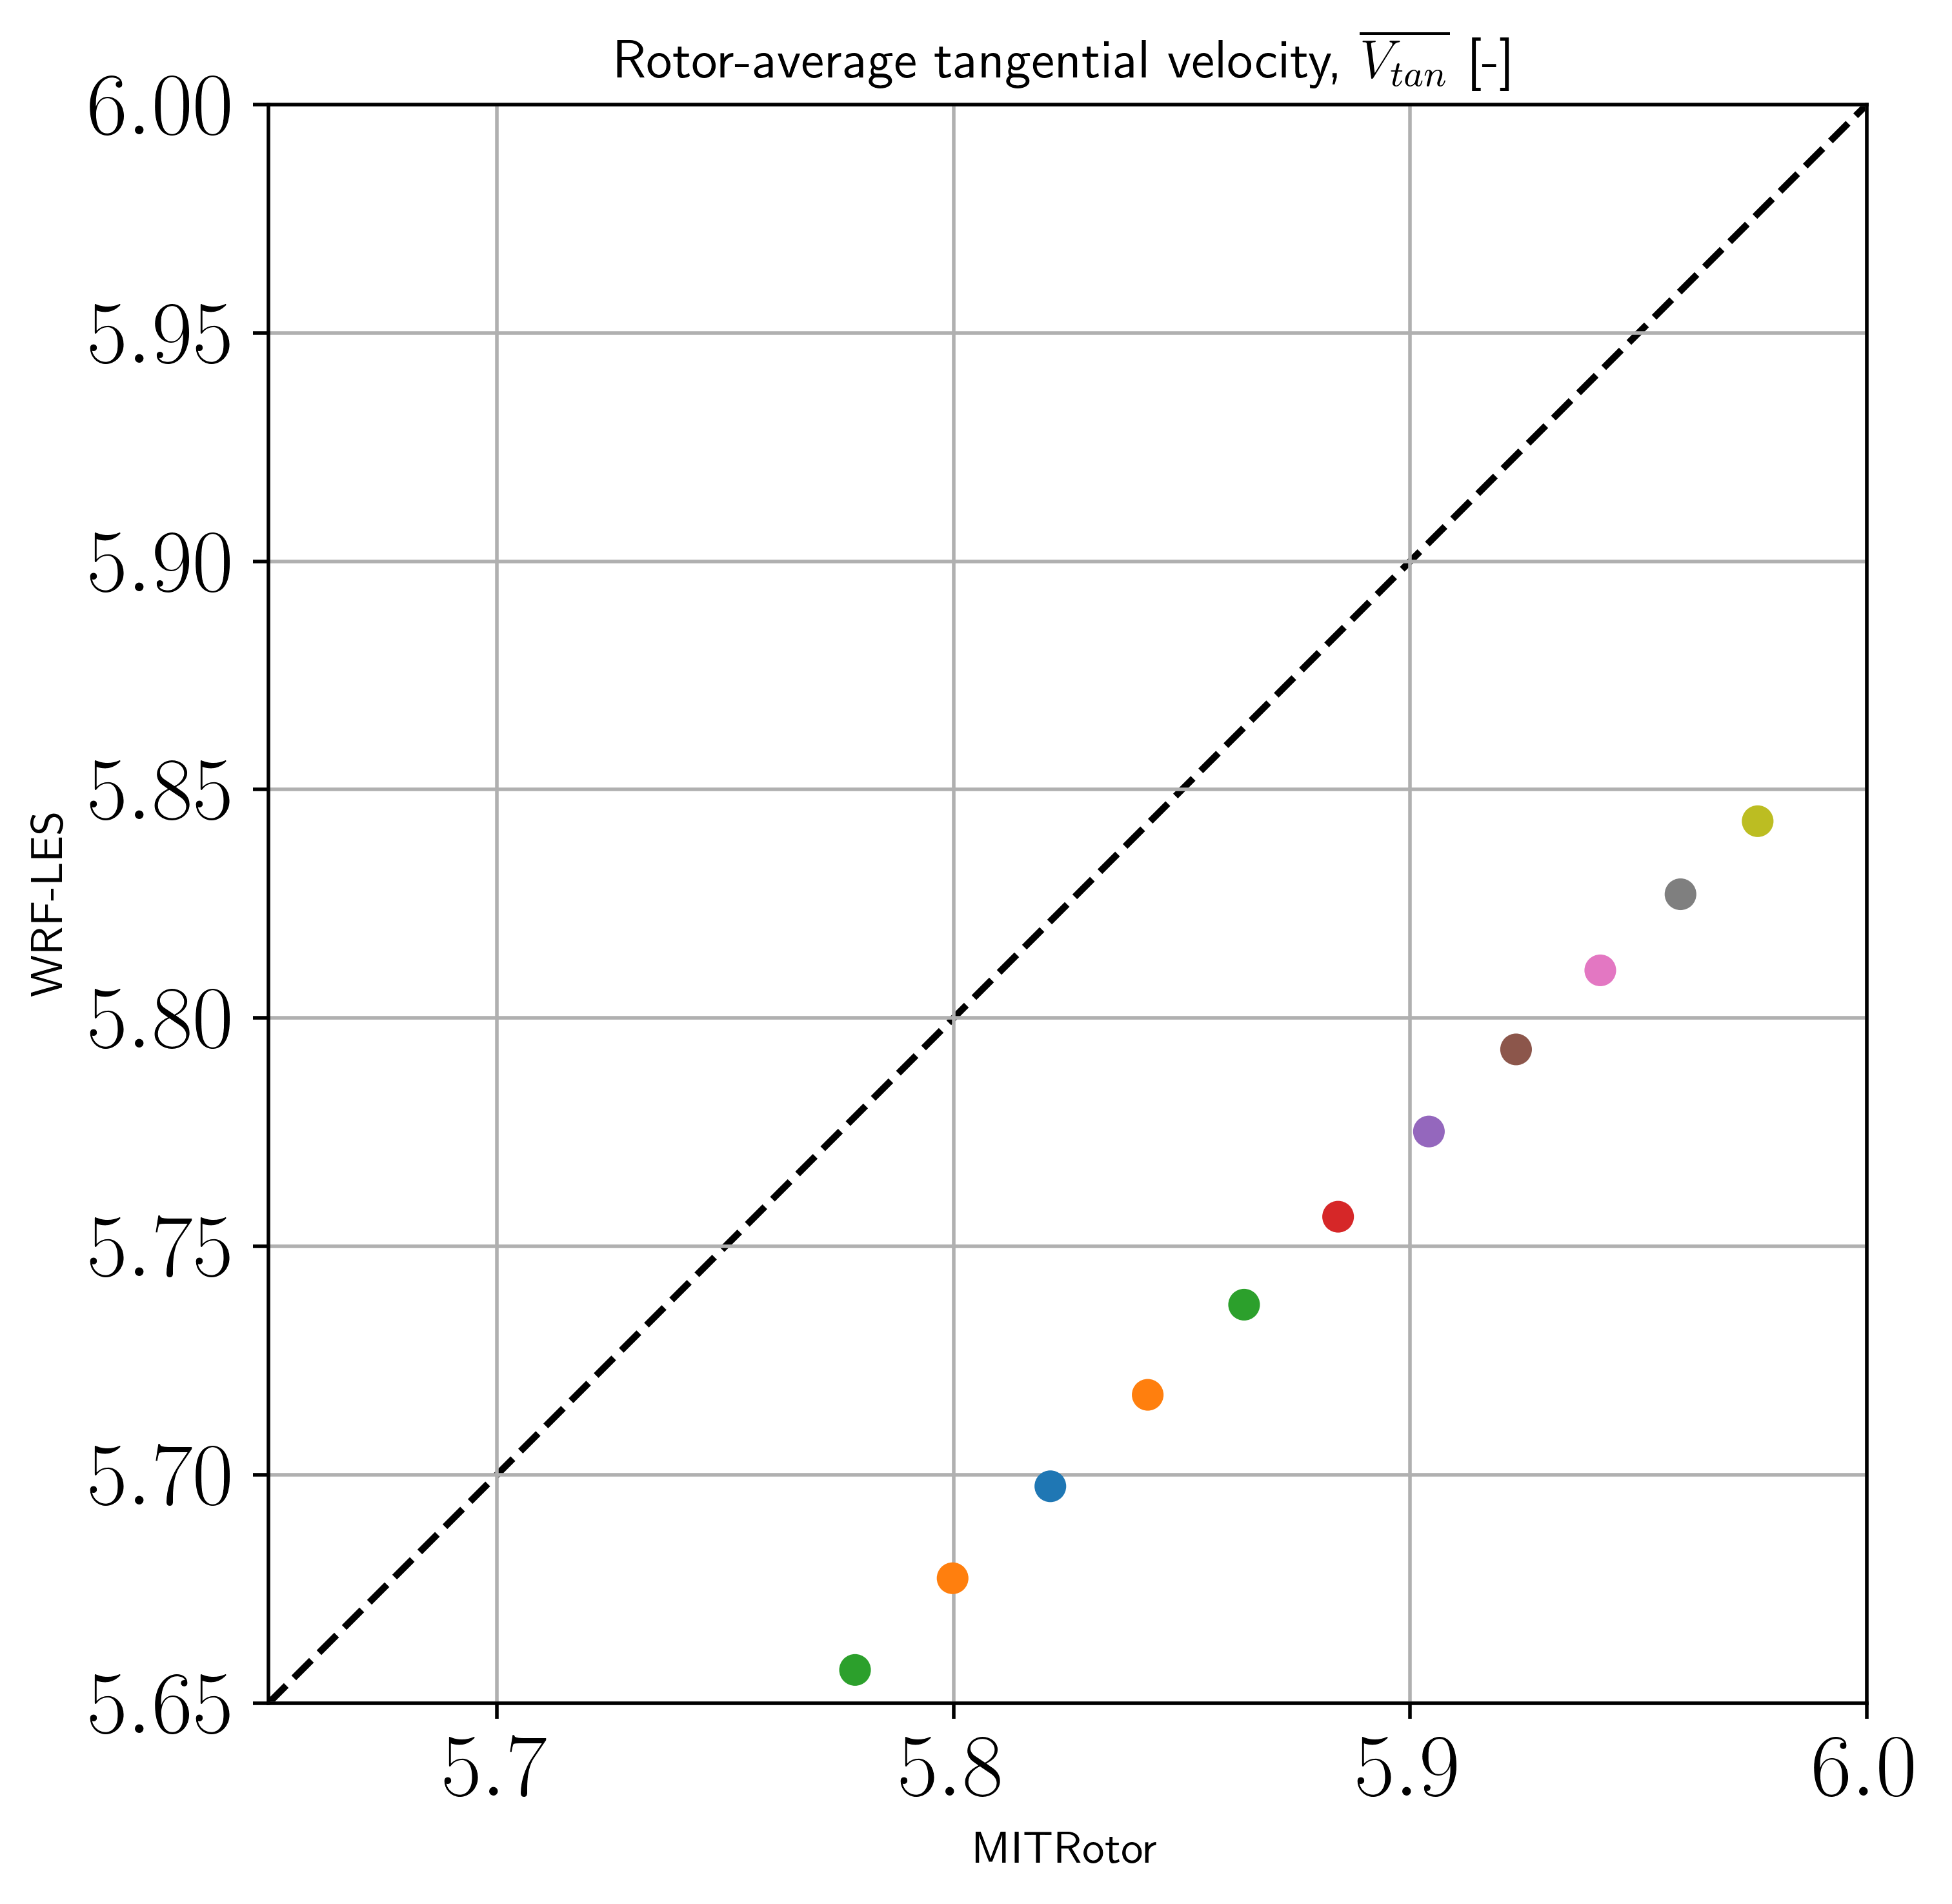

In [76]:
# Create plot
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(len(mit_vtn)):
    ax.scatter(mit_vtn[i], wrf_vtn_ss[i], s=50, edgecolor='none', color=full_colors[i],zorder=i+2)
ax.plot([0,10],[0,10],color='k',linestyle='--',zorder=1)

ax.set_xlim([5.65,6.0])
ax.set_ylim([5.65,6.0])
ax.set_aspect('equal')

plt.title(r"Rotor-average tangential velocity, $\overline{V_{tan}}$ [-]")
plt.xlabel("MITRotor")
plt.ylabel("WRF-LES")
plt.grid(True)
plt.tight_layout()
plt.show()